In [1]:
import importlib
importlib.reload(importlib.import_module('analysis_utils_msr'))
import warnings
import pandas as pd
import numpy as np
from analysis_utils_msr import sum_individual_mutation_scores, assess_grouped_spearman, assess_grouped_gain, assess_grouped_ndcg, assess_classification_metric, add_additive_predictions, unify_similar_columns, assess_all_models
import pandas as pd
import numpy as np
from functools import partial

# notebook display options
warnings.filterwarnings('ignore')

# Get all raw predictions
dataset = 'mega_splits-test'
base_path = f'~/software/esm-msr/analysis_notebooks/predictions/{dataset}'
msr_base_1 = f'{base_path}/msr_dual_ensemble_small_large_megascale_remove_spurs/1/epoch=02-val_rho_combined_avg=0.819.ckpt'
msr_base_2 = f'{base_path}/msr_dual_ensemble_small_large_megascale_remove_spurs/2/epoch=04-val_rho_combined_avg=0.823.ckpt'
msr_base_3 = f'{base_path}/msr_dual_ensemble_small_large_megascale_remove_spurs/3/epoch=03-val_rho_combined_avg=0.819.ckpt'

full_alpha = '16.0'
med_alpha = '8.0'
low_alpha = '4.0'

# ================= THERMOMPNN =================

# 1. Load Single Model Predictions (for single mutants)
df_tm_1_single = pd.read_csv(f'{base_path}/thermompnnd/single_mega_splits_remove_spurs_correct_bb_1_epoch=96_val_ddG_spearman=0.79.ckpt_singles.csv', index_col=0)
df_tm_2_single = pd.read_csv(f'{base_path}/thermompnnd/single_mega_splits_remove_spurs_correct_bb_2_epoch=99_val_ddG_spearman=0.79.ckpt_singles.csv', index_col=0)
df_tm_3_single = pd.read_csv(f'{base_path}/thermompnnd/single_mega_splits_remove_spurs_correct_bb_3_epoch=95_val_ddG_spearman=0.79.ckpt_singles.csv', index_col=0)

# 2. Load Epistatic Model Predictions (for multimutants)
df_tm_1_epistatic = pd.read_csv(f'{base_path}/thermompnnd/epistatic_mega_splits_remove_spurs_correct_bb_1_epoch=62_val_ddG_spearman=0.77.ckpt.csv', index_col=0)
df_tm_2_epistatic = pd.read_csv(f'{base_path}/thermompnnd/epistatic_mega_splits_remove_spurs_correct_bb_2_epoch=31_val_ddG_spearman=0.78.ckpt.csv', index_col=0)
df_tm_3_epistatic = pd.read_csv(f'{base_path}/thermompnnd/epistatic_mega_splits_remove_spurs_correct_bb_3_epoch=42_val_ddG_spearman=0.77.ckpt.csv', index_col=0)

# 3. Load Additive Model Predictions (for multimutant baseline)
df_tm_1_additive = pd.read_csv(f'{base_path}/thermompnnd/additive_single_mega_splits_remove_spurs_correct_bb_1_epoch=96_val_ddG_spearman=0.79.ckpt.csv', index_col=0).dropna(subset='ddG_pred_additive')
df_tm_2_additive = pd.read_csv(f'{base_path}/thermompnnd/additive_single_mega_splits_remove_spurs_correct_bb_2_epoch=99_val_ddG_spearman=0.79.ckpt.csv', index_col=0).dropna(subset='ddG_pred_additive')
df_tm_3_additive = pd.read_csv(f'{base_path}/thermompnnd/additive_single_mega_splits_remove_spurs_correct_bb_3_epoch=95_val_ddG_spearman=0.79.ckpt.csv', index_col=0).dropna(subset='ddG_pred_additive')

# --- Construct ThermoMPNN column (Singles + Additive Multimutants) ---
df_tm_1_add_col = pd.concat([df_tm_1_single['ddG_pred'], df_tm_1_additive['ddG_pred_additive']]).to_frame('ThermoMPNN_1')
df_tm_2_add_col = pd.concat([df_tm_2_single['ddG_pred'], df_tm_2_additive['ddG_pred_additive']]).to_frame('ThermoMPNN_2')
df_tm_3_add_col = pd.concat([df_tm_3_single['ddG_pred'], df_tm_3_additive['ddG_pred_additive']]).to_frame('ThermoMPNN_3')

# --- Construct ThermoMPNN(-D) column (Epistatic Multimutants filled with Singles) ---
# FLAW: We must strictly filter the single model to only include non-colon indices 
# to prevent "additive" leaking into the "epistatic" column per prompt instructions.
df_tm_1_epi_col = df_tm_1_epistatic['ddG_pred'].rename('ThermoMPNN(-D)_1')
df_tm_1_epi_col = df_tm_1_epi_col.combine_first(df_tm_1_single.loc[~df_tm_1_single.index.str.contains(':'), 'ddG_pred'].rename('ThermoMPNN(-D)_1'))

df_tm_2_epi_col = df_tm_2_epistatic['ddG_pred'].rename('ThermoMPNN(-D)_2')
df_tm_2_epi_col = df_tm_2_epi_col.combine_first(df_tm_2_single.loc[~df_tm_2_single.index.str.contains(':'), 'ddG_pred'].rename('ThermoMPNN(-D)_2'))

df_tm_3_epi_col = df_tm_3_epistatic['ddG_pred'].rename('ThermoMPNN(-D)_3')
df_tm_3_epi_col = df_tm_3_epi_col.combine_first(df_tm_3_single.loc[~df_tm_3_single.index.str.contains(':'), 'ddG_pred'].rename('ThermoMPNN(-D)_3'))

# Assemble Thermo Ensemble
df_thermo = df_tm_1_add_col.join([df_tm_1_epi_col, df_tm_2_add_col, df_tm_2_epi_col, df_tm_3_add_col, df_tm_3_epi_col], how='inner')
# Attach ground truth from the first replicate
df_thermo = df_thermo.join(df_tm_1_single[['code', 'mut_type', 'ddG_true']].rename(columns={'ddG_true': 'ddG_ML_thermo'}))
df_thermo['ThermoMPNN(-D)_additive_1'] = df_thermo['ThermoMPNN_1']
df_thermo['ThermoMPNN(-D)_additive_2'] = df_thermo['ThermoMPNN_2']
df_thermo['ThermoMPNN(-D)_additive_3'] = df_thermo['ThermoMPNN_3']


# ================= SPURS =================

df_spurs = pd.read_csv(f'{base_path}/SPURS/SPURS_combined_predictions.csv', index_col=0)
df_spurs['SPURS_additive'] = df_spurs['SPURS_single_additive']
df_spurs['SPURS'] = df_spurs['SPURS_single']
df_spurs.loc[df_spurs['SPURS'].isnull(), 'SPURS'] = df_spurs.loc[df_spurs['SPURS'].isnull(), 'SPURS_multi']
df_spurs = df_spurs[['code', 'mut_type', 'SPURS', 'SPURS_additive']]

# ================= MUTATE EVERYTHING =================

df_me_1 = pd.read_csv(f'{base_path}/mutate_everything/af_double_mega_splits_remove_spurs_1_checkpoint-99.csv', index_col=0)
df_me_1['MutateEverything_1'] = df_me_1['ddG_pred']
df_me_1['ddG_ML_me'] = df_me_1['ddG_true']
df_me_2 = pd.read_csv(f'{base_path}/mutate_everything/af_double_mega_splits_remove_spurs_2_checkpoint-99.csv', index_col=0)
df_me_2['MutateEverything_2'] = df_me_2['ddG_pred']
df_me_3 = pd.read_csv(f'{base_path}/mutate_everything/af_double_mega_splits_remove_spurs_3_checkpoint-99.csv', index_col=0)
df_me_3['MutateEverything_3'] = df_me_3['ddG_pred']

df_me = df_me_1[['code', 'mut_type', 'MutateEverything_1', 'ddG_ML_me']].join(df_me_2[['MutateEverything_2']], how='inner').join(df_me_3[['MutateEverything_3']], how='inner')

assert len(df_me) == len(df_me_1)

df_me_additive_1 = pd.read_csv(f'{base_path}/mutate_everything/af_single_additive_mega_splits_remove_spurs_1_checkpoint-19.csv', index_col=0)
df_me_additive_1 = add_additive_predictions(df_me_additive_1, df_me)
df_me_additive_1 = df_me_additive_1[['code', 'mut_type', 'ddG_pred_additive']].rename(columns={'ddG_pred_additive': 'MutateEverything_additive_1'})

df_me_additive_2 = pd.read_csv(f'{base_path}/mutate_everything/af_single_additive_mega_splits_remove_spurs_2_checkpoint-19.csv', index_col=0)
df_me_additive_2 = add_additive_predictions(df_me_additive_2, df_me)[['code', 'mut_type', 'ddG_pred_additive']].rename(columns={'ddG_pred_additive': 'MutateEverything_additive_2'})

df_me_additive_3 = pd.read_csv(f'{base_path}/mutate_everything/af_single_additive_mega_splits_remove_spurs_3_checkpoint-19.csv', index_col=0)
df_me_additive_3 = add_additive_predictions(df_me_additive_3, df_me)[['code', 'mut_type', 'ddG_pred_additive']].rename(columns={'ddG_pred_additive': 'MutateEverything_additive_3'})

df_me_additive = df_me_additive_1[['MutateEverything_additive_1']].join(df_me_additive_2[['MutateEverything_additive_2']], how='inner').join(df_me_additive_3[['MutateEverything_additive_3']], how='inner')
assert len(df_me_additive) == len(df_me)
df_me = df_me.join(df_me_additive)
df_me['uid'] = df_me['code'] + '_' + df_me['mut_type']
df_me = df_me.set_index('uid')

# ================= ZERO SHOT & BASELINES =================

df_zero_sm = pd.read_csv(f'{base_path}/esm3_forge/zero_shot/esm3-small-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-small', 'pred_additive': 'ESM3-small_additive'})
df_zero_sm = df_zero_sm.reset_index(drop=True)
df_zero_sm['uid'] = df_zero_sm['code'] + '_' + df_zero_sm['mut_type']
df_zero_sm = df_zero_sm.set_index('uid')
df_zero_med = pd.read_csv(f'{base_path}/esm3_forge/zero_shot/esm3-medium-2024-08/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-medium', 'pred_additive': 'ESM3-medium_additive'})
df_zero_med = df_zero_med.reset_index(drop=True)
df_zero_med['uid'] = df_zero_med['code'] + '_' + df_zero_med['mut_type']
df_zero_med = df_zero_med.set_index('uid')
df_zero_lg = pd.read_csv(f'{base_path}/esm3_forge/zero_shot/esm3-large-2024-03/predictions_unmasked.csv', index_col=0).rename(columns={'esm3_score': 'ESM3-large', 'pred_additive': 'ESM3-large_additive'})
df_zero_lg = df_zero_lg.reset_index(drop=True)
df_zero_lg['uid'] = df_zero_lg['code'] + '_' + df_zero_lg['mut_type']
df_zero_lg = df_zero_lg.set_index('uid')

df_mpnn = pd.read_csv(f'{base_path}/proteinmpnn/proteinmpnn_020_unmasked.csv', index_col=0).reset_index(drop=True).rename(columns={'mpnn_score': 'ProteinMPNN', 'mpnn_score_additive': 'ProteinMPNN_additive', 'uid.1': 'uid'}).set_index('uid')
#df_mpnn = pd.read_csv(f'{base_path}/proteinmpnn/proteinmpnn_020.csv', index_col=0).reset_index(drop=True).rename(columns={'mpnn_score': 'ProteinMPNN', 'mpnn_score_additive': 'ProteinMPNN_additive', 'uid.1': 'uid'}).set_index('uid')

# Rosetta Cartesian DDG
df_ros = pd.read_csv('/home/sareeves/software/esm-msr/analysis_notebooks/predictions/mega_splits-test/rosetta/cartesian_ddg.csv', index_col=0)
df_ros['code'] = df_ros.index.to_series().apply(lambda x: x.split('_')[0])
df_ros['mut_type'] = df_ros.index.to_series().apply(lambda x: '_'.join(x.split('_')[1:]))
df_ros['Rosetta Cartesian DDG_1'] = df_ros['cartesian_ddg_1'] / 2.94
df_ros['ddG_pred'] = df_ros['cartesian_ddg_1'] / 2.94
df_ros = add_additive_predictions(df_ros, df_ros)
df_ros = df_ros.rename(columns={'ddG_pred_additive': 'Rosetta Cartesian DDG_additive_1'})
df_ros['Rosetta Cartesian DDG_2'] = df_ros['cartesian_ddg_2'] / 2.94
df_ros['ddG_pred'] = df_ros['cartesian_ddg_2'] / 2.94
df_ros = add_additive_predictions(df_ros, df_ros)
df_ros = df_ros.rename(columns={'ddG_pred_additive': 'Rosetta Cartesian DDG_additive_2'})
df_ros['Rosetta Cartesian DDG_3'] = df_ros['cartesian_ddg_3'] / 2.94
df_ros['ddG_pred'] = df_ros['cartesian_ddg_3'] / 2.94
df_ros = add_additive_predictions(df_ros, df_ros)
df_ros = df_ros.rename(columns={'ddG_pred_additive': 'Rosetta Cartesian DDG_additive_3'})

df_ros.index.name = 'uid'
df_ros = df_ros.reset_index()
df_ros['code'] = df_ros['uid'].apply(lambda x: x.split('_')[0])
df_ros['mut_type'] = df_ros['uid'].apply(lambda x: x.split('_')[-1])
df_ros = df_ros.set_index('uid')
df_ros = df_ros.fillna(0)

df_mpnn = pd.read_csv(f'{base_path}/proteinmpnn/proteinmpnn_020_unmasked.csv', index_col=0).reset_index(drop=True).rename(columns={'mpnn_score': 'ProteinMPNN', 'mpnn_score_additive': 'ProteinMPNN_additive', 'uid.1': 'uid'}).set_index('uid')

# ================= ESM-MSR =================

truth = 'ddG_ML'

df_esm_1 = pd.read_csv(f'{msr_base_1}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_1.loc[~df_esm_1['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_1.loc[~df_esm_1['mut_type'].str.contains(':'), 'combined_pred']
df_esm_1['ESM-MSR_1'] = df_esm_1['combined_pred']
df_esm_1['ESM-MSR_additive_1'] = df_esm_1['combined_pred_additive']
df_esm_1['ddG_ML_esm'] = df_esm_1[truth]

df_esm_2 = pd.read_csv(f'{msr_base_2}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_2.loc[~df_esm_2['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_2.loc[~df_esm_2['mut_type'].str.contains(':'), 'combined_pred']
df_esm_2['ESM-MSR_2'] = df_esm_2['combined_pred']
df_esm_2['ESM-MSR_additive_2'] = df_esm_2['combined_pred_additive']

df_esm_3 = pd.read_csv(f'{msr_base_3}_alpha{full_alpha}_predictions.csv', index_col=0)
#df_esm_3.loc[~df_esm_3['mut_type'].str.contains(':'), 'ddg_pred'] = df_esm_3.loc[~df_esm_3['mut_type'].str.contains(':'), 'combined_pred']
df_esm_3['ESM-MSR_3'] = df_esm_3['combined_pred']
df_esm_3['ESM-MSR_additive_3'] = df_esm_3['combined_pred_additive']

df_esm = pd.concat([df_esm_1, df_esm_2[[c for c in df_esm_2.columns if 'MSR' in c]], df_esm_3[[c for c in df_esm_3.columns if 'MSR' in c]]], axis=1)

df_esm_zs = pd.read_csv(f'{base_path}/zeroshot_alpha0.0_predictions.csv', index_col=0).sort_index()
df_esm_zs['ESM3-small-open'] = df_esm_zs['combined_pred']
df_esm_zs['ESM3-small-open_additive'] = df_esm_zs['combined_pred_additive']

# ESM3 Zero Shot
#df_esm_zs = pd.read_csv(f'{base_path}/None_alpha0chain_rule_avg_masked.csv', index_col=0).sort_index()
#df_esm_zs['ESM3-small-open'] = df_esm_zs['ddg_pred']
#df_esm_zs['ESM3-small-open_additive'] = df_esm_zs['ddg_pred_additive']

# ================= FINAL JOIN =================

#df = df_me[[c for c in df_me.columns if 'MutateEverything' in c] + ['ddG_ML_me']].join(
#     df_spurs[[c for c in df_spurs.columns if 'SPURS' in c]], how='left')

df = df_thermo[[c for c in df_thermo.columns if 'ThermoMPNN' in c] + ['ddG_ML_thermo']].join(
    df_me[[c for c in df_me.columns if 'MutateEverything' in c] + ['ddG_ML_me']], how='left').join(
    df_spurs[[c for c in df_spurs.columns if 'SPURS' in c]], how='left').join(
    df_mpnn[[c for c in df_mpnn.columns if 'ProteinMPNN' in c]], how='left').join(
    df_zero_sm[[c for c in df_zero_sm.columns if 'ESM3' in c]], how='left').join(
    df_zero_med[[c for c in df_zero_med.columns if 'ESM3' in c]], how='left').join(
    df_zero_lg[[c for c in df_zero_lg.columns if 'ESM3' in c]], how='left').join(
    df_ros[[c for c in df_ros.columns if 'Rosetta' in c]], how='left')


df = df.join(df_esm[[c for c in df_esm.columns if 'MSR' in c]+['code', 'mut_type', 'ddG_ML_esm']], how='left')
#df = df.join(df_esm_alpha_med[[c for c in df_esm_alpha_med.columns if 'MSR' in c]], how='left')
#df = df.join(df_esm_alpha_low[[c for c in df_esm_alpha_low.columns if 'MSR' in c]], how='left')
df = df.join(df_esm_zs[['ESM3-small-open', 'ESM3-small-open_additive']], how='left')

df = df.rename(columns={'ddG_ML_esm': 'ddG'})

# Estimated measurement error and noise for Tsuboyama analysis
df['random_1'] = np.random.rand(len(df))
df['random_2'] = np.random.rand(len(df))
df['random_3'] = np.random.rand(len(df))

df['ddG_1'] = df['ddG'] + np.random.normal(0, 0.14, size=len(df))
df['ddG_2'] = df['ddG'] + np.random.normal(0, 0.14, size=len(df))
df['ddG_3'] = df['ddG'] + np.random.normal(0, 0.14, size=len(df))

In [2]:
dd = df.drop(df['Rosetta Cartesian DDG_1'].dropna().index)

idx_missing = df.drop(df.dropna(subset='Rosetta Cartesian DDG_1').index).index
df_missing = pd.DataFrame(index=idx_missing)
df_missing = df_missing.reset_index()
df_missing['code'] = df_missing['uid'].apply(lambda x: '_'.join(x.split('_')[:-1]))
df_missing['chain'] = 'A'
df_missing['mut_type'] = df_missing['uid'].apply(lambda x: x.split('_')[-1])
df_missing = df_missing[['code', 'chain', 'mut_type']]
df_missing

idx_missing_additive = df.drop(df.dropna(subset='Rosetta Cartesian DDG_additive_1').index).index
df_missing_additive = pd.DataFrame(index=idx_missing_additive)
df_missing_additive = df_missing_additive.reset_index()
df_missing_additive['code'] = df_missing_additive['uid'].apply(lambda x: '_'.join(x.split('_')[:-1]))
df_missing_additive['chain'] = 'A'
df_missing_additive['mut_type'] = df_missing_additive['uid'].apply(lambda x: x.split('_')[-1])
# Split "A1G:T2C" -> ["A1G", "T2C"]
df_missing_additive['single_mut'] = df_missing_additive['mut_type'].str.split(':')

# Explode into separate rows: one row per single mutation
df_missing_additive = df_missing_additive.explode('single_mut')
df_missing_additive = df_missing_additive[['code', 'chain', 'single_mut']]
df_missing_additive = df_missing_additive.rename(columns={'single_mut': 'mut_type'})

df_missing_all = pd.concat([df_missing, df_missing_additive], axis=0)
df_missing_all['mut_structure'] = ''

df_missing_all.to_csv('missing_tsuboyama.csv', index=False)
df_missing_all

,code,chain,mut_type,mut_structure


In [3]:
splits=('mega_splits-S-test', 'mega_splits-D-test', 'mega_splits-test')
models=('ESM-MSR_1', 'ESM-MSR_2', 'ESM-MSR_3', 
        'SPURS',
        'ThermoMPNN(-D)_1', 'ThermoMPNN(-D)_2', 'ThermoMPNN(-D)_3', 
        'MutateEverything_1', 'MutateEverything_2', 'MutateEverything_3', 
        'ESM3-small-open', #'ESM3-small-open_chain',
        'ESM3-small', 'ESM3-medium', 'ESM3-large', 
        'Rosetta Cartesian DDG_1', 'Rosetta Cartesian DDG_2', 'Rosetta Cartesian DDG_3', 
        'ProteinMPNN')

In [4]:
df_scores_cls = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-S-test', 'mega_splits-D-test'], ['ungrouped']]))

assess_auprc = partial(assess_classification_metric, metric_name='auprc')
df_scores_cls = assess_all_models(df, df_scores_cls, assess_auprc, splits=splits, models=models)

df_scores_cls

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


,,ESM-MSR_1,ESM-MSR_1_n,ESM-MSR_2,ESM-MSR_2_n,ESM-MSR_3,ESM-MSR_3_n,SPURS,SPURS_n,ThermoMPNN(-D)_1,ThermoMPNN(-D)_1_n,...,ESM3-large,ESM3-large_n,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_1_n,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_2_n,Rosetta Cartesian DDG_3,Rosetta Cartesian DDG_3_n,ProteinMPNN,ProteinMPNN_n
mega_splits-S-test,ungrouped,0.710254,30474.0,0.732357,30474.0,0.724047,30474.0,0.635773,30474.0,0.618807,30474.0,...,0.434064,30474.0,0.487905,30474.0,0.489958,30474.0,0.490118,30474.0,0.485678,30474.0
mega_splits-D-test,ungrouped,0.533137,18574.0,0.458059,18574.0,0.545912,18574.0,0.124414,18574.0,0.091013,18574.0,...,0.059420,18574.0,0.121445,18574.0,0.121630,18574.0,0.120331,18574.0,0.061181,18574.0
mega_splits-test,ungrouped,0.673056,49048.0,0.689083,49048.0,0.687385,49048.0,0.592077,49048.0,0.496190,49048.0,...,0.411021,49048.0,0.419177,49048.0,0.420274,49048.0,0.420291,49048.0,0.428512,49048.0


(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average AUPRC'>)

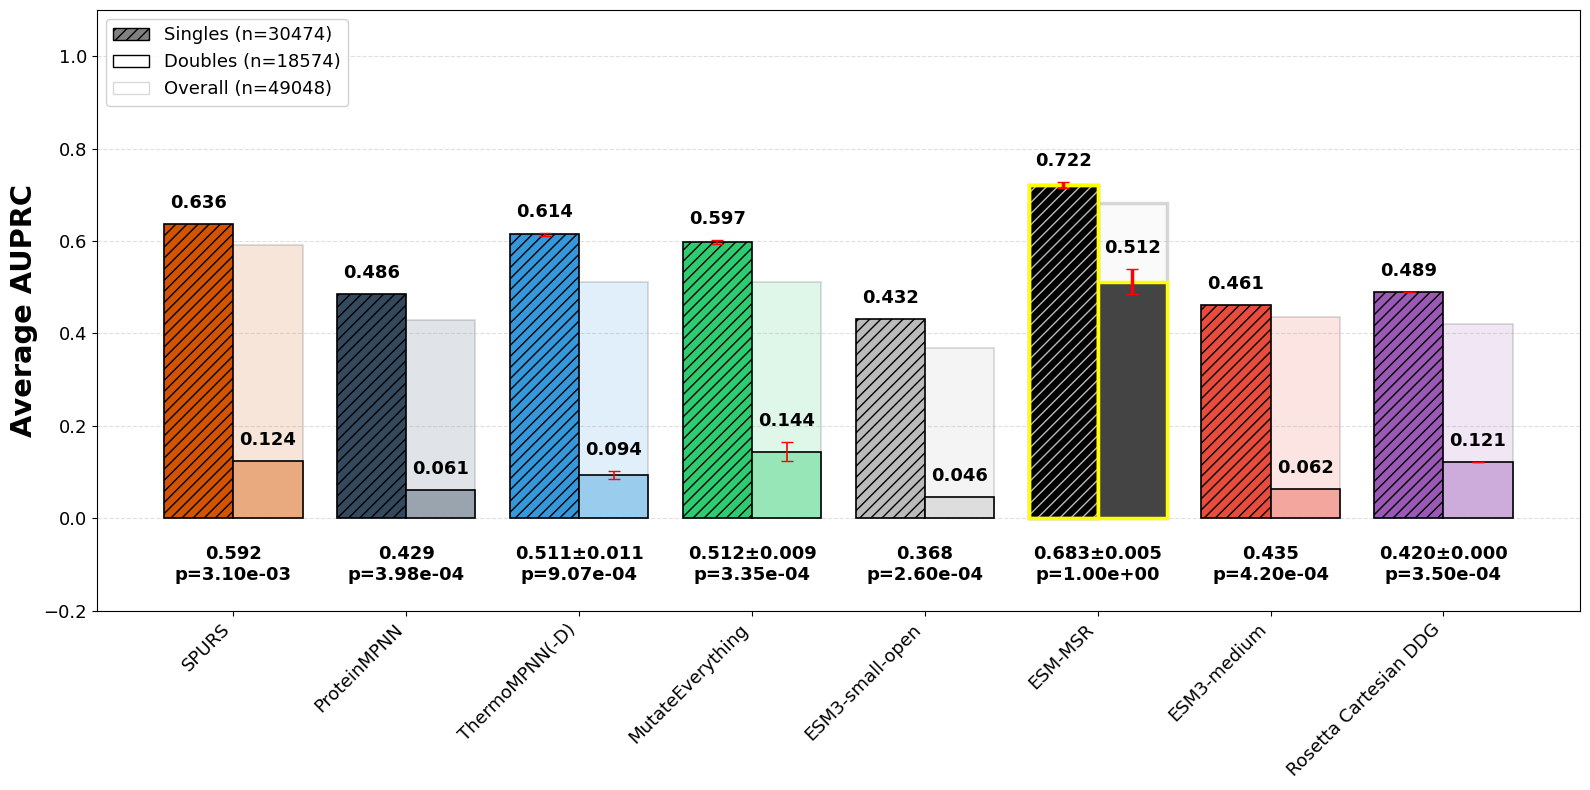

In [5]:
import analysis_utils_msr

analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_scores_cls.loc[('mega_splits-S-test', 'ungrouped')], 
                                      series_bar2=df_scores_cls.loc[('mega_splits-D-test', 'ungrouped')], 
                                      series_overall=df_scores_cls.loc[('mega_splits-test', 'ungrouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], # 'ESM3-small','ESM3-large',
                                      title=None, y_label='Average AUPRC', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,1.1), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left', is_grouped=False)

In [6]:
df_scores = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-S-test', 'mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores = assess_all_models(df, df_scores, assess_grouped_spearman, splits=splits, models=models)

df_scores

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
mega_splits-S-test ungrouped   0.779550  30474.000000               NaN   
                   grouped     0.857088   1015.800000              30.0   
mega_splits-D-test ungrouped   0.665302  18574.000000               NaN   
                   grouped     0.763197    928.700000              20.0   
mega_splits-test   ungrouped   0.799369  49048.000000               NaN   
                   grouped     0.868348   1634.933333              30.0   

                              ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
mega_splits-S-test ungrouped   0.788574  30474.000000               NaN   
                   grouped     0.865206   1015.800000              30.0   
mega_splits-D-test ungrouped   0.644333  18574.000000               NaN   
                   grouped     0.769908    928.700000              20.0   
mega_splits-test   ungrouped   0.793526  49048.000000               NaN   
                   grouped     0.871199   1634.933333              30.0   

                              ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped   0.787113  30474.000000               NaN   
                   grouped     0.861560   1015.800000              30.0   
mega_splits-D-test ungrouped   0.640476  18574.000000               NaN   
                   grouped     0.767056    928.700000              20.0   
mega_splits-test   ungrouped   0.796810  49048.000000               NaN   
                   grouped     0.870238   1634.933333              30.0   

                                 SPURS  ...  Rosetta Cartesian DDG_1_groups  \
mega_splits-S-test ungrouped  0.751466  ...                             NaN   
                   grouped    0.801343  ...                            30.0   
mega_splits-D-test ungrouped  0.574341  ...                             NaN   
                   grouped    0.617396  ...                            20.0   
mega_splits-test   ungrouped  0.788421  ...                             NaN   
                   grouped    0.806129  ...                            30.0   

                              Rosetta Cartesian DDG_2  \
mega_splits-S-test ungrouped                 0.621264   
                   grouped                   0.653521   
mega_splits-D-test ungrouped                 0.545980   
                   grouped                   0.458456   
mega_splits-test   ungrouped                 0.689657   
                   grouped                   0.675342   

                              Rosetta Cartesian DDG_2_n  \
mega_splits-S-test ungrouped               30474.000000   
                   grouped                  1015.800000   
mega_splits-D-test ungrouped               18574.000000   
                   grouped                   928.700000   
mega_splits-test   ungrouped               49048.000000   
                   grouped                  1634.933333   

                              Rosetta Cartesian DDG_2_groups  \
mega_splits-S-test ungrouped                             NaN   
                   grouped                              30.0   
mega_splits-D-test ungrouped                             NaN   
                   grouped                              20.0   
mega_splits-test   ungrouped                             NaN   
                   grouped                              30.0   

                              Rosetta Cartesian DDG_3  \
mega_splits-S-test ungrouped                 0.620956   
                   grouped                   0.654619   
mega_splits-D-test ungrouped                 0.546326   
                   grouped                   0.458491   
mega_splits-test   ungrouped                 0.689544   
                   grouped                   0.675849   

                              Rosetta Cartesian DDG_3_n  \
mega_splits-S-test ungrouped               30474.000000   
                   grouped                  1015.800000   
mega_splits-D-test ungrouped               18574.000000   

In [7]:
df_scores[[c for c in df_scores.columns if '_n' in c]].iloc[:,:15]

ESM-MSR_1_n   ESM-MSR_2_n   ESM-MSR_3_n  \
mega_splits-S-test ungrouped  30474.000000  30474.000000  30474.000000   
                   grouped     1015.800000   1015.800000   1015.800000   
mega_splits-D-test ungrouped  18574.000000  18574.000000  18574.000000   
                   grouped      928.700000    928.700000    928.700000   
mega_splits-test   ungrouped  49048.000000  49048.000000  49048.000000   
                   grouped     1634.933333   1634.933333   1634.933333   

                                   SPURS_n  ThermoMPNN(-D)_1_n  \
mega_splits-S-test ungrouped  30474.000000        30474.000000   
                   grouped     1015.800000         1015.800000   
mega_splits-D-test ungrouped  18574.000000        18574.000000   
                   grouped      928.700000          928.700000   
mega_splits-test   ungrouped  49048.000000        49048.000000   
                   grouped     1634.933333         1634.933333   

                              ThermoMPNN(-D)_2_n  ThermoMPNN(-D)_3_n  \
mega_splits-S-test ungrouped        30474.000000        30474.000000   
                   grouped           1015.800000         1015.800000   
mega_splits-D-test ungrouped        18574.000000        18574.000000   
                   grouped            928.700000          928.700000   
mega_splits-test   ungrouped        49048.000000        49048.000000   
                   grouped           1634.933333         1634.933333   

                              MutateEverything_1_n  MutateEverything_2_n  \
mega_splits-S-test ungrouped          30474.000000          30474.000000   
                   grouped             1015.800000           1015.800000   
mega_splits-D-test ungrouped          18574.000000          18574.000000   
                   grouped              928.700000            928.700000   
mega_splits-test   ungrouped          49048.000000          49048.000000   
                   grouped             1634.933333           1634.933333   

                              MutateEverything_3_n  ESM3-small-open_n  \
mega_splits-S-test ungrouped          30474.000000       30474.000000   
                   grouped             1015.800000        1015.800000   
mega_splits-D-test ungrouped          18574.000000       18574.000000   
                   grouped              928.700000         928.700000   
mega_splits-test   ungrouped          49048.000000       49048.000000   
                   grouped             1634.933333        1634.933333   

                              ESM3-small_n  ESM3-medium_n  ESM3-large_n  \
mega_splits-S-test ungrouped  30474.000000   30474.000000  30474.000000   
                   grouped     1015.800000    1015.800000   1015.800000   
mega_splits-D-test ungrouped  18574.000000   18574.000000  18574.000000   
                   grouped      928.700000     928.700000    928.700000   
mega_splits-test   ungrouped  49048.000000   49048.000000  49048.000000   
                   grouped     1634.933333    1634.933333   1634.933333   

                              Rosetta Cartesian DDG_1_n  
mega_splits-S-test ungrouped               30474.000000  
                   grouped                  1015.800000  
mega_splits-D-test ungrouped               18574.000000  
                   grouped                   928.700000  
mega_splits-test   ungrouped               49048.000000  
                   grouped                  1634.933333

In [8]:
df_scores[[c for c in df_scores.columns if '_n' in c]].iloc[:,15:]

Rosetta Cartesian DDG_2_n  \
mega_splits-S-test ungrouped               30474.000000   
                   grouped                  1015.800000   
mega_splits-D-test ungrouped               18574.000000   
                   grouped                   928.700000   
mega_splits-test   ungrouped               49048.000000   
                   grouped                  1634.933333   

                              Rosetta Cartesian DDG_3_n  ProteinMPNN_n  
mega_splits-S-test ungrouped               30474.000000   30474.000000  
                   grouped                  1015.800000    1015.800000  
mega_splits-D-test ungrouped               18574.000000   18574.000000  
                   grouped                   928.700000     928.700000  
mega_splits-test   ungrouped               49048.000000   49048.000000  
                   grouped                  1634.933333    1634.933333

In [9]:
df_scores[[c for c in df_scores.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
mega_splits-S-test ungrouped   0.779550               NaN   0.788574   
                   grouped     0.857088              30.0   0.865206   
mega_splits-D-test ungrouped   0.665302               NaN   0.644333   
                   grouped     0.763197              20.0   0.769908   
mega_splits-test   ungrouped   0.799369               NaN   0.793526   
                   grouped     0.868348              30.0   0.871199   

                              ESM-MSR_2_groups  ESM-MSR_3  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped               NaN   0.787113               NaN   
                   grouped                30.0   0.861560              30.0   
mega_splits-D-test ungrouped               NaN   0.640476               NaN   
                   grouped                20.0   0.767056              20.0   
mega_splits-test   ungrouped               NaN   0.796810               NaN   
                   grouped                30.0   0.870238              30.0   

                                 SPURS  SPURS_groups  ThermoMPNN(-D)_1  \
mega_splits-S-test ungrouped  0.751466           NaN          0.735399   
                   grouped    0.801343          30.0          0.773554   
mega_splits-D-test ungrouped  0.574341           NaN          0.532352   
                   grouped    0.617396          20.0          0.598817   
mega_splits-test   ungrouped  0.788421           NaN          0.747818   
                   grouped    0.806129          30.0          0.784183   

                              ThermoMPNN(-D)_1_groups  ThermoMPNN(-D)_2  \
mega_splits-S-test ungrouped                      NaN          0.733328   
                   grouped                       30.0          0.773402   
mega_splits-D-test ungrouped                      NaN          0.516236   
                   grouped                       20.0          0.601801   
mega_splits-test   ungrouped                      NaN          0.735843   
                   grouped                       30.0          0.779075   

                              ThermoMPNN(-D)_2_groups  ThermoMPNN(-D)_3  \
mega_splits-S-test ungrouped                      NaN          0.732734   
                   grouped                       30.0          0.772426   
mega_splits-D-test ungrouped                      NaN          0.526965   
                   grouped                       20.0          0.608076   
mega_splits-test   ungrouped                      NaN          0.759204   
                   grouped                       30.0          0.787159   

                              ThermoMPNN(-D)_3_groups  MutateEverything_1  
mega_splits-S-test ungrouped                      NaN            0.744470  
                   grouped                       30.0            0.762191  
mega_splits-D-test ungrouped                      NaN            0.540627  
                   grouped                       20.0            0.577689  
mega_splits-test   ungrouped                      NaN            0.754816  
                   grouped                       30.0            0.757477

In [10]:
df_scores[[c for c in df_scores.columns if not '_n' in c]].iloc[:,15:]

MutateEverything_1_groups  MutateEverything_2  \
mega_splits-S-test ungrouped                        NaN            0.736015   
                   grouped                         30.0            0.760408   
mega_splits-D-test ungrouped                        NaN            0.507356   
                   grouped                         20.0            0.580133   
mega_splits-test   ungrouped                        NaN            0.744699   
                   grouped                         30.0            0.758452   

                              MutateEverything_2_groups  MutateEverything_3  \
mega_splits-S-test ungrouped                        NaN            0.733927   
                   grouped                         30.0            0.756352   
mega_splits-D-test ungrouped                        NaN            0.508575   
                   grouped                         20.0            0.560730   
mega_splits-test   ungrouped                        NaN            0.747632   
                   grouped                         30.0            0.756767   

                              MutateEverything_3_groups  ESM3-small-open  \
mega_splits-S-test ungrouped                        NaN         0.478908   
                   grouped                         30.0         0.575082   
mega_splits-D-test ungrouped                        NaN         0.179156   
                   grouped                         20.0         0.343219   
mega_splits-test   ungrouped                        NaN         0.542181   
                   grouped                         30.0         0.610477   

                              ESM3-small-open_groups  ESM3-small  \
mega_splits-S-test ungrouped                     NaN    0.516314   
                   grouped                      30.0    0.607193   
mega_splits-D-test ungrouped                     NaN    0.178285   
                   grouped                      20.0    0.326832   
mega_splits-test   ungrouped                     NaN    0.560813   
                   grouped                      30.0    0.629837   

                              ESM3-small_groups  ESM3-medium  ...  ESM3-large  \
mega_splits-S-test ungrouped                NaN     0.509669  ...    0.456446   
                   grouped                 30.0     0.596303  ...    0.557476   
mega_splits-D-test ungrouped                NaN     0.155818  ...    0.165021   
                   grouped                 20.0     0.309784  ...    0.247209   
mega_splits-test   ungrouped                NaN     0.627807  ...    0.619886   
                   grouped                 30.0     0.633308  ...    0.598395   

                              ESM3-large_groups  Rosetta Cartesian DDG_1  \
mega_splits-S-test ungrouped                NaN                 0.619646   
                   grouped                 30.0                 0.652326   
mega_splits-D-test ungrouped                NaN                 0.546218   
                   grouped                 20.0                 0.460134   
mega_splits-test   ungrouped                NaN                 0.689413   
                   grouped                 30.0                 0.674591   

                              Rosetta Cartesian DDG_1_groups  \
mega_splits-S-test ungrouped                             NaN   
                   grouped                              30.0   
mega_splits-D-test ungrouped                             NaN   
                   grouped                              20.0   
mega_splits-test   ungrouped                             NaN   
                   grouped                              30.0   

                              Rosetta Cartesian DDG_2  \
mega_splits-S-test ungrouped                 0.621264   
                   grouped                   0.653521   
mega_splits-D-test ungrouped                 0.545980   
                   grouped                   0.458456   
mega_splits-test   ungrouped                 0.689657   
                   g

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

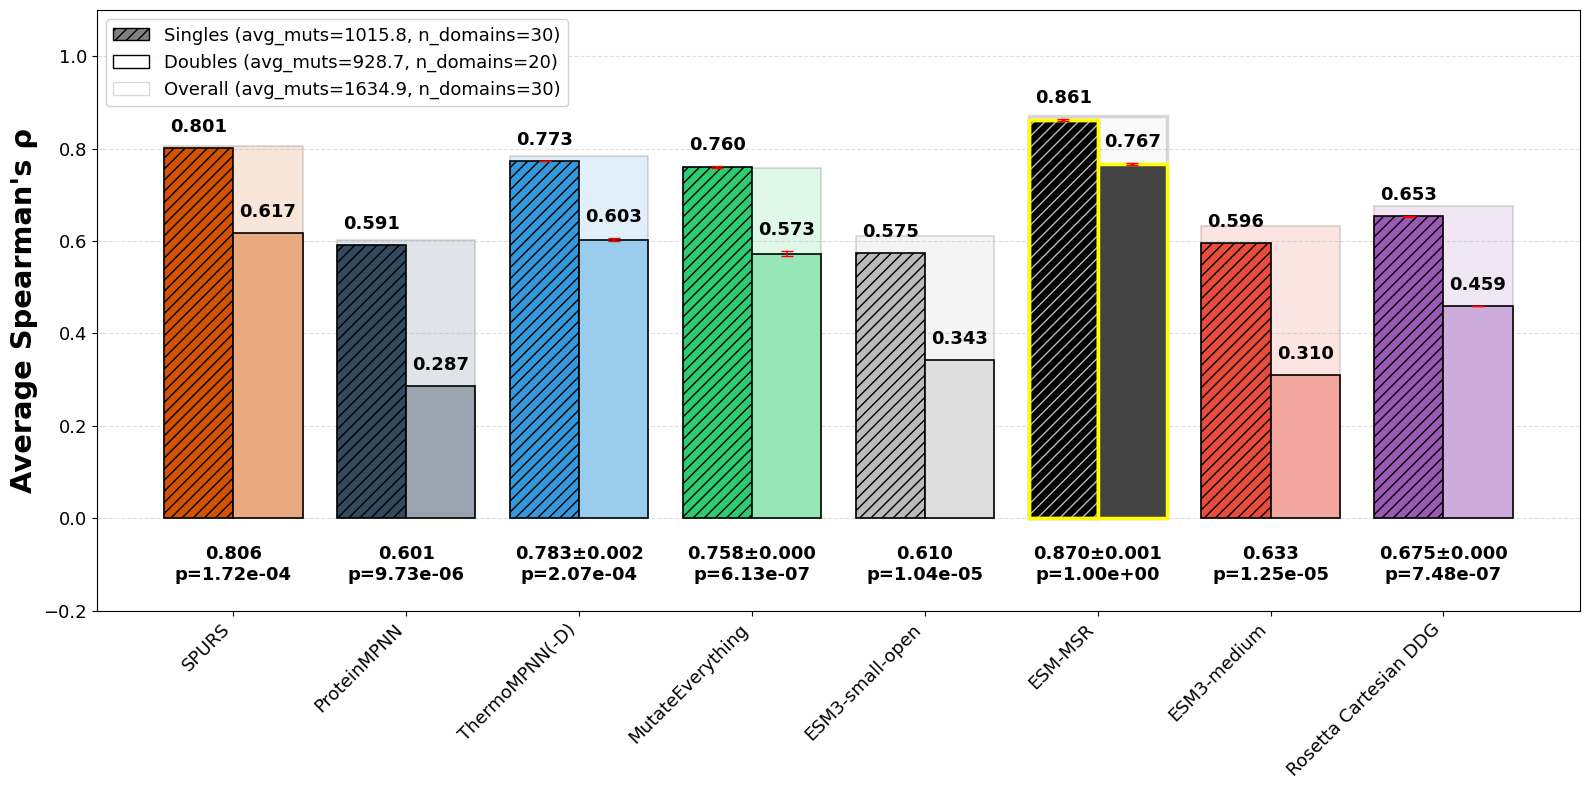

In [11]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_scores.loc[('mega_splits-S-test', 'grouped')], 
                                      series_bar2=df_scores.loc[('mega_splits-D-test', 'grouped')], 
                                      series_overall=df_scores.loc[('mega_splits-test', 'grouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], # 'ESM3-small','ESM3-large',
                                      title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,1.1), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [12]:
df_gain = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-S-test', 'mega_splits-D-test'], ['ungrouped', 'grouped']]))
df_gain = assess_all_models(df, df_gain, assess_grouped_gain, splits=splits, models=models)
df_gain
df_gain[[c for c in df_gain.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
mega_splits-S-test ungrouped  88.371522               NaN  86.919666   
                   grouped    34.732048              30.0  35.672403   
mega_splits-D-test ungrouped  38.046015               NaN  33.334672   
                   grouped     4.487524              20.0   4.675707   
mega_splits-test   ungrouped  86.933553               NaN  85.275686   
                   grouped    33.549490              30.0  35.053494   

                              ESM-MSR_2_groups  ESM-MSR_3  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped               NaN  87.908399               NaN   
                   grouped                30.0  34.842847              30.0   
mega_splits-D-test ungrouped               NaN  35.754073               NaN   
                   grouped                20.0   4.455500              20.0   
mega_splits-test   ungrouped               NaN  84.526218               NaN   
                   grouped                30.0  33.692015              30.0   

                                  SPURS  SPURS_groups  ThermoMPNN(-D)_1  \
mega_splits-S-test ungrouped  87.080338           NaN         76.242882   
                   grouped    30.042822          30.0         28.735049   
mega_splits-D-test ungrouped  14.237706           NaN          0.767212   
                   grouped     2.859484          20.0          2.767658   
mega_splits-test   ungrouped  85.069419           NaN         37.805821   
                   grouped    29.471517          30.0         27.499889   

                              ThermoMPNN(-D)_1_groups  ThermoMPNN(-D)_2  \
mega_splits-S-test ungrouped                      NaN         82.126847   
                   grouped                       30.0         28.447547   
mega_splits-D-test ungrouped                      NaN          0.237010   
                   grouped                       20.0          2.538342   
mega_splits-test   ungrouped                      NaN         36.308043   
                   grouped                       30.0         27.495967   

                              ThermoMPNN(-D)_2_groups  ThermoMPNN(-D)_3  \
mega_splits-S-test ungrouped                      NaN         73.537176   
                   grouped                       30.0         27.866799   
mega_splits-D-test ungrouped                      NaN          6.809126   
                   grouped                       20.0          3.229060   
mega_splits-test   ungrouped                      NaN         55.997272   
                   grouped                       30.0         27.654096   

                              ThermoMPNN(-D)_3_groups  MutateEverything_1  
mega_splits-S-test ungrouped                      NaN           67.760871  
                   grouped                       30.0           26.164949  
mega_splits-D-test ungrouped                      NaN           10.531690  
                   grouped                       20.0            2.632034  
mega_splits-test   ungrouped                      NaN           46.652328  
                   grouped                       30.0           24.345409

In [13]:
df_ndcg24 = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-S-test', 'mega_splits-D-test'], ['ungrouped', 'grouped']]))

# 1. Freeze the top_n argument into a new callable
assess_ndcg_24 = partial(assess_grouped_ndcg, top_n=24)

# 2. Pass the frozen function into your wrapper
df_ndcg24 = assess_all_models(df, df_ndcg24, assess_ndcg_24, splits=splits, models=models)

df_ndcg24
df_ndcg24[[c for c in df_ndcg24.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
mega_splits-S-test ungrouped   0.384845               NaN   0.354834   
                   grouped     0.555312              30.0   0.587477   
mega_splits-D-test ungrouped   0.278308               NaN   0.276133   
                   grouped     0.514652              20.0   0.560507   
mega_splits-test   ungrouped   0.367576               NaN   0.333825   
                   grouped     0.538739              30.0   0.568491   

                              ESM-MSR_2_groups  ESM-MSR_3  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped               NaN   0.372788               NaN   
                   grouped                30.0   0.580380              30.0   
mega_splits-D-test ungrouped               NaN   0.236741               NaN   
                   grouped                20.0   0.490076              20.0   
mega_splits-test   ungrouped               NaN   0.348812               NaN   
                   grouped                30.0   0.563239              30.0   

                                 SPURS  SPURS_groups  ThermoMPNN(-D)_1  \
mega_splits-S-test ungrouped  0.521979           NaN          0.513626   
                   grouped    0.517504          30.0          0.472260   
mega_splits-D-test ungrouped  0.059582           NaN          0.000000   
                   grouped    0.387808          20.0          0.249293   
mega_splits-test   ungrouped  0.509872           NaN          0.413352   
                   grouped    0.505249          30.0          0.425280   

                              ThermoMPNN(-D)_1_groups  ThermoMPNN(-D)_2  \
mega_splits-S-test ungrouped                      NaN          0.580477   
                   grouped                       30.0          0.478311   
mega_splits-D-test ungrouped                      NaN          0.000331   
                   grouped                       20.0          0.293605   
mega_splits-test   ungrouped                      NaN          0.505996   
                   grouped                       30.0          0.441104   

                              ThermoMPNN(-D)_2_groups  ThermoMPNN(-D)_3  \
mega_splits-S-test ungrouped                      NaN          0.508388   
                   grouped                       30.0          0.456010   
mega_splits-D-test ungrouped                      NaN          0.053501   
                   grouped                       20.0          0.326165   
mega_splits-test   ungrouped                      NaN          0.469330   
                   grouped                       30.0          0.438864   

                              ThermoMPNN(-D)_3_groups  MutateEverything_1  
mega_splits-S-test ungrouped                      NaN            0.413216  
                   grouped                       30.0            0.426112  
mega_splits-D-test ungrouped                      NaN            0.060297  
                   grouped                       20.0            0.417106  
mega_splits-test   ungrouped                      NaN            0.184752  
                   grouped                       30.0            0.386955

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average NDCG@k=24'>)

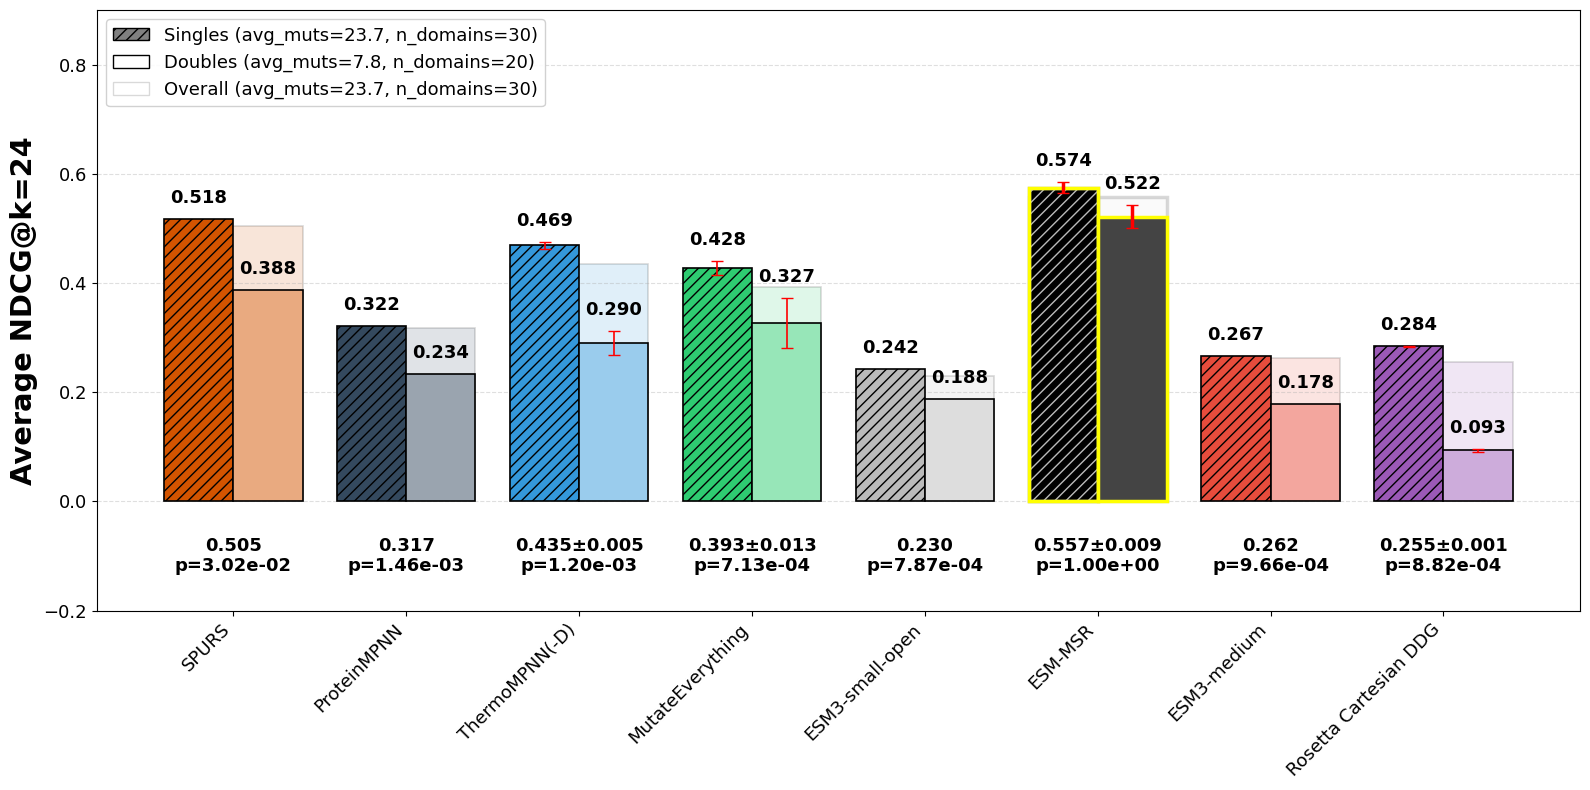

In [14]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg24.loc[('mega_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg24.loc[('mega_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg24.loc[('mega_splits-test', 'grouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], # 'ESM3-small','ESM3-large',
                                      title=None, y_label='Average NDCG@k=24', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,0.9), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [15]:
df_ndcg96 = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-S-test', 'mega_splits-D-test'], ['ungrouped', 'grouped']]))

# 1. Freeze the top_n argument into a new callable
assess_ndcg_96 = partial(assess_grouped_ndcg, top_n=96)

# 2. Pass the frozen function into your wrapper
df_ndcg96 = assess_all_models(df, df_ndcg96, assess_ndcg_96, splits=splits, models=models)

df_ndcg96
df_ndcg96[[c for c in df_ndcg96.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
mega_splits-S-test ungrouped   0.454921               NaN   0.441172   
                   grouped     0.620805              30.0   0.642271   
mega_splits-D-test ungrouped   0.358934               NaN   0.324425   
                   grouped     0.595540              20.0   0.630239   
mega_splits-test   ungrouped   0.437395               NaN   0.423271   
                   grouped     0.602658              30.0   0.624195   

                              ESM-MSR_2_groups  ESM-MSR_3  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped               NaN   0.445753               NaN   
                   grouped                30.0   0.631039              30.0   
mega_splits-D-test ungrouped               NaN   0.338424               NaN   
                   grouped                20.0   0.564365              20.0   
mega_splits-test   ungrouped               NaN   0.422580               NaN   
                   grouped                30.0   0.611248              30.0   

                                 SPURS  SPURS_groups  ThermoMPNN(-D)_1  \
mega_splits-S-test ungrouped  0.520505           NaN          0.467873   
                   grouped    0.545117          30.0          0.509112   
mega_splits-D-test ungrouped  0.123115           NaN          0.006228   
                   grouped    0.442249          20.0          0.352914   
mega_splits-test   ungrouped  0.502302           NaN          0.284246   
                   grouped    0.527272          30.0          0.469689   

                              ThermoMPNN(-D)_1_groups  ThermoMPNN(-D)_2  \
mega_splits-S-test ungrouped                      NaN          0.514062   
                   grouped                       30.0          0.510813   
mega_splits-D-test ungrouped                      NaN          0.002010   
                   grouped                       20.0          0.345547   
mega_splits-test   ungrouped                      NaN          0.306920   
                   grouped                       30.0          0.476563   

                              ThermoMPNN(-D)_2_groups  ThermoMPNN(-D)_3  \
mega_splits-S-test ungrouped                      NaN          0.461412   
                   grouped                       30.0          0.491909   
mega_splits-D-test ungrouped                      NaN          0.062327   
                   grouped                       20.0          0.398473   
mega_splits-test   ungrouped                      NaN          0.376282   
                   grouped                       30.0          0.473945   

                              ThermoMPNN(-D)_3_groups  MutateEverything_1  
mega_splits-S-test ungrouped                      NaN            0.390081  
                   grouped                       30.0            0.469291  
mega_splits-D-test ungrouped                      NaN            0.091856  
                   grouped                       20.0            0.491321  
mega_splits-test   ungrouped                      NaN            0.243655  
                   grouped                       30.0            0.432378

In [16]:
df_ndcg96[[c for c in df_ndcg96.columns if '_n' in c]].iloc[:,:15]

ESM-MSR_1_n  ESM-MSR_2_n  ESM-MSR_3_n  \
mega_splits-S-test ungrouped    96.000000    96.000000    96.000000   
                   grouped      92.766667    92.766667    92.766667   
mega_splits-D-test ungrouped    96.000000    96.000000    96.000000   
                   grouped      15.200000    15.200000    15.200000   
mega_splits-test   ungrouped    96.000000    96.000000    96.000000   
                   grouped      93.133333    93.133333    93.133333   

                                SPURS_n  ThermoMPNN(-D)_1_n  \
mega_splits-S-test ungrouped  96.000000           96.000000   
                   grouped    92.766667           92.766667   
mega_splits-D-test ungrouped  96.000000           96.000000   
                   grouped    15.200000           15.200000   
mega_splits-test   ungrouped  96.000000           96.000000   
                   grouped    93.133333           93.133333   

                              ThermoMPNN(-D)_2_n  ThermoMPNN(-D)_3_n  \
mega_splits-S-test ungrouped           96.000000           96.000000   
                   grouped             92.766667           92.766667   
mega_splits-D-test ungrouped           96.000000           96.000000   
                   grouped             15.200000           15.200000   
mega_splits-test   ungrouped           96.000000           96.000000   
                   grouped             93.133333           93.133333   

                              MutateEverything_1_n  MutateEverything_2_n  \
mega_splits-S-test ungrouped             96.000000             96.000000   
                   grouped               92.766667             92.766667   
mega_splits-D-test ungrouped             96.000000             96.000000   
                   grouped               15.200000             15.200000   
mega_splits-test   ungrouped             96.000000             96.000000   
                   grouped               93.133333             93.133333   

                              MutateEverything_3_n  ESM3-small-open_n  \
mega_splits-S-test ungrouped             96.000000          96.000000   
                   grouped               92.766667          92.766667   
mega_splits-D-test ungrouped             96.000000          96.000000   
                   grouped               15.200000          15.200000   
mega_splits-test   ungrouped             96.000000          96.000000   
                   grouped               93.133333          93.133333   

                              ESM3-small_n  ESM3-medium_n  ESM3-large_n  \
mega_splits-S-test ungrouped     96.000000      96.000000     96.000000   
                   grouped       92.766667      92.766667     92.766667   
mega_splits-D-test ungrouped     96.000000      96.000000     96.000000   
                   grouped       15.200000      15.200000     15.200000   
mega_splits-test   ungrouped     96.000000      96.000000     96.000000   
                   grouped       93.133333      93.133333     93.133333   

                              Rosetta Cartesian DDG_1_n  
mega_splits-S-test ungrouped                  96.000000  
                   grouped                    92.766667  
mega_splits-D-test ungrouped                  96.000000  
                   grouped                    15.200000  
mega_splits-test   ungrouped                  96.000000  
                   grouped                    93.133333

In [17]:
df_ndcg96_no_cys = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-S-test', 'mega_splits-D-test'], ['ungrouped', 'grouped']]))
df_no_cys = df.loc[~df.index.str.endswith('C')]
df_ndcg96_no_cys = assess_all_models(df_no_cys, df_ndcg96_no_cys, assess_ndcg_96, splits=splits, models=models)
df_ndcg96_no_cys
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if not '_n' in c]].iloc[:,:15]

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
mega_splits-S-test ungrouped   0.459956               NaN   0.448461   
                   grouped     0.625762              30.0   0.649099   
mega_splits-D-test ungrouped   0.363290               NaN   0.392740   
                   grouped     0.602387              20.0   0.586709   
mega_splits-test   ungrouped   0.455449               NaN   0.439671   
                   grouped     0.610207              30.0   0.635186   

                              ESM-MSR_2_groups  ESM-MSR_3  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped               NaN   0.447245               NaN   
                   grouped                30.0   0.637357              30.0   
mega_splits-D-test ungrouped               NaN   0.332376               NaN   
                   grouped                20.0   0.568702              20.0   
mega_splits-test   ungrouped               NaN   0.441664               NaN   
                   grouped                30.0   0.621273              30.0   

                                 SPURS  SPURS_groups  ThermoMPNN(-D)_1  \
mega_splits-S-test ungrouped  0.531093           NaN          0.475442   
                   grouped    0.549555          30.0          0.518250   
mega_splits-D-test ungrouped  0.110181           NaN          0.007089   
                   grouped    0.397294          20.0          0.374372   
mega_splits-test   ungrouped  0.522807           NaN          0.285531   
                   grouped    0.534715          30.0          0.480165   

                              ThermoMPNN(-D)_1_groups  ThermoMPNN(-D)_2  \
mega_splits-S-test ungrouped                      NaN          0.491277   
                   grouped                       30.0          0.512932   
mega_splits-D-test ungrouped                      NaN          0.001291   
                   grouped                       20.0          0.364964   
mega_splits-test   ungrouped                      NaN          0.297186   
                   grouped                       30.0          0.476045   

                              ThermoMPNN(-D)_2_groups  ThermoMPNN(-D)_3  \
mega_splits-S-test ungrouped                      NaN          0.460613   
                   grouped                       30.0          0.498237   
mega_splits-D-test ungrouped                      NaN          0.074215   
                   grouped                       20.0          0.406796   
mega_splits-test   ungrouped                      NaN          0.370888   
                   grouped                       30.0          0.482642   

                              ThermoMPNN(-D)_3_groups  MutateEverything_1  
mega_splits-S-test ungrouped                      NaN            0.411266  
                   grouped                       30.0            0.467957  
mega_splits-D-test ungrouped                      NaN            0.087037  
                   grouped                       20.0            0.444625  
mega_splits-test   ungrouped                      NaN            0.250902  
                   grouped                       30.0            0.436613

In [18]:
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if '_n' in c]].iloc[:,:15]

ESM-MSR_1_n  ESM-MSR_2_n  ESM-MSR_3_n  \
mega_splits-S-test ungrouped    96.000000    96.000000    96.000000   
                   grouped      92.533333    92.533333    92.533333   
mega_splits-D-test ungrouped    96.000000    96.000000    96.000000   
                   grouped      13.750000    13.750000    13.750000   
mega_splits-test   ungrouped    96.000000    96.000000    96.000000   
                   grouped      92.866667    92.866667    92.866667   

                                SPURS_n  ThermoMPNN(-D)_1_n  \
mega_splits-S-test ungrouped  96.000000           96.000000   
                   grouped    92.533333           92.533333   
mega_splits-D-test ungrouped  96.000000           96.000000   
                   grouped    13.750000           13.750000   
mega_splits-test   ungrouped  96.000000           96.000000   
                   grouped    92.866667           92.866667   

                              ThermoMPNN(-D)_2_n  ThermoMPNN(-D)_3_n  \
mega_splits-S-test ungrouped           96.000000           96.000000   
                   grouped             92.533333           92.533333   
mega_splits-D-test ungrouped           96.000000           96.000000   
                   grouped             13.750000           13.750000   
mega_splits-test   ungrouped           96.000000           96.000000   
                   grouped             92.866667           92.866667   

                              MutateEverything_1_n  MutateEverything_2_n  \
mega_splits-S-test ungrouped             96.000000             96.000000   
                   grouped               92.533333             92.533333   
mega_splits-D-test ungrouped             96.000000             96.000000   
                   grouped               13.750000             13.750000   
mega_splits-test   ungrouped             96.000000             96.000000   
                   grouped               92.866667             92.866667   

                              MutateEverything_3_n  ESM3-small-open_n  \
mega_splits-S-test ungrouped             96.000000          96.000000   
                   grouped               92.533333          92.533333   
mega_splits-D-test ungrouped             96.000000          96.000000   
                   grouped               13.750000          13.750000   
mega_splits-test   ungrouped             96.000000          96.000000   
                   grouped               92.866667          92.866667   

                              ESM3-small_n  ESM3-medium_n  ESM3-large_n  \
mega_splits-S-test ungrouped     96.000000      96.000000     96.000000   
                   grouped       92.533333      92.533333     92.533333   
mega_splits-D-test ungrouped     96.000000      96.000000     96.000000   
                   grouped       13.750000      13.750000     13.750000   
mega_splits-test   ungrouped     96.000000      96.000000     96.000000   
                   grouped       92.866667      92.866667     92.866667   

                              Rosetta Cartesian DDG_1_n  
mega_splits-S-test ungrouped                  96.000000  
                   grouped                    92.533333  
mega_splits-D-test ungrouped                  96.000000  
                   grouped                    13.750000  
mega_splits-test   ungrouped                  96.000000  
                   grouped                    92.866667

In [19]:
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if '_group' in c]].iloc[:,:15]

ESM-MSR_1_groups  ESM-MSR_2_groups  \
mega_splits-S-test ungrouped               NaN               NaN   
                   grouped                30.0              30.0   
mega_splits-D-test ungrouped               NaN               NaN   
                   grouped                20.0              20.0   
mega_splits-test   ungrouped               NaN               NaN   
                   grouped                30.0              30.0   

                              ESM-MSR_3_groups  SPURS_groups  \
mega_splits-S-test ungrouped               NaN           NaN   
                   grouped                30.0          30.0   
mega_splits-D-test ungrouped               NaN           NaN   
                   grouped                20.0          20.0   
mega_splits-test   ungrouped               NaN           NaN   
                   grouped                30.0          30.0   

                              ThermoMPNN(-D)_1_groups  \
mega_splits-S-test ungrouped                      NaN   
                   grouped                       30.0   
mega_splits-D-test ungrouped                      NaN   
                   grouped                       20.0   
mega_splits-test   ungrouped                      NaN   
                   grouped                       30.0   

                              ThermoMPNN(-D)_2_groups  \
mega_splits-S-test ungrouped                      NaN   
                   grouped                       30.0   
mega_splits-D-test ungrouped                      NaN   
                   grouped                       20.0   
mega_splits-test   ungrouped                      NaN   
                   grouped                       30.0   

                              ThermoMPNN(-D)_3_groups  \
mega_splits-S-test ungrouped                      NaN   
                   grouped                       30.0   
mega_splits-D-test ungrouped                      NaN   
                   grouped                       20.0   
mega_splits-test   ungrouped                      NaN   
                   grouped                       30.0   

                              MutateEverything_1_groups  \
mega_splits-S-test ungrouped                        NaN   
                   grouped                         30.0   
mega_splits-D-test ungrouped                        NaN   
                   grouped                         20.0   
mega_splits-test   ungrouped                        NaN   
                   grouped                         30.0   

                              MutateEverything_2_groups  \
mega_splits-S-test ungrouped                        NaN   
                   grouped                         30.0   
mega_splits-D-test ungrouped                        NaN   
                   grouped                         20.0   
mega_splits-test   ungrouped                        NaN   
                   grouped                         30.0   

                              MutateEverything_3_groups  \
mega_splits-S-test ungrouped                        NaN   
                   grouped                         30.0   
mega_splits-D-test ungrouped                        NaN   
                   grouped                         20.0   
mega_splits-test   ungrouped                        NaN   
                   grouped                         30.0   

                              ESM3-small-open_groups  ESM3-small_groups  \
mega_splits-S-test ungrouped                     NaN                NaN   
                   grouped                      30.0               30.0   
mega_splits-D-test ungrouped                     NaN                NaN   
                   grouped                      20.0               20.0   
mega_splits-test   ungrouped                     NaN                NaN   
                   grouped                      30.0               30.0   

                              ESM3-medium_groups  ESM3-large_groups  \
mega_splits-S-test ungrouped                 NaN                N

In [20]:
df_ndcg96_no_cys[[c for c in df_ndcg96_no_cys.columns if '_n' in c]].iloc[:,15:30]

Rosetta Cartesian DDG_2_n  \
mega_splits-S-test ungrouped                  96.000000   
                   grouped                    92.533333   
mega_splits-D-test ungrouped                  96.000000   
                   grouped                    13.750000   
mega_splits-test   ungrouped                  96.000000   
                   grouped                    92.866667   

                              Rosetta Cartesian DDG_3_n  ProteinMPNN_n  
mega_splits-S-test ungrouped                  96.000000      96.000000  
                   grouped                    92.533333      92.533333  
mega_splits-D-test ungrouped                  96.000000      96.000000  
                   grouped                    13.750000      13.750000  
mega_splits-test   ungrouped                  96.000000      96.000000  
                   grouped                    92.866667      92.866667

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average NDCG@k=96'>)

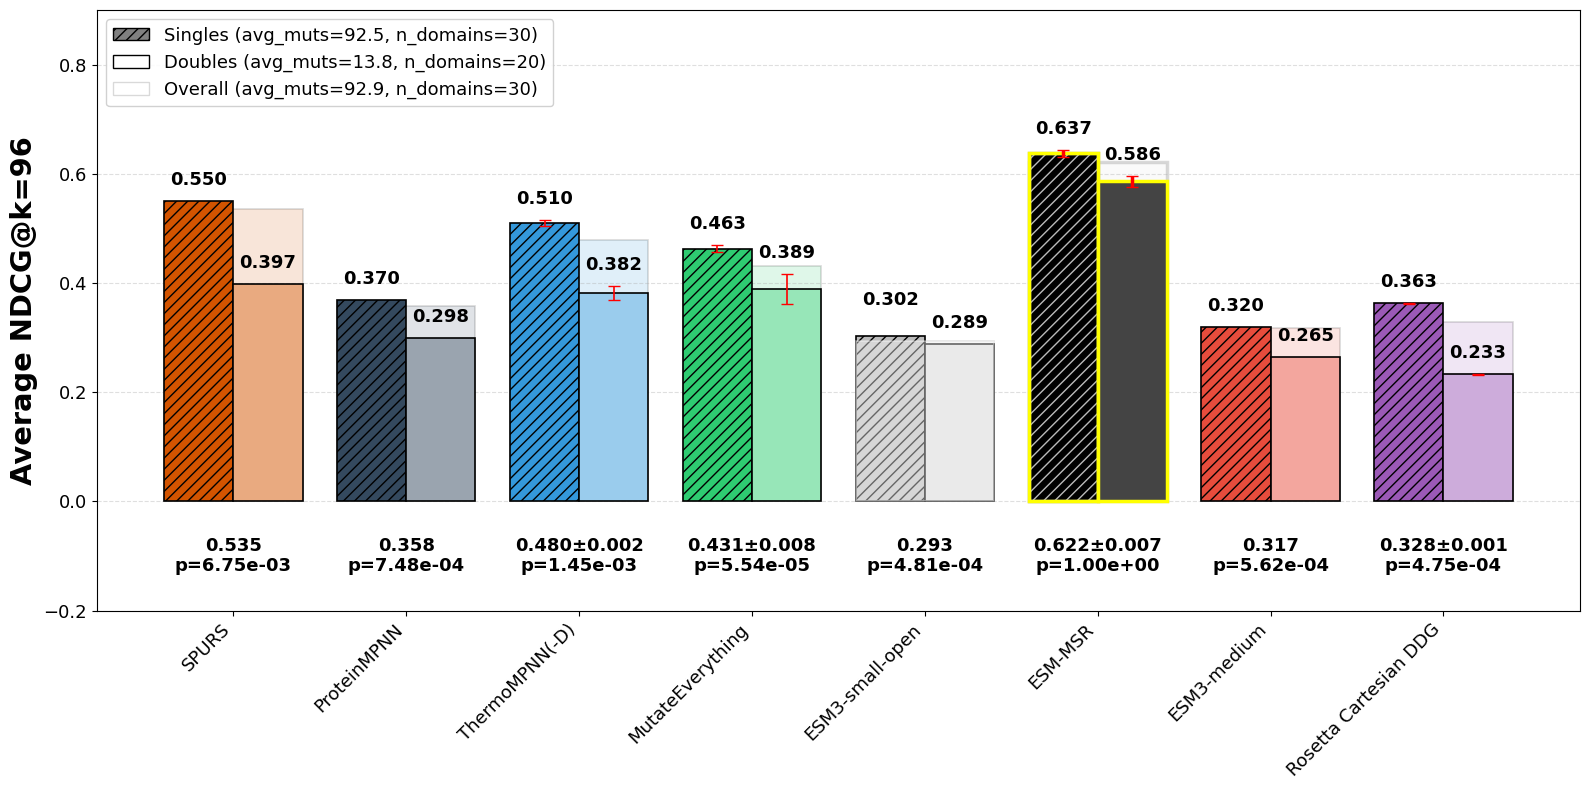

In [21]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)

analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg96_no_cys.loc[('mega_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg96_no_cys.loc[('mega_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg96_no_cys.loc[('mega_splits-test', 'grouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], # 'ESM3-small','ESM3-large',
                                      title=None, y_label='Average NDCG@k=96', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,0.9), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel='Average NDCG@k=96'>)

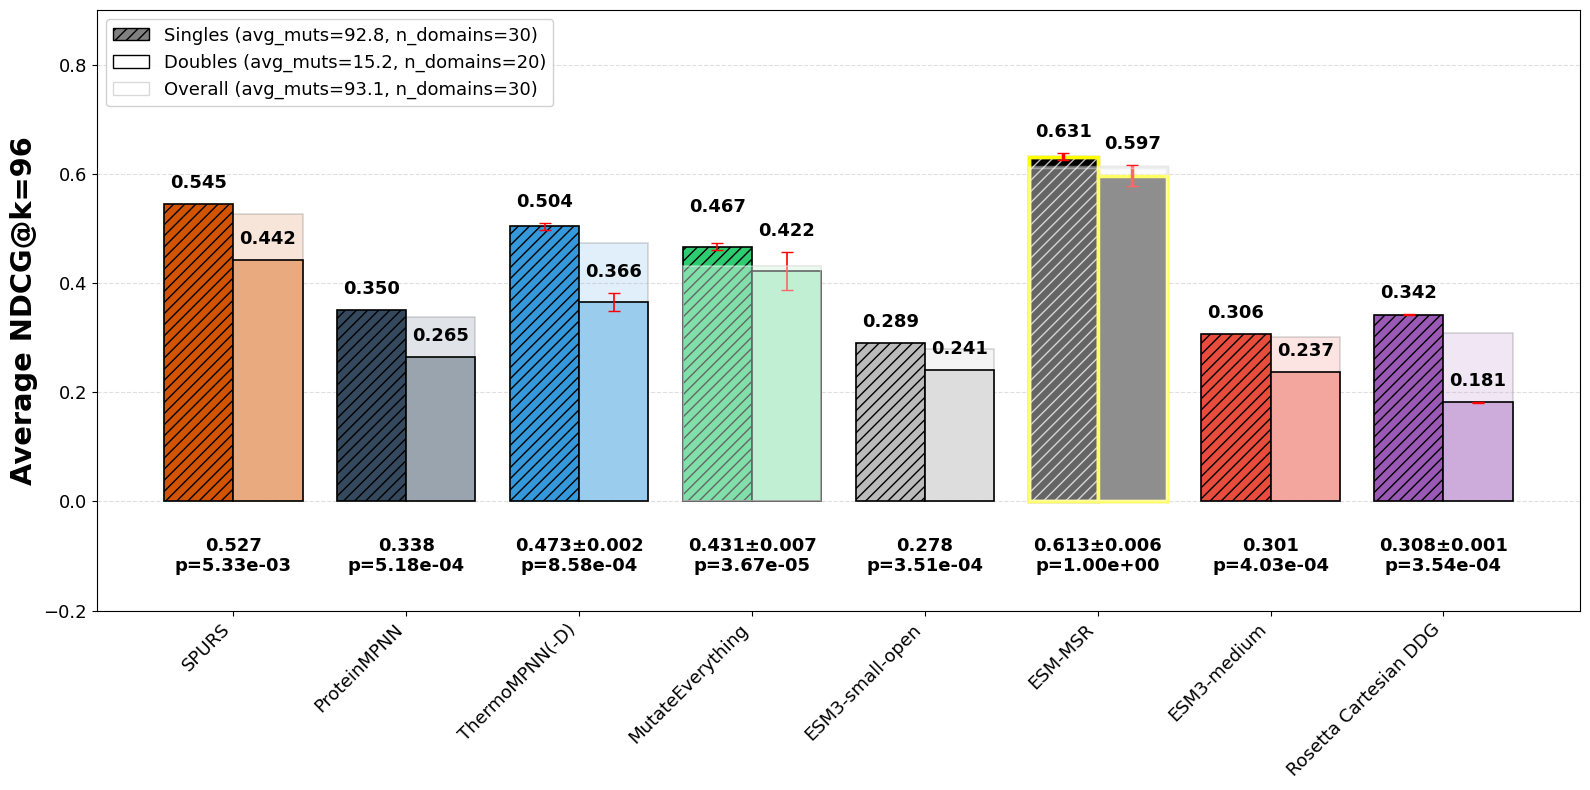

In [47]:
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg96.loc[('mega_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg96.loc[('mega_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg96.loc[('mega_splits-test', 'grouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], # 'ESM3-small','ESM3-large',
                                      title=None, y_label='Average NDCG@k=96', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,0.9), figsize=(16,8), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [23]:
df_ndcg_pos = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-S-test', 'mega_splits-D-test'], ['ungrouped', 'grouped']]))

# 1. Freeze the top_n argument into a new callable
assess_ndcg_pos = partial(assess_grouped_ndcg, threshold=0)

# 2. Pass the frozen function into your wrapper
df_ndcg_pos = assess_all_models(df, df_ndcg_pos, assess_ndcg_pos, splits=splits, models=models)

df_ndcg_pos
df_ndcg_pos[[c for c in df_ndcg_pos.columns if not '_n' in c]].iloc[:,:15]


ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_groups  ESM-MSR_2  \
mega_splits-S-test ungrouped   0.865375               NaN   0.870178   
                   grouped     0.815019              30.0   0.823520   
mega_splits-D-test ungrouped   0.722317               NaN   0.708734   
                   grouped     0.642258              20.0   0.679220   
mega_splits-test   ungrouped   0.860336               NaN   0.864757   
                   grouped     0.808228              30.0   0.815882   

                              ESM-MSR_2_groups  ESM-MSR_3  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped               NaN   0.866866               NaN   
                   grouped                30.0   0.821077              30.0   
mega_splits-D-test ungrouped               NaN   0.720934               NaN   
                   grouped                20.0   0.612837              20.0   
mega_splits-test   ungrouped               NaN   0.861948               NaN   
                   grouped                30.0   0.813512              30.0   

                                 SPURS  SPURS_groups  ThermoMPNN(-D)_1  \
mega_splits-S-test ungrouped  0.860222           NaN          0.849647   
                   grouped    0.785415          30.0          0.761320   
mega_splits-D-test ungrouped  0.551461           NaN          0.510183   
                   grouped    0.517117          20.0          0.436573   
mega_splits-test   ungrouped  0.850485           NaN          0.811152   
                   grouped    0.775920          30.0          0.739663   

                              ThermoMPNN(-D)_1_groups  ThermoMPNN(-D)_2  \
mega_splits-S-test ungrouped                      NaN          0.852528   
                   grouped                       30.0          0.762715   
mega_splits-D-test ungrouped                      NaN          0.497885   
                   grouped                       20.0          0.438801   
mega_splits-test   ungrouped                      NaN          0.818725   
                   grouped                       30.0          0.743511   

                              ThermoMPNN(-D)_2_groups  ThermoMPNN(-D)_3  \
mega_splits-S-test ungrouped                      NaN          0.848355   
                   grouped                       30.0          0.753975   
mega_splits-D-test ungrouped                      NaN          0.529937   
                   grouped                       20.0          0.475488   
mega_splits-test   ungrouped                      NaN          0.826063   
                   grouped                       30.0          0.743315   

                              ThermoMPNN(-D)_3_groups  MutateEverything_1  
mega_splits-S-test ungrouped                      NaN            0.829494  
                   grouped                       30.0            0.743497  
mega_splits-D-test ungrouped                      NaN            0.571394  
                   grouped                       20.0            0.556906  
mega_splits-test   ungrouped                      NaN            0.801741  
                   grouped                       30.0            0.726414

(<Figure size 1600x600 with 1 Axes>, <Axes: ylabel='Average NDCG'>)

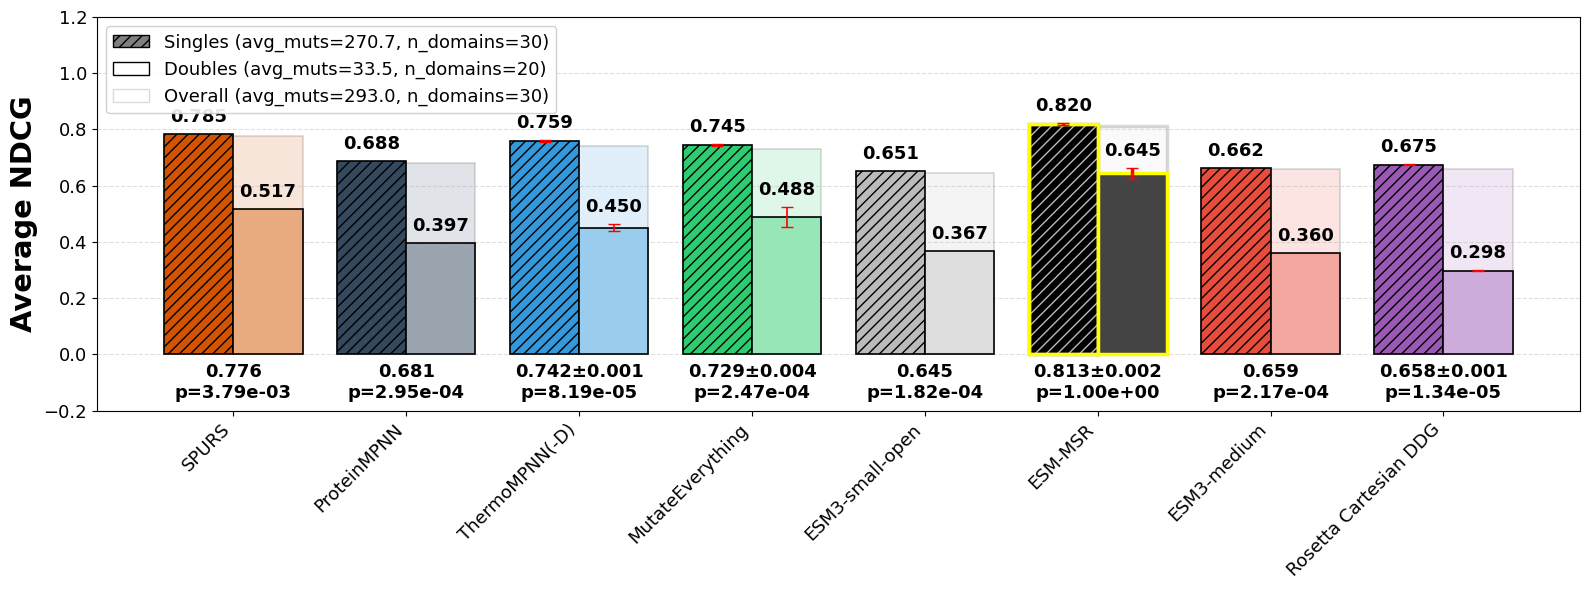

In [24]:
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=df_ndcg_pos.loc[('mega_splits-S-test', 'grouped')], 
                                      series_bar2=df_ndcg_pos.loc[('mega_splits-D-test', 'grouped')], 
                                      series_overall=df_ndcg_pos.loc[('mega_splits-test', 'grouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], # 'ESM3-small','ESM3-large',
                                      title=None, y_label='Average NDCG', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(-0.2,1.2), figsize=(16,6), p_value_y_coord=-0.1, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left')

In [25]:
# add additive scores
# should be 556 mutants missing
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)
#from analysis_utils_msr import sum_individual_mutation_scores

#cols = df.columns.drop('code').drop('mut_type')
#cols = ['Rosetta Cartesian DDG_1', 'Rosetta Cartesian DDG_2', 'Rosetta Cartesian DDG_3', 'ddG_ML_me']
cols = ['ddG']
df_epistatic = df.copy(deep=True)

#print(len(df.loc[df['mut_type'].str.contains(':')]))
for c in cols:
    if not c.endswith('_n'):
        print(c)
        # synthesize additive mutation predictions and scores
        df_epistatic = sum_individual_mutation_scores(df_epistatic, c, new_score_column=None) #, df_missing, missing1, missing2

#df_epistatic = df_epistatic[[c for c in df_epistatic.columns if 'additive' in c] + ['code', 'ddG', 'mut_type']]
df_epistatic = df_epistatic[[c for c in df_epistatic.columns if not c.endswith('_n')]]
df_epistatic = df_epistatic.dropna(subset='ESM-MSR_1')
#df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN(-D)_1_additive'] = df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN_1']
#df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN(-D)_2_additive'] = df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN_2']
#df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN(-D)_3_additive'] = df_epistatic.loc[df_epistatic.index.str.contains(':'), 'ThermoMPNN_3']

#print(len(df_epistatic))
#df_epistatic['ThermoMPNN(-D)_1_additive'].dropna()

ddG


In [26]:
# Get all grouped and ungrouped ranking correlations for epistatic / combined mutants

df_scores_epistatic = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

assess_all_models(df_epistatic.loc[df_epistatic['mut_type'].str.contains(':')], df_scores_epistatic, assess_grouped_spearman, splits=['mega_splits-D-test'], models=models)

df_scores_epistatic

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_n  ESM-MSR_1_groups  \
mega_splits-D-test ungrouped   0.665302      18574.0               NaN   
                   grouped     0.763197        928.7              20.0   

                              ESM-MSR_2  ESM-MSR_2_n  ESM-MSR_2_groups  \
mega_splits-D-test ungrouped   0.644333      18574.0               NaN   
                   grouped     0.769908        928.7              20.0   

                              ESM-MSR_3  ESM-MSR_3_n  ESM-MSR_3_groups  \
mega_splits-D-test ungrouped   0.640476      18574.0               NaN   
                   grouped     0.767056        928.7              20.0   

                                 SPURS  ...  Rosetta Cartesian DDG_1_groups  \
mega_splits-D-test ungrouped  0.574341  ...                             NaN   
                   grouped    0.617396  ...                            20.0   

                              Rosetta Cartesian DDG_2  \
mega_splits-D-test ungrouped                 0.545980   
                   grouped                   0.458456   

                              Rosetta Cartesian DDG_2_n  \
mega_splits-D-test ungrouped                    18574.0   
                   grouped                        928.7   

                              Rosetta Cartesian DDG_2_groups  \
mega_splits-D-test ungrouped                             NaN   
                   grouped                              20.0   

                              Rosetta Cartesian DDG_3  \
mega_splits-D-test ungrouped                 0.546326   
                   grouped                   0.458491   

                              Rosetta Cartesian DDG_3_n  \
mega_splits-D-test ungrouped                    18574.0   
                   grouped                        928.7   

                              Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
mega_splits-D-test ungrouped                             NaN     0.245714   
                   grouped                              20.0     0.287008   

                              ProteinMPNN_n  ProteinMPNN_groups  
mega_splits-D-test ungrouped        18574.0                 NaN  
                   grouped            928.7                20.0  

[2 rows x 54 columns]

In [27]:
assess_all_models(df_epistatic.loc[df_epistatic['mut_type'].str.contains(':')], df_scores_epistatic, assess_grouped_spearman, splits=['mega_splits-D-test'], add_suffix='_additive', models=models)
df_scores_epistatic = assess_grouped_spearman(df_epistatic.loc[df_epistatic['mut_type'].str.contains(':')], df_scores_epistatic, 'Negative_additive', 'mega_splits-D-test', pred_col='ddG_additive', label='ddG')

df_scores_epistatic

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1  ESM-MSR_1_n  ESM-MSR_1_groups  \
mega_splits-D-test ungrouped   0.665302      18574.0               NaN   
                   grouped     0.763197        928.7              20.0   

                              ESM-MSR_2  ESM-MSR_2_n  ESM-MSR_2_groups  \
mega_splits-D-test ungrouped   0.644333      18574.0               NaN   
                   grouped     0.769908        928.7              20.0   

                              ESM-MSR_3  ESM-MSR_3_n  ESM-MSR_3_groups  \
mega_splits-D-test ungrouped   0.640476      18574.0               NaN   
                   grouped     0.767056        928.7              20.0   

                                 SPURS  ...  \
mega_splits-D-test ungrouped  0.574341  ...   
                   grouped    0.617396  ...   

                              Rosetta Cartesian DDG_additive_2_groups  \
mega_splits-D-test ungrouped                                      NaN   
                   grouped                                       20.0   

                              Rosetta Cartesian DDG_additive_3  \
mega_splits-D-test ungrouped                          0.390181   
                   grouped                            0.324274   

                              Rosetta Cartesian DDG_additive_3_n  \
mega_splits-D-test ungrouped                             18574.0   
                   grouped                                 928.7   

                              Rosetta Cartesian DDG_additive_3_groups  \
mega_splits-D-test ungrouped                                      NaN   
                   grouped                                       20.0   

                              ProteinMPNN_additive  ProteinMPNN_additive_n  \
mega_splits-D-test ungrouped              0.240287                 18574.0   
                   grouped                0.274768                   928.7   

                              ProteinMPNN_additive_groups  Negative_additive  \
mega_splits-D-test ungrouped                          NaN           0.754454   
                   grouped                           20.0           0.719863   

                              Negative_additive_n  Negative_additive_groups  
mega_splits-D-test ungrouped             16923.00                       NaN  
                   grouped                 846.15                      20.0  

[2 rows x 111 columns]

In [28]:
# Peek at the additive correlations

df_scores_additive_2 = df_scores_epistatic[[c for c in df_scores_epistatic.columns if c.endswith('_additive')]]#.dropna()
df_scores_additive_2.columns = [c[:-9] for c in df_scores_additive_2.columns]
df_scores_additive_2

SPURS  ESM3-small-open  ESM3-small  \
mega_splits-D-test ungrouped  0.492120         0.180305    0.203179   
                   grouped    0.542813         0.320124    0.335717   

                              ESM3-medium  ESM3-large  ProteinMPNN  Negative  
mega_splits-D-test ungrouped     0.218462    0.131301     0.240287  0.754454  
                   grouped       0.304683    0.197443     0.274768  0.719863

In [29]:
# compress replicates into mean and stdev
df_scores_std_2 = unify_similar_columns(df_scores_additive_2)
df_scores_std_2

SPURS  ESM3-small-open  ESM3-small  \
mega_splits-D-test ungrouped  0.492120         0.180305    0.203179   
                   grouped    0.542813         0.320124    0.335717   

                              ESM3-medium  ESM3-large  ProteinMPNN  Negative  
mega_splits-D-test ungrouped     0.218462    0.131301     0.240287  0.754454  
                   grouped       0.304683    0.197443     0.274768  0.719863

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

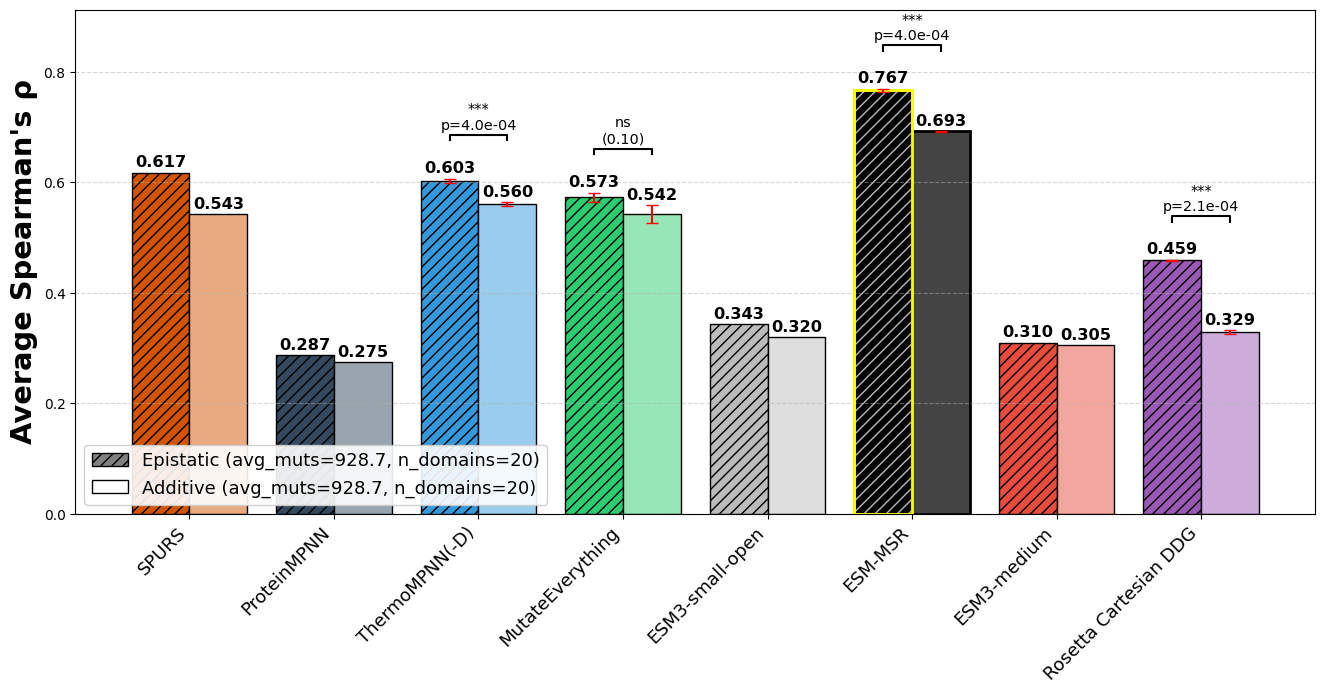

In [30]:
# For ~52,000 testing doubles, compare additive approximation to original (combined/epistatic) prediction (grouped by structure, then take mean)
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_epistatic.loc[('mega_splits-D-test', 'grouped')], 
                                                            ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], 
                                                            highlighted_model='ESM-MSR', title=None, y_label='Average Spearman\'s ρ', figsize=(16,8), bracket_height_factor=0.05, fontsize_multiplier=1.3, legend_loc='lower left') 

(<Figure size 1600x600 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

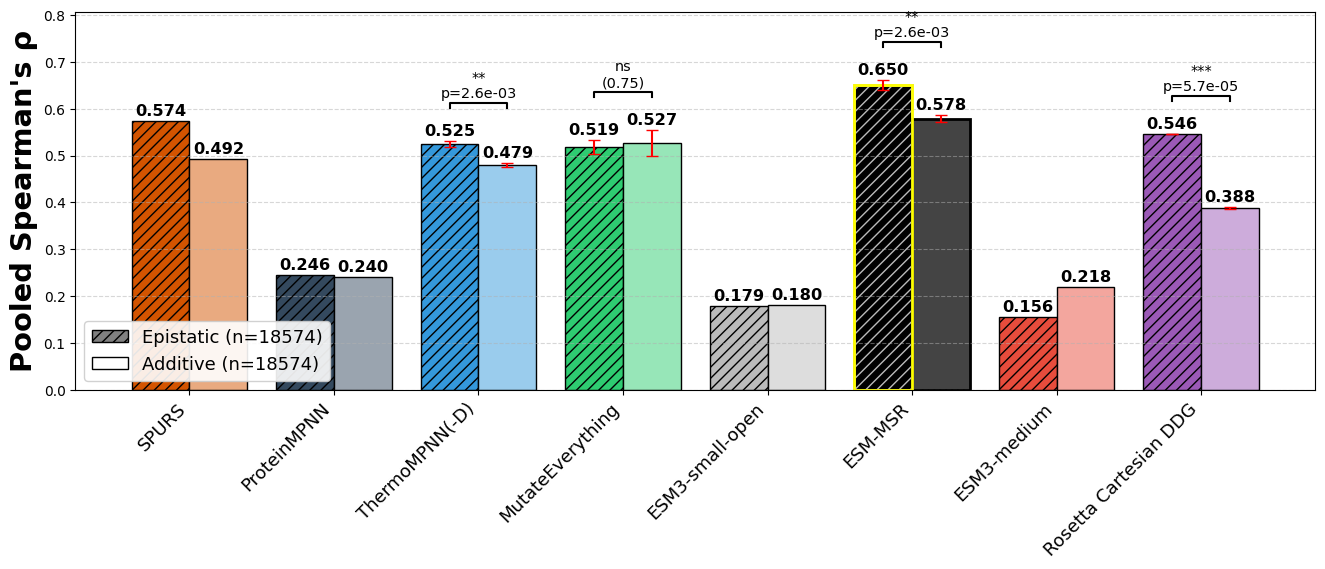

In [46]:
# For ~52,000 testing doubles, compare additive approximation to original (combined/epistatic) prediction (pool all predictions together)

analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_epistatic.loc[('mega_splits-D-test', 'ungrouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], # 'ESM3-small','ESM3-large',
                                        highlighted_model='ESM-MSR', title=None, y_label='Pooled Spearman\'s ρ', figsize=(16,6), is_grouped=False, legend_loc='lower left') 

In [32]:
# repeat analysis for specifically only stabilizing or destabilizing mutations

df_pos = df.loc[df['ddG']>0]

df_scores_pos = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-test'], ['ungrouped', 'grouped']]))
df_scores_pos_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_pos = assess_all_models(df_pos, df_scores_pos, assess_grouped_spearman, splits=['mega_splits-test'], models=models)
df_scores_pos_doubles = assess_all_models(df_pos, df_scores_pos_doubles, assess_grouped_spearman, splits=['mega_splits-D-test'], models=models)

df_neg = df.loc[df['ddG']<=0]

df_scores_neg = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-test'], ['ungrouped', 'grouped']]))
df_scores_neg_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_neg = assess_all_models(df_neg, df_scores_neg, assess_grouped_spearman, splits=['mega_splits-test'], models=models)
df_scores_neg_doubles = assess_all_models(df_neg, df_scores_neg_doubles, assess_grouped_spearman, splits=['mega_splits-D-test'], models=models)

df_scores_combined = df_scores.join(df_scores_pos, rsuffix='_pos').join(df_scores_neg, rsuffix='_neg')
df_scores_combined

df_scores_combined_doubles = df_scores.join(df_scores_pos_doubles, rsuffix='_pos').join(df_scores_neg_doubles, rsuffix='_neg')
df_scores_combined_doubles

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN
ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN
ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN
ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-s

ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
mega_splits-S-test ungrouped   0.779550  30474.000000               NaN   
                   grouped     0.857088   1015.800000              30.0   
mega_splits-D-test ungrouped   0.665302  18574.000000               NaN   
                   grouped     0.763197    928.700000              20.0   
mega_splits-test   ungrouped   0.799369  49048.000000               NaN   
                   grouped     0.868348   1634.933333              30.0   

                              ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
mega_splits-S-test ungrouped   0.788574  30474.000000               NaN   
                   grouped     0.865206   1015.800000              30.0   
mega_splits-D-test ungrouped   0.644333  18574.000000               NaN   
                   grouped     0.769908    928.700000              20.0   
mega_splits-test   ungrouped   0.793526  49048.000000               NaN   
                   grouped     0.871199   1634.933333              30.0   

                              ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped   0.787113  30474.000000               NaN   
                   grouped     0.861560   1015.800000              30.0   
mega_splits-D-test ungrouped   0.640476  18574.000000               NaN   
                   grouped     0.767056    928.700000              20.0   
mega_splits-test   ungrouped   0.796810  49048.000000               NaN   
                   grouped     0.870238   1634.933333              30.0   

                                 SPURS  ...  \
mega_splits-S-test ungrouped  0.751466  ...   
                   grouped    0.801343  ...   
mega_splits-D-test ungrouped  0.574341  ...   
                   grouped    0.617396  ...   
mega_splits-test   ungrouped  0.788421  ...   
                   grouped    0.806129  ...   

                              Rosetta Cartesian DDG_1_groups_neg  \
mega_splits-S-test ungrouped                                 NaN   
                   grouped                                   NaN   
mega_splits-D-test ungrouped                                 NaN   
                   grouped                                  20.0   
mega_splits-test   ungrouped                                 NaN   
                   grouped                                   NaN   

                              Rosetta Cartesian DDG_2_neg  \
mega_splits-S-test ungrouped                          NaN   
                   grouped                            NaN   
mega_splits-D-test ungrouped                     0.524270   
                   grouped                       0.466629   
mega_splits-test   ungrouped                          NaN   
                   grouped                            NaN   

                              Rosetta Cartesian DDG_2_n_neg  \
mega_splits-S-test ungrouped                            NaN   
                   grouped                              NaN   
mega_splits-D-test ungrouped                       17905.00   
                   grouped                           895.25   
mega_splits-test   ungrouped                            NaN   
                   grouped                              NaN   

                              Rosetta Cartesian DDG_2_groups_neg  \
mega_splits-S-test ungrouped                                 NaN   
                   grouped                                   NaN   
mega_splits-D-test ungrouped                                 NaN   
                   grouped                                  20.0   
mega_splits-test   ungrouped                                 NaN   
                   grouped                                   NaN   

                              Rosetta Cartesian DDG_3_neg  \
mega_splits-S-test ungrouped                          NaN   
                   grouped                            NaN   
mega_splits-D-test ungrouped                     0.524615   
                   grouped                       0.466

In [33]:
df_scores_combined[[c for c in df_scores_combined.columns if ('SPURS' in c and '_group' in c)]]

SPURS_groups  SPURS_groups_pos  SPURS_groups_neg
mega_splits-S-test ungrouped           NaN               NaN               NaN
                   grouped            30.0               NaN               NaN
mega_splits-D-test ungrouped           NaN               NaN               NaN
                   grouped            20.0               NaN               NaN
mega_splits-test   ungrouped           NaN               NaN               NaN
                   grouped            30.0              30.0              30.0

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

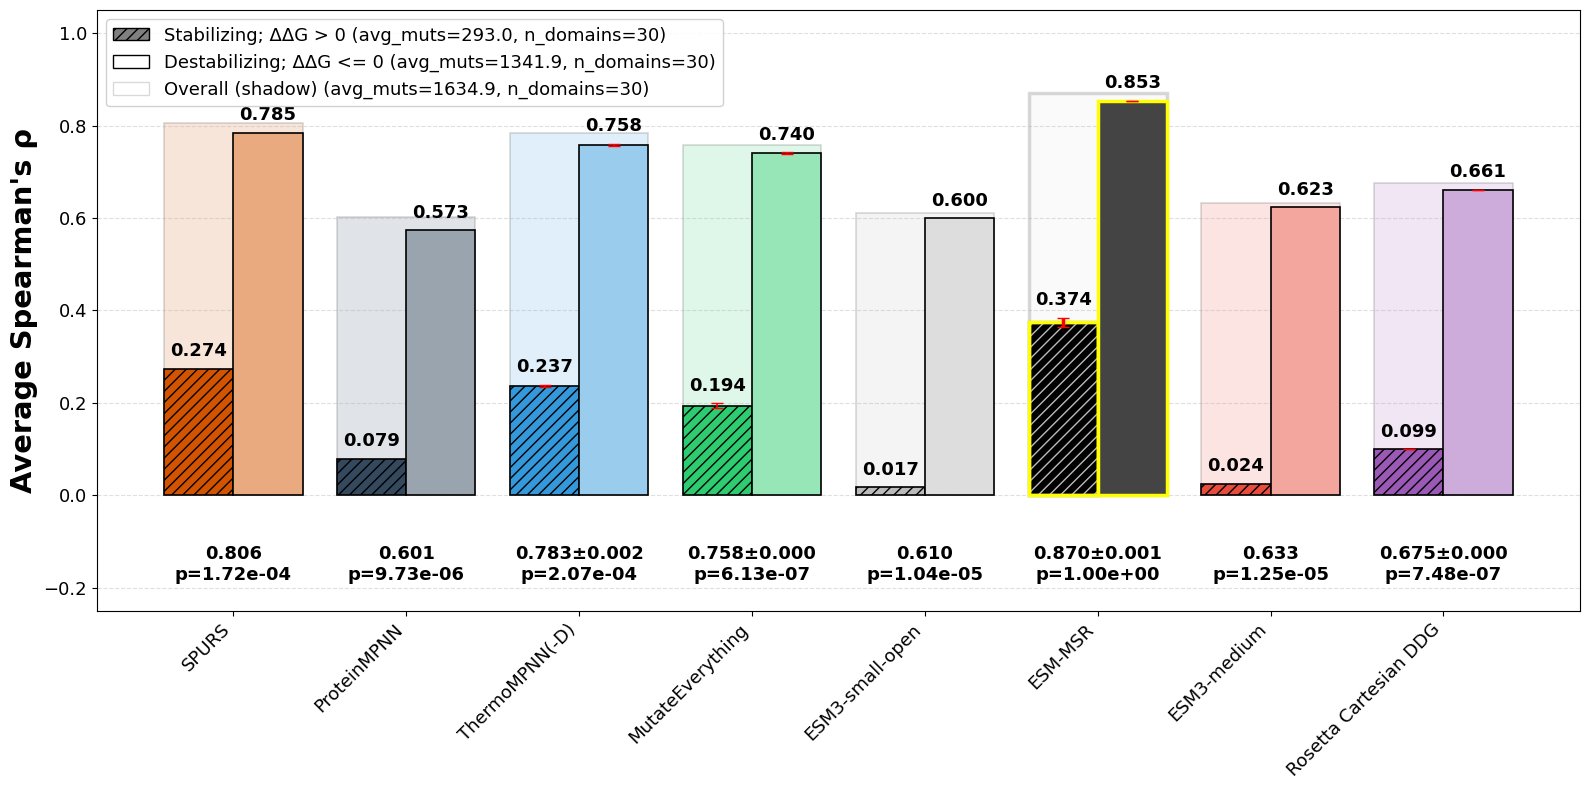

In [34]:
import analysis_utils_msr
import importlib
importlib.reload(analysis_utils_msr) 

analysis_utils_msr.create_pos_neg_overall_chart(
    df_scores_combined.loc[('mega_splits-test', 'grouped')], 
    ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], p_value_y_coord=-0.15,
    title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=True, epistasis=False, figsize=(16, 8), ylim=(-0.25, 1.05), legend_loc='upper left', fontsize_multiplier=1.3) #'ESM-MSR_direct',

(<Figure size 1400x600 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

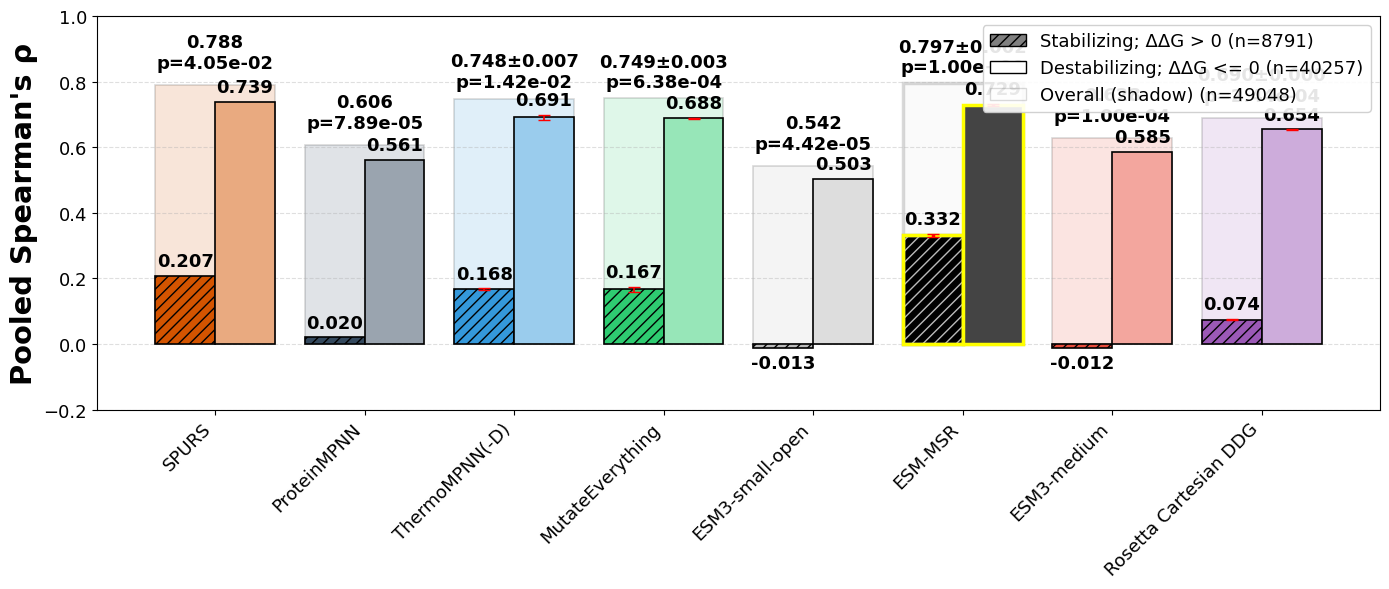

In [35]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_combined.loc[('mega_splits-test', 'ungrouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], title=None, y_label='Pooled Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, epistasis=False, ylim=(-0.2, 1), is_grouped=False, fontsize_multiplier=1.3) #'ESM-MSR_direct', 

In [36]:
# repeat pos vs neg analysis, for doubles only now

df_pos = df.loc[df['ddG']>0] #.dropna()
df_scores_pos_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_pos_doubles = assess_all_models(df_pos.loc[df_pos['mut_type'].str.contains(':')], df_scores_pos_doubles, assess_grouped_spearman, splits=('mega_splits-D-test', 'mega_splits-test'), models=models)

df_neg = df.loc[df['ddG']<=0] #.dropna()
df_scores_neg_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_neg_doubles = assess_all_models(df_neg.loc[df_neg['mut_type'].str.contains(':')], df_scores_neg_doubles, assess_grouped_spearman, splits=('mega_splits-D-test', 'mega_splits-test'), models=models)

df_scores_combined_doubles = df_scores.join(df_scores_pos_doubles, rsuffix='_pos').join(df_scores_neg_doubles, rsuffix='_neg')
df_scores_combined_doubles

ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN
ESM-MSR_1
ESM-MSR_2
ESM-MSR_3
SPURS
ThermoMPNN(-D)_1
ThermoMPNN(-D)_2
ThermoMPNN(-D)_3
MutateEverything_1
MutateEverything_2
MutateEverything_3
ESM3-small-open
ESM3-small
ESM3-medium
ESM3-large
Rosetta Cartesian DDG_1
Rosetta Cartesian DDG_2
Rosetta Cartesian DDG_3
ProteinMPNN


ESM-MSR_1   ESM-MSR_1_n  ESM-MSR_1_groups  \
mega_splits-S-test ungrouped   0.779550  30474.000000               NaN   
                   grouped     0.857088   1015.800000              30.0   
mega_splits-D-test ungrouped   0.665302  18574.000000               NaN   
                   grouped     0.763197    928.700000              20.0   
mega_splits-test   ungrouped   0.799369  49048.000000               NaN   
                   grouped     0.868348   1634.933333              30.0   

                              ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
mega_splits-S-test ungrouped   0.788574  30474.000000               NaN   
                   grouped     0.865206   1015.800000              30.0   
mega_splits-D-test ungrouped   0.644333  18574.000000               NaN   
                   grouped     0.769908    928.700000              20.0   
mega_splits-test   ungrouped   0.793526  49048.000000               NaN   
                   grouped     0.871199   1634.933333              30.0   

                              ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
mega_splits-S-test ungrouped   0.787113  30474.000000               NaN   
                   grouped     0.861560   1015.800000              30.0   
mega_splits-D-test ungrouped   0.640476  18574.000000               NaN   
                   grouped     0.767056    928.700000              20.0   
mega_splits-test   ungrouped   0.796810  49048.000000               NaN   
                   grouped     0.870238   1634.933333              30.0   

                                 SPURS  ...  \
mega_splits-S-test ungrouped  0.751466  ...   
                   grouped    0.801343  ...   
mega_splits-D-test ungrouped  0.574341  ...   
                   grouped    0.617396  ...   
mega_splits-test   ungrouped  0.788421  ...   
                   grouped    0.806129  ...   

                              Rosetta Cartesian DDG_1_groups_neg  \
mega_splits-S-test ungrouped                                 NaN   
                   grouped                                   NaN   
mega_splits-D-test ungrouped                                 NaN   
                   grouped                                  20.0   
mega_splits-test   ungrouped                                 NaN   
                   grouped                                  20.0   

                              Rosetta Cartesian DDG_2_neg  \
mega_splits-S-test ungrouped                          NaN   
                   grouped                            NaN   
mega_splits-D-test ungrouped                     0.524270   
                   grouped                       0.466629   
mega_splits-test   ungrouped                     0.524270   
                   grouped                       0.466629   

                              Rosetta Cartesian DDG_2_n_neg  \
mega_splits-S-test ungrouped                            NaN   
                   grouped                              NaN   
mega_splits-D-test ungrouped                       17905.00   
                   grouped                           895.25   
mega_splits-test   ungrouped                       17905.00   
                   grouped                           895.25   

                              Rosetta Cartesian DDG_2_groups_neg  \
mega_splits-S-test ungrouped                                 NaN   
                   grouped                                   NaN   
mega_splits-D-test ungrouped                                 NaN   
                   grouped                                  20.0   
mega_splits-test   ungrouped                                 NaN   
                   grouped                                  20.0   

                              Rosetta Cartesian DDG_3_neg  \
mega_splits-S-test ungrouped                          NaN   
                   grouped                            NaN   
mega_splits-D-test ungrouped                     0.524615   
                   grouped                       0.466

(<Figure size 1400x600 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

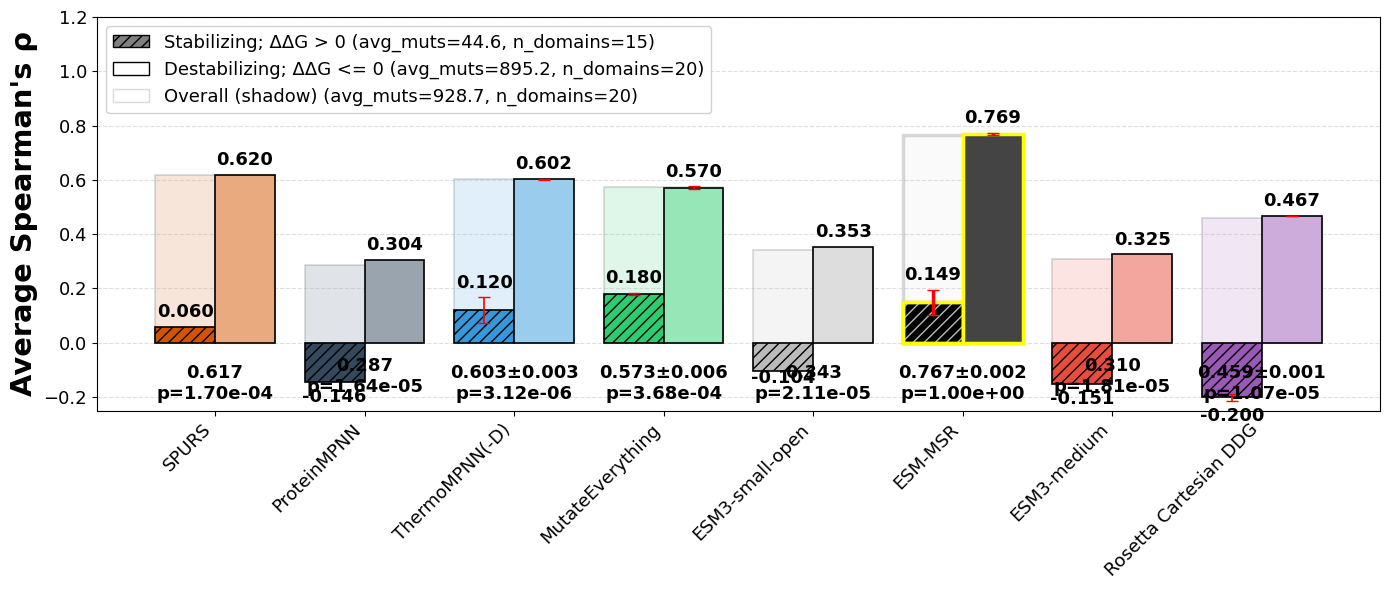

In [37]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_combined_doubles.loc[('mega_splits-D-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, epistasis=False, fontsize_multiplier=1.3, legend_loc='upper left', ylim=(-0.25, 1.2), p_value_y_coord=-0.15)

(<Figure size 1400x600 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

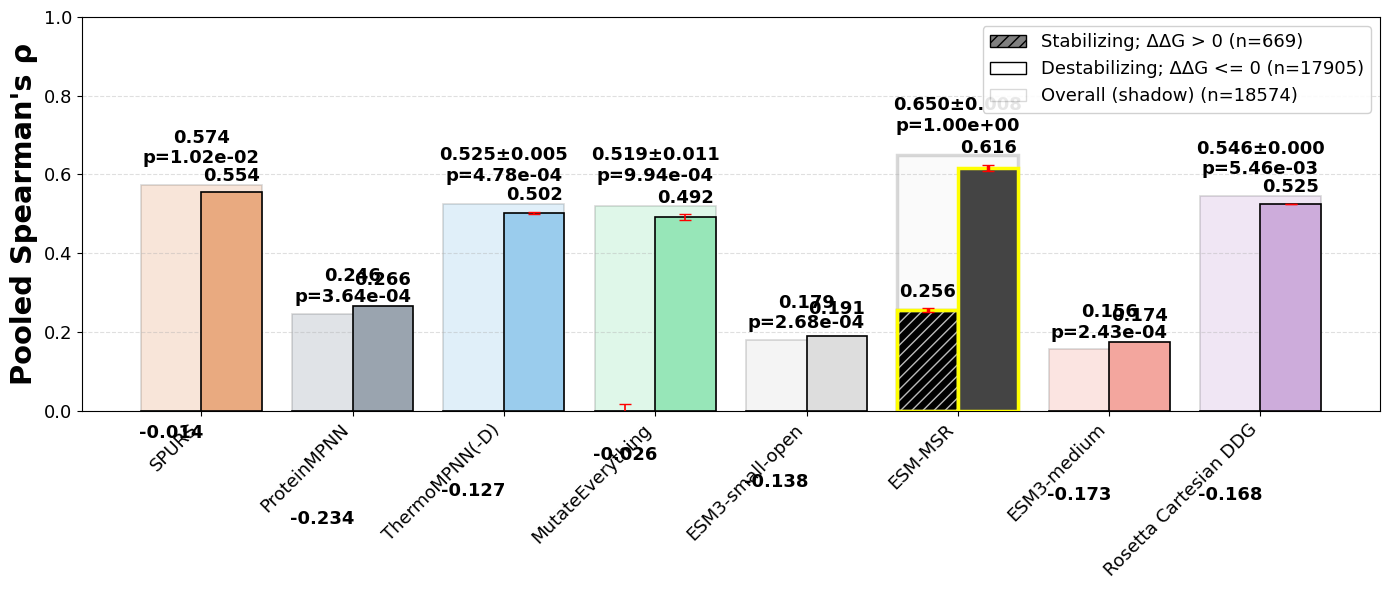

In [38]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_combined_doubles.loc[('mega_splits-D-test', 'ungrouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], title=None, y_label='Pooled Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, epistasis=False, fontsize_multiplier=1.3, is_grouped=False)

In [39]:
import importlib
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import compute_dddg

df_scores_dddG = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))
df_dddG = df_epistatic.copy(deep=True)
df_dddG = compute_dddg(df_dddG)
df_dddG

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM3-medium_dddG,ESM3-large_dddG,Rosetta Cartesian DDG_1_dddG,Rosetta Cartesian DDG_2_dddG,Rosetta Cartesian DDG_3_dddG,ESM-MSR_1_dddG,ESM-MSR_2_dddG,ESM-MSR_3_dddG,ESM3-small-open_dddG,ddG_dddG
uid,,,,,,,,,,,,,,,,,,,,,
1GYZ_A11C,0.336614,0.336614,0.321807,0.321807,0.359088,0.359088,0.336614,0.321807,0.359088,-0.173241,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1GYZ_A11D,-0.741629,-0.741629,-0.599676,-0.599676,-0.634145,-0.634145,-0.741629,-0.599676,-0.634145,-0.129564,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1GYZ_A11E,-0.188751,-0.188751,-0.195979,-0.195979,-0.251429,-0.251429,-0.188751,-0.195979,-0.251429,-0.109732,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1GYZ_A11F,0.018273,0.018273,-0.013003,-0.013003,-0.097384,-0.097384,0.018273,-0.013003,-0.097384,-0.222140,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
1GYZ_A11G,-0.513065,-0.513065,-0.472129,-0.472129,-0.625620,-0.625620,-0.513065,-0.472129,-0.625620,-0.107041,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HHH_rd1_0244_S17Y:E20S,-1.587296,-1.913250,-1.613422,-1.869113,-1.585544,-1.601184,-1.587296,-1.613422,-1.585544,NaN,...,4.556641,7.150391,-2.096939,-2.342517,-2.012925,0.218486,0.148212,0.176427,0.103415,-0.418039
HHH_rd1_0244_S17Y:E20T,-1.413257,-1.658027,-1.589893,-1.543731,-1.426943,-1.517203,-1.413257,-1.589893,-1.426943,NaN,...,3.943359,6.050781,-2.758503,-2.670748,-2.300340,0.178734,0.126714,0.145070,-0.065949,0.065437
HHH_rd1_0244_S17Y:E20V,-1.501781,-1.521556,-1.537591,-1.638658,-1.625146,-1.441694,-1.501781,-1.537591,-1.625146,NaN,...,3.265625,4.629395,-1.989116,-3.420408,-3.362585,0.245151,0.180786,0.215147,-0.154138,0.450972


In [40]:
df_scores_dddG = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_1', 'mega_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_2', 'mega_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM-MSR_3', 'mega_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Negative_additive', 'mega_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG['Negative_additive'] *= -1

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'SPURS', 'mega_splits-D-test', pred_col='SPURS_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ThermoMPNN(-D)_1', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ThermoMPNN(-D)_2', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ThermoMPNN(-D)_3', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'MutateEverything_1', 'mega_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'MutateEverything_2', 'mega_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'MutateEverything_3', 'mega_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-small-open', 'mega_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-small', 'mega_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-medium', 'mega_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ESM3-large', 'mega_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Rosetta Cartesian DDG_1', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Rosetta Cartesian DDG_2', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'Rosetta Cartesian DDG_3', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG = assess_grouped_spearman(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG, 'ProteinMPNN', 'mega_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG



df_dddG_pos = df_dddG.loc[df_dddG['ddG_dddG']>=0]
df_scores_dddG_pos = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_1', 'mega_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_2', 'mega_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM-MSR_3', 'mega_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Negative_additive', 'mega_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_pos['Negative_additive'] *= -1

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'SPURS', 'mega_splits-D-test', pred_col='SPURS_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ThermoMPNN(-D)_1', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ThermoMPNN(-D)_2', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ThermoMPNN(-D)_3', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'MutateEverything_1', 'mega_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'MutateEverything_2', 'mega_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'MutateEverything_3', 'mega_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-small-open', 'mega_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-small', 'mega_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-medium', 'mega_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ESM3-large', 'mega_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Rosetta Cartesian DDG_1', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Rosetta Cartesian DDG_2', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'Rosetta Cartesian DDG_3', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_pos = assess_grouped_spearman(df_dddG_pos.loc[df_dddG_pos['mut_type'].str.contains(':')], df_scores_dddG_pos, 'ProteinMPNN', 'mega_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')



df_dddG_neg = df_dddG.loc[df_dddG['ddG_dddG']<0]
df_scores_dddG_neg = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_1', 'mega_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_2', 'mega_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM-MSR_3', 'mega_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Negative_additive', 'mega_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_neg['Negative_additive'] *= -1

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'SPURS', 'mega_splits-D-test', pred_col='SPURS_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ThermoMPNN(-D)_1', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ThermoMPNN(-D)_2', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ThermoMPNN(-D)_3', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'MutateEverything_1', 'mega_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'MutateEverything_2', 'mega_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'MutateEverything_3', 'mega_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-small-open', 'mega_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-small', 'mega_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-medium', 'mega_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ESM3-large', 'mega_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Rosetta Cartesian DDG_1', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Rosetta Cartesian DDG_2', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'Rosetta Cartesian DDG_3', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_neg = assess_grouped_spearman(df_dddG_neg.loc[df_dddG_neg['mut_type'].str.contains(':')], df_scores_dddG_neg, 'ProteinMPNN', 'mega_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG_combined = df_scores_dddG.join(df_scores_dddG_pos, rsuffix='_pos').join(df_scores_dddG_neg, rsuffix='_neg')

df_scores_dddG_combined[[c for c in df_scores_dddG_combined.columns if 'ESM-MSR' in c]].columns



Index(['ESM-MSR_1', 'ESM-MSR_1_n', 'ESM-MSR_1_groups', 'ESM-MSR_2',
       'ESM-MSR_2_n', 'ESM-MSR_2_groups', 'ESM-MSR_3', 'ESM-MSR_3_n',
       'ESM-MSR_3_groups', 'ESM-MSR_1_pos', 'ESM-MSR_1_n_pos',
       'ESM-MSR_1_groups_pos', 'ESM-MSR_2_pos', 'ESM-MSR_2_n_pos',
       'ESM-MSR_2_groups_pos', 'ESM-MSR_3_pos', 'ESM-MSR_3_n_pos',
       'ESM-MSR_3_groups_pos', 'ESM-MSR_1_neg', 'ESM-MSR_1_n_neg',
       'ESM-MSR_1_groups_neg', 'ESM-MSR_2_neg', 'ESM-MSR_2_n_neg',
       'ESM-MSR_2_groups_neg', 'ESM-MSR_3_neg', 'ESM-MSR_3_n_neg',
       'ESM-MSR_3_groups_neg'],
      dtype='object')

(<Figure size 1600x800 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

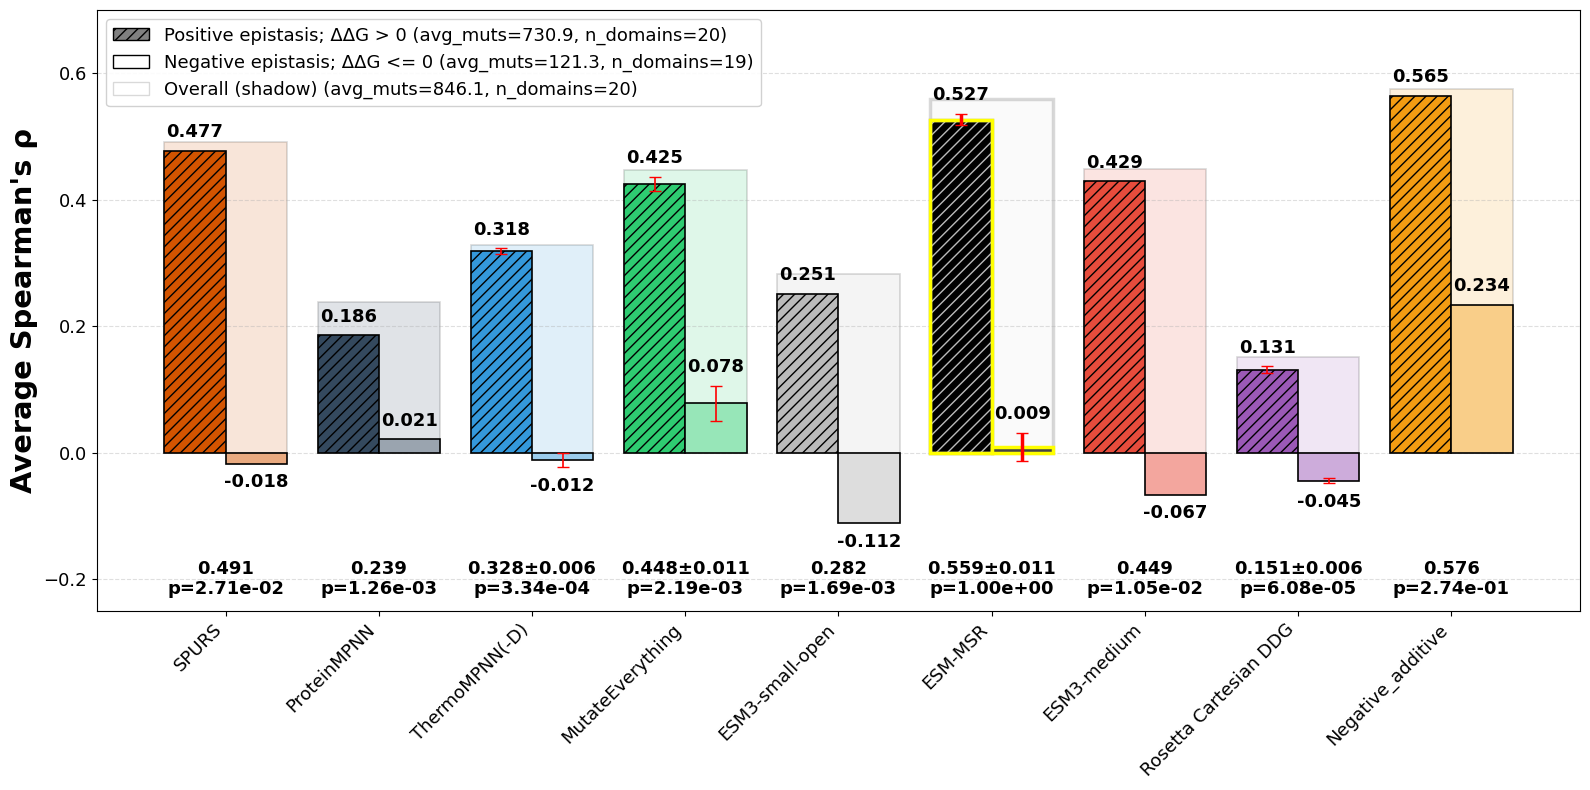

In [41]:
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_dddG_combined.loc[('mega_splits-D-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG', 'Negative_additive'], #'ESM3-small',  'ESM3-large',  'ESM3-small-open_masked','ESM-MSR_masked', 'ESM-MSR_single', 'ESM-MSR_reg',
                                                 title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, figsize=(16,8), ylim=(-0.25, 0.7), legend_loc='upper left',  p_value_y_coord=-0.2, fontsize_multiplier=1.3)


(<Figure size 1600x1000 with 1 Axes>, <Axes: ylabel="Pooled Spearman's ρ">)

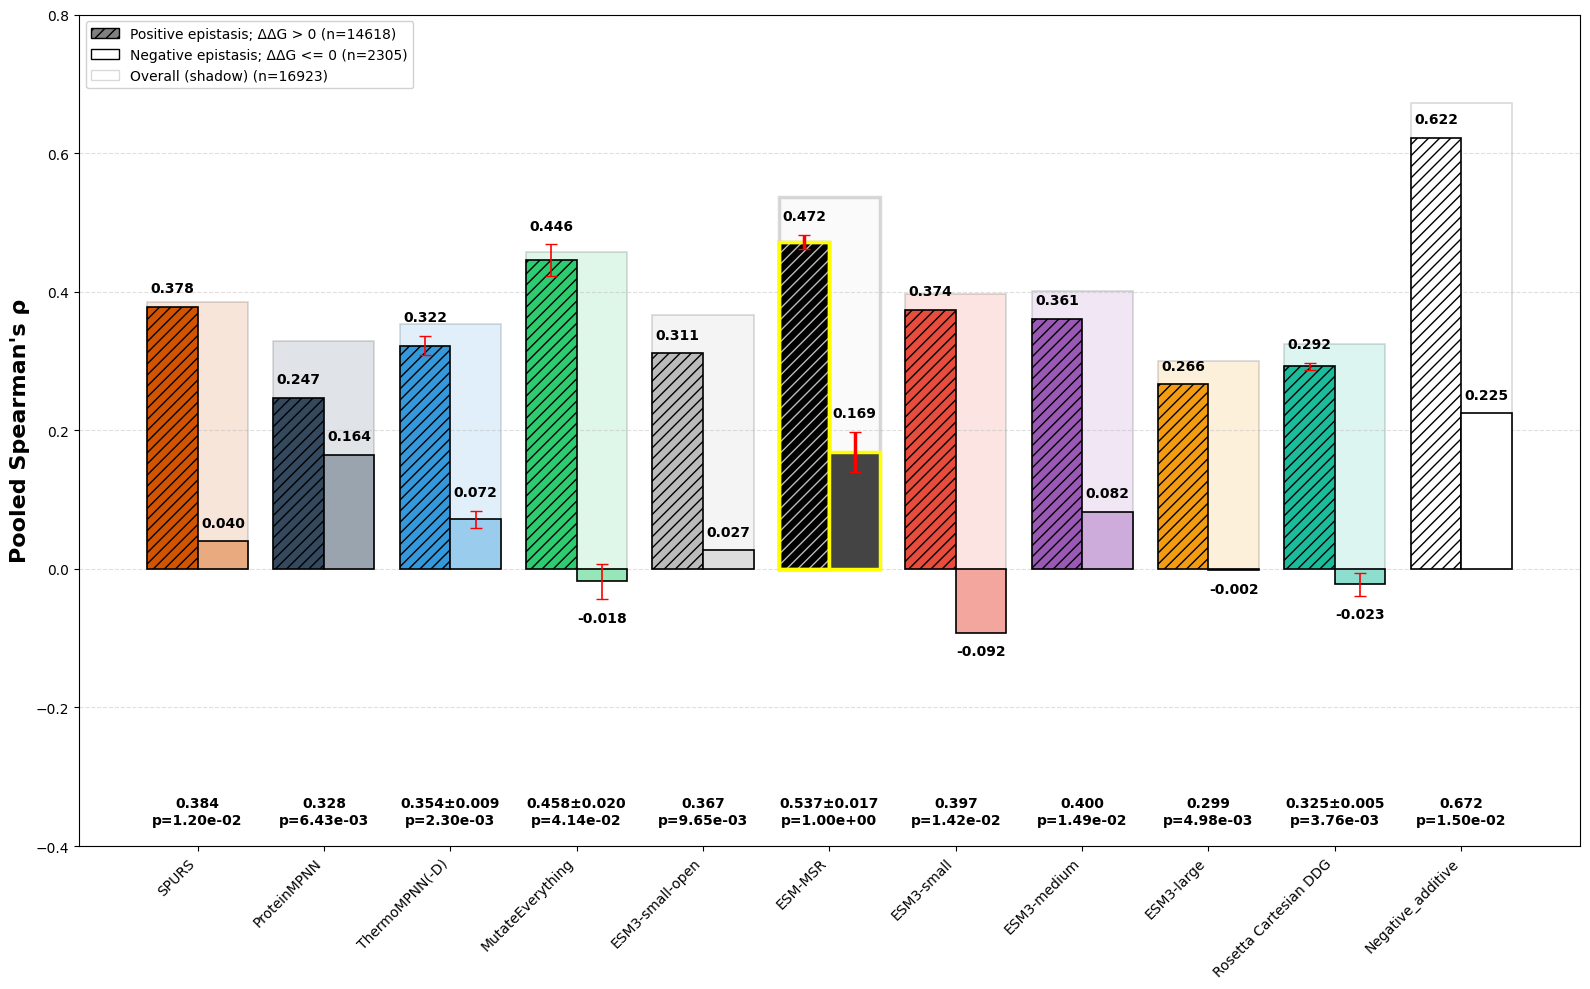

In [42]:
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_dddG_combined.loc[('mega_splits-D-test', 'ungrouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-small', 'ESM3-medium', 'ESM3-large', 'Rosetta Cartesian DDG', 'Negative_additive'],
 title=None, y_label='Pooled Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, figsize=(16,10), ylim=(-0.4, 0.8), p_value_y_coord=-0.35, legend_loc='upper left', fontsize_multiplier=1., is_grouped=False)


In [43]:
import importlib
importlib.reload(analysis_utils_msr)
from analysis_utils_msr import assess_classification_metric

df_scores_dddG_cls = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped']]))
assess_mcc = partial(assess_classification_metric, metric_name='mcc', flip_labels=True)

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_1', 'mega_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_2', 'mega_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM-MSR_3', 'mega_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'SPURS', 'mega_splits-D-test', pred_col='SPURS_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_1', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_2', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ThermoMPNN(-D)_3', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_1', 'mega_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_2', 'mega_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'MutateEverything_3', 'mega_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small-open', 'mega_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-small', 'mega_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-medium', 'mega_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ESM3-large', 'mega_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_1', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_2', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')].fillna(0), df_scores_dddG_cls, 'Rosetta Cartesian DDG_3', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_cls = assess_mcc(df_dddG.loc[df_dddG['mut_type'].str.contains(':')], df_scores_dddG_cls, 'ProteinMPNN', 'mega_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG_cls


,,ESM-MSR_1,ESM-MSR_1_n,ESM-MSR_2,ESM-MSR_2_n,ESM-MSR_3,ESM-MSR_3_n,SPURS,SPURS_n,ThermoMPNN(-D)_1,ThermoMPNN(-D)_1_n,...,ESM3-large,ESM3-large_n,Rosetta Cartesian DDG_1,Rosetta Cartesian DDG_1_n,Rosetta Cartesian DDG_2,Rosetta Cartesian DDG_2_n,Rosetta Cartesian DDG_3,Rosetta Cartesian DDG_3_n,ProteinMPNN,ProteinMPNN_n
mega_splits-D-test,ungrouped,0.110636,18574.0,0.157341,18574.0,0.15428,18574.0,0.018921,18574.0,0.061807,18574.0,...,0.019254,18574.0,0.014867,18574.0,0.01477,18574.0,0.026942,18574.0,0.140185,18574.0


(<Figure size 1600x600 with 1 Axes>, <Axes: ylabel='MCC'>)

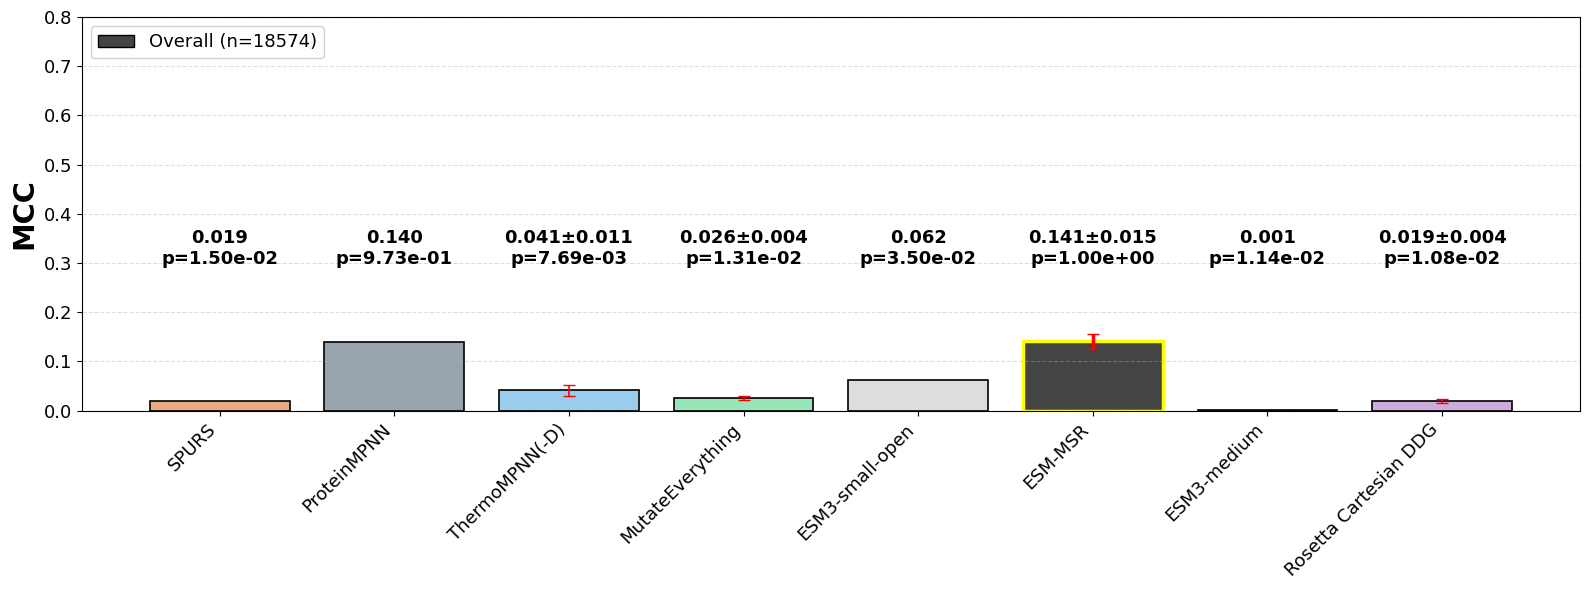

In [44]:
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_triple_metric_chart_with_pvals(series_bar1=None,
                                      series_bar2=None, 
                                      series_overall=df_scores_dddG_cls.loc[('mega_splits-D-test', 'ungrouped')], 
                                      model_groups=['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], #'ESM3-small', 'ESM3-large', 'ESM-MSR_masked', 'ESM-MSR_single', 'ESM-MSR_reg',
                                      title=None, y_label='MCC', highlighted_model='ESM-MSR', enforce_global_n=False, ylim=(0,0.8), figsize=(16,6), p_value_y_coord=0.33, label_min_sep=0.02, fontsize_multiplier=1.3, legend_loc='upper left', is_grouped=False, highlight_gray='#444444')

In [45]:
df_dddG_valid = df_dddG.loc[df_dddG['ddG_additive']>=-2]
df_scores_dddG_valid = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_1', 'mega_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_2', 'mega_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_3', 'mega_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_med_1', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_med_2', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_med_3', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_low_1', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_low_2', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_alpha_low_3', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_single_1', 'mega_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_single_2', 'mega_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_single_3', 'mega_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_reg_1', 'mega_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_reg_2', 'mega_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_reg_3', 'mega_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_masked_1', 'mega_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_masked_2', 'mega_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM-MSR_masked_3', 'mega_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Negative_additive', 'mega_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_valid['Negative_additive'] *= -1

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'SPURS_1', 'mega_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'SPURS_2', 'mega_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'SPURS_3', 'mega_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ThermoMPNN(-D)_1', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ThermoMPNN(-D)_2', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ThermoMPNN(-D)_3', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'MutateEverything_1', 'mega_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'MutateEverything_2', 'mega_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'MutateEverything_3', 'mega_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-small-open', 'mega_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-small-open_masked', 'mega_splits-D-test', pred_col='ESM3-small-open_masked_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-small', 'mega_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-medium', 'mega_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ESM3-large', 'mega_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Rosetta Cartesian DDG_1', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Rosetta Cartesian DDG_2', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'Rosetta Cartesian DDG_3', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_valid = assess_grouped_spearman(df_dddG_valid.loc[df_dddG_valid['mut_type'].str.contains(':')], df_scores_dddG_valid, 'ProteinMPNN', 'mega_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')



df_dddG_dubious = df_dddG.loc[df_dddG['ddG_additive']<-2]
df_scores_dddG_dubious = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-D-test'], ['ungrouped', 'grouped']]))

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_1', 'mega_splits-D-test', pred_col='ESM-MSR_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_2', 'mega_splits-D-test', pred_col='ESM-MSR_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_3', 'mega_splits-D-test', pred_col='ESM-MSR_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_med_1', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_med_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_med_2', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_med_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_med_3', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_med_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_low_1', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_low_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_low_2', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_low_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_alpha_low_3', 'mega_splits-D-test', pred_col='ESM-MSR_alpha_low_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_single_1', 'mega_splits-D-test', pred_col='ESM-MSR_single_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_single_2', 'mega_splits-D-test', pred_col='ESM-MSR_single_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_single_3', 'mega_splits-D-test', pred_col='ESM-MSR_single_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_reg_1', 'mega_splits-D-test', pred_col='ESM-MSR_reg_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_reg_2', 'mega_splits-D-test', pred_col='ESM-MSR_reg_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_reg_3', 'mega_splits-D-test', pred_col='ESM-MSR_reg_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_masked_1', 'mega_splits-D-test', pred_col='ESM-MSR_masked_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_masked_2', 'mega_splits-D-test', pred_col='ESM-MSR_masked_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM-MSR_masked_3', 'mega_splits-D-test', pred_col='ESM-MSR_masked_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Negative_additive', 'mega_splits-D-test', pred_col='ddG_additive', label='ddG_dddG')
df_scores_dddG_dubious['Negative_additive'] *= -1

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'SPURS_1', 'mega_splits-D-test', pred_col='SPURS_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'SPURS_2', 'mega_splits-D-test', pred_col='SPURS_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'SPURS_3', 'mega_splits-D-test', pred_col='SPURS_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ThermoMPNN(-D)_1', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ThermoMPNN(-D)_2', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ThermoMPNN(-D)_3', 'mega_splits-D-test', pred_col='ThermoMPNN(-D)_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'MutateEverything_1', 'mega_splits-D-test', pred_col='MutateEverything_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'MutateEverything_2', 'mega_splits-D-test', pred_col='MutateEverything_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'MutateEverything_3', 'mega_splits-D-test', pred_col='MutateEverything_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-small-open', 'mega_splits-D-test', pred_col='ESM3-small-open_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-small-open_masked', 'mega_splits-D-test', pred_col='ESM3-small-open_masked_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-small', 'mega_splits-D-test', pred_col='ESM3-small_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-medium', 'mega_splits-D-test', pred_col='ESM3-medium_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ESM3-large', 'mega_splits-D-test', pred_col='ESM3-large_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Rosetta Cartesian DDG_1', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_1_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Rosetta Cartesian DDG_2', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_2_dddG', label='ddG_dddG')
df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'Rosetta Cartesian DDG_3', 'mega_splits-D-test', pred_col='Rosetta Cartesian DDG_3_dddG', label='ddG_dddG')

df_scores_dddG_dubious = assess_grouped_spearman(df_dddG_dubious.loc[df_dddG_dubious['mut_type'].str.contains(':')], df_scores_dddG_dubious, 'ProteinMPNN', 'mega_splits-D-test', pred_col='ProteinMPNN_dddG', label='ddG_dddG')

df_scores_dddG_combined_2 = df_scores_dddG.join(df_scores_dddG_valid, rsuffix='_pos').join(df_scores_dddG_dubious, rsuffix='_neg')

df_scores_dddG_combined_2[[c for c in df_scores_dddG_combined_2.columns if 'ESM-MSR' in c]].columns



AssertionError: Column 'ESM-MSR_alpha_med_1_dddG' missing from df_preds

(<Figure size 1600x1000 with 1 Axes>, <Axes: ylabel="Average Spearman's ρ">)

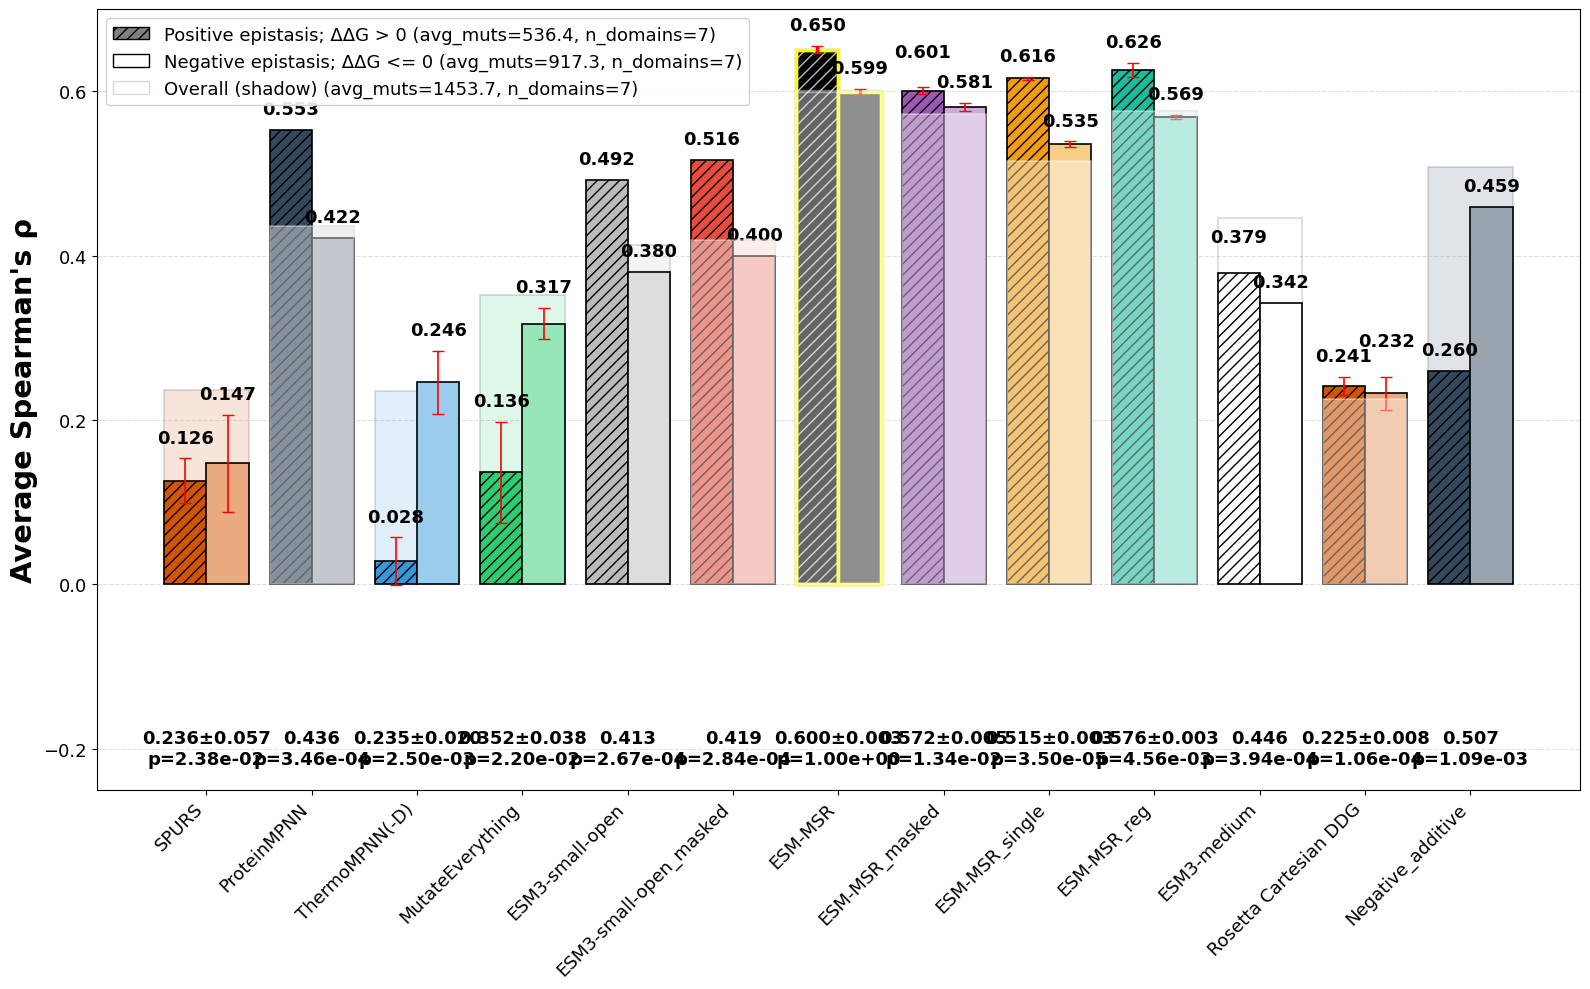

In [ ]:
import importlib
importlib.reload(analysis_utils_msr)
analysis_utils_msr.create_pos_neg_overall_chart(df_scores_dddG_combined_2.loc[('mega_splits-D-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM3-small-open_masked', 'ESM-MSR', 'ESM-MSR_masked', 'ESM-MSR_single', 'ESM-MSR_reg', 'ESM3-medium', 'Rosetta Cartesian DDG', 'Negative_additive'], #'ESM3-small',  'ESM3-large',
                                                 title=None, y_label='Average Spearman\'s ρ', highlighted_model='ESM-MSR', enforce_global_n=False, figsize=(16,10), ylim=(-0.25, 0.7), legend_loc='upper left',  p_value_y_coord=-0.2, fontsize_multiplier=1.3)


0.8524629363940698
0.17975426914900697
0.9219224231534958


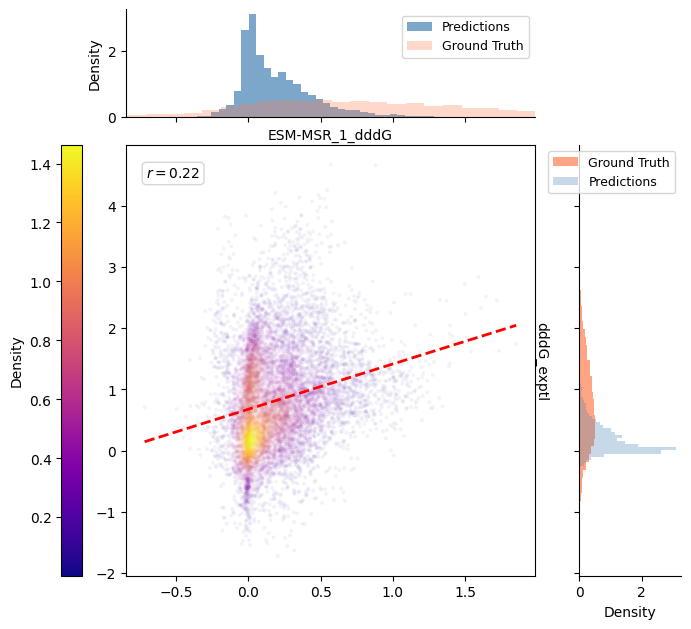

In [ ]:
import importlib
importlib.reload(analysis_utils_msr)
from sklearn.metrics import f1_score, matthews_corrcoef, average_precision_score

from analysis_utils_msr import density_scatter

df_dddG['dddG_exptl'] = df_dddG['ddG_dddG']
df_dddG_clean = df_dddG[['dddG_exptl', 'ESM-MSR_1_dddG']].dropna()

density_scatter(df_dddG_clean['ESM-MSR_1_dddG'], df_dddG_clean['dddG_exptl'], point_alpha=0.05, s=8, cmap="plasma", stats=True)

f1 = f1_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ESM-MSR_1_dddG']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ESM-MSR_1_dddG']]>0)
auprc = average_precision_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ESM-MSR_1_dddG']])

print(f1)
print(mcc)
print(auprc)

<Axes: xlabel='ESM-MSR_1', ylabel='ddG'>

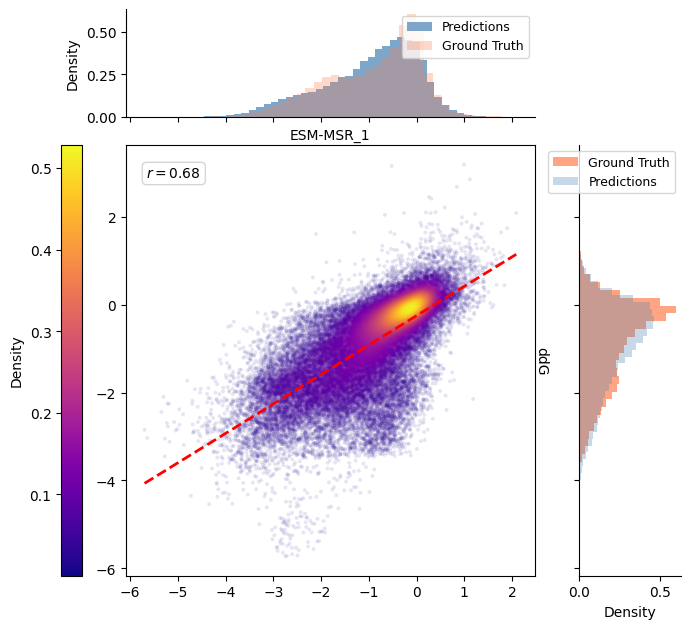

In [ ]:
density_scatter(df_dddG['ESM-MSR_1'], df_dddG['ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True)

<Axes: xlabel='ESM-MSR_1', ylabel='ddG'>

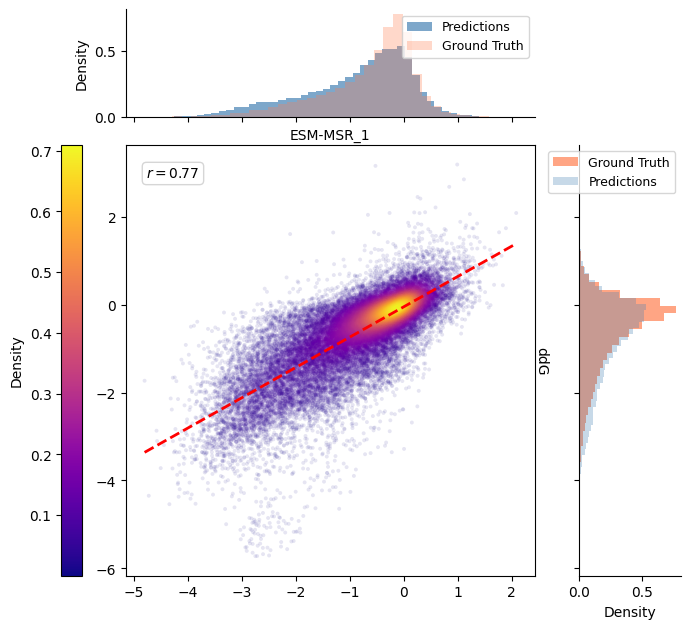

In [ ]:
density_scatter(df_dddG.loc[~df_dddG.index.str.contains(':'), 'ESM-MSR_1'], df_dddG.loc[~df_dddG.index.str.contains(':'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True)

<Axes: xlabel='ESM-MSR_1', ylabel='ddG'>

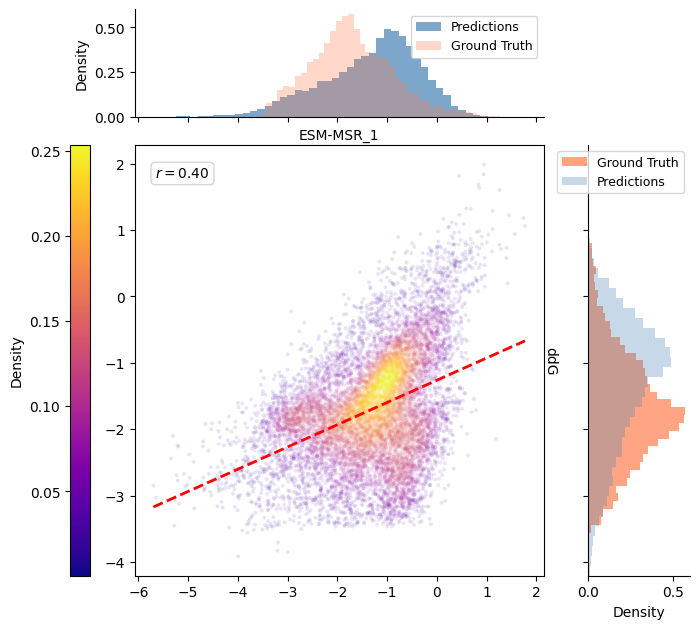

In [ ]:
density_scatter(df_dddG.loc[df_dddG.index.str.contains(':'), 'ESM-MSR_1'], df_dddG.loc[df_dddG.index.str.contains(':'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True)

In [ ]:
df_dddG.loc[df_dddG.index.str.contains(':'), 'code'].unique()

array(['1UFM', '2RU9', '3DKM', '6M3N', 'HHH_rd1_0244', 'HHH_rd1_0493',
       'HHH_rd1_0949'], dtype=object)

<Axes: xlabel='ESM-MSR_1', ylabel='ddG'>

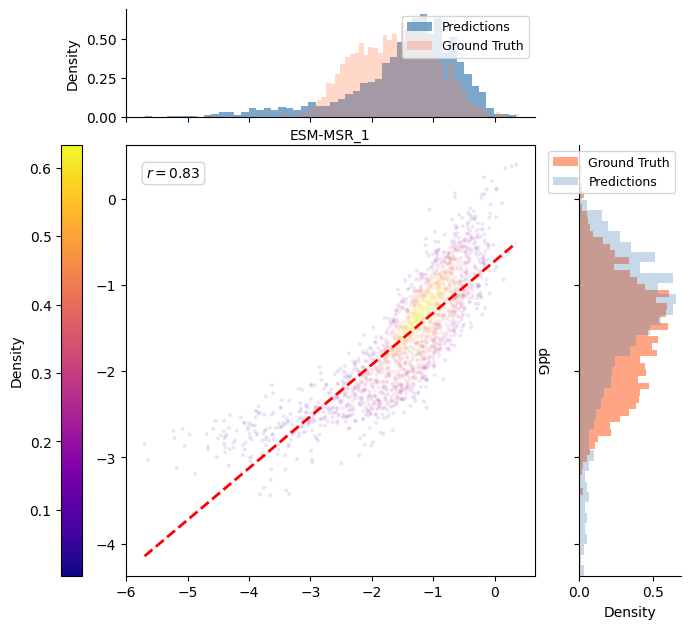

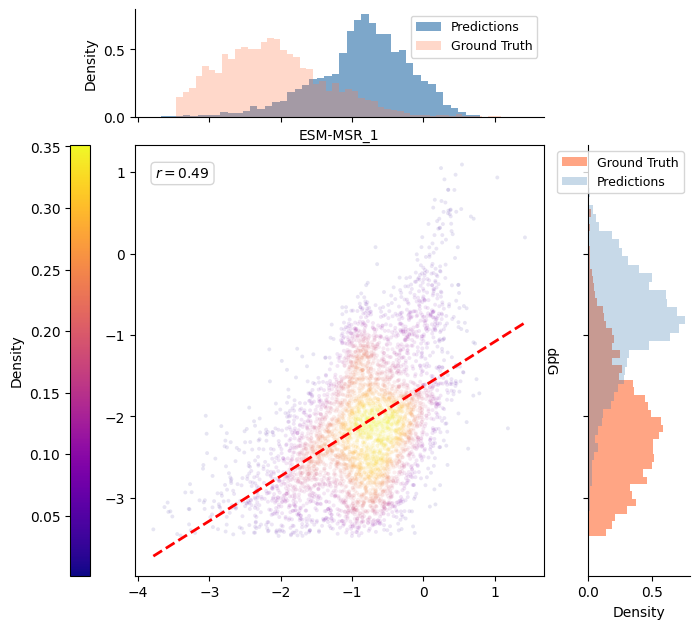

In [ ]:
density_scatter(df_dddG.loc[df_dddG.index.str.contains(':') & df_dddG.index.str.contains('1UFM'), 'ESM-MSR_1'], df_dddG.loc[df_dddG.index.str.contains(':') & df_dddG.index.str.contains('1UFM'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True)
density_scatter(df_dddG.loc[df_dddG.index.str.contains(':') & df_dddG.index.str.contains('3DKM'), 'ESM-MSR_1'], df_dddG.loc[df_dddG.index.str.contains(':') & df_dddG.index.str.contains('3DKM'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True)

<Axes: xlabel='ThermoMPNN(-D)_1', ylabel='ddG'>

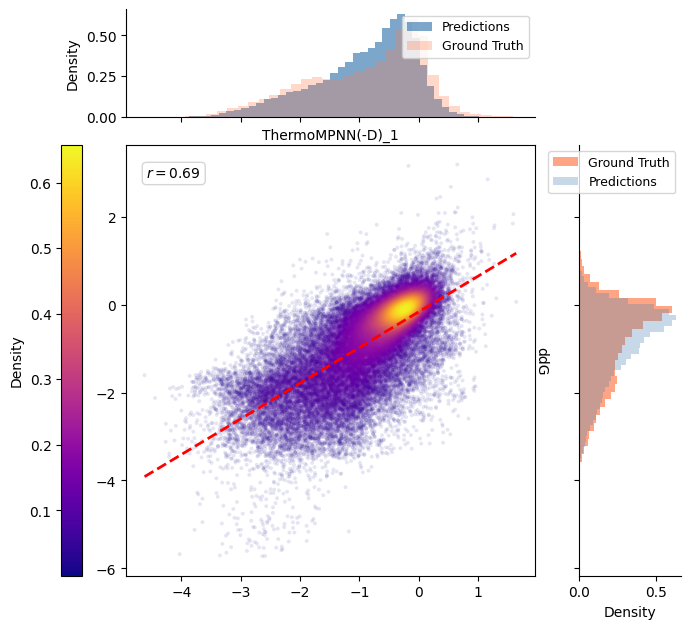

In [ ]:
density_scatter(df_dddG['ThermoMPNN(-D)_1'], df_dddG['ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True) #.dropna

<Axes: xlabel='ThermoMPNN(-D)_1', ylabel='ddG'>

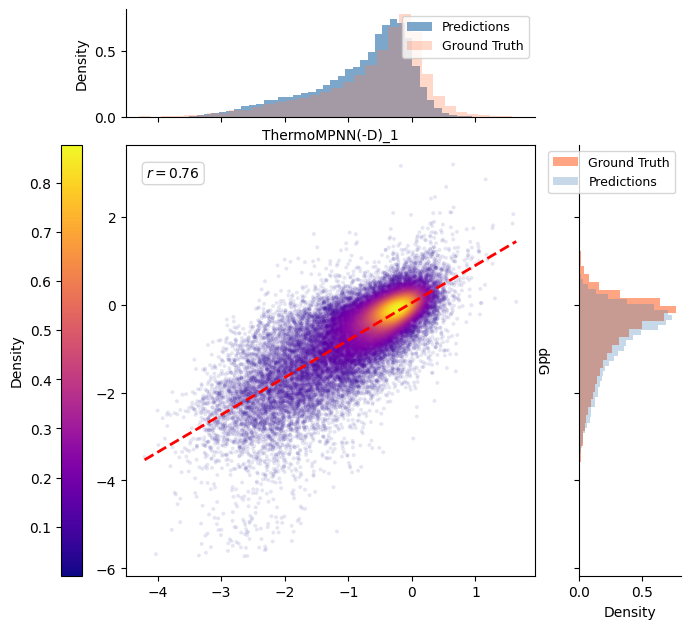

In [ ]:
density_scatter(df_dddG.loc[~df_dddG.index.str.contains(':'), 'ThermoMPNN(-D)_1'], df_dddG.loc[~df_dddG.index.str.contains(':'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True) #.dropna

<Axes: xlabel='ThermoMPNN(-D)_1', ylabel='ddG'>

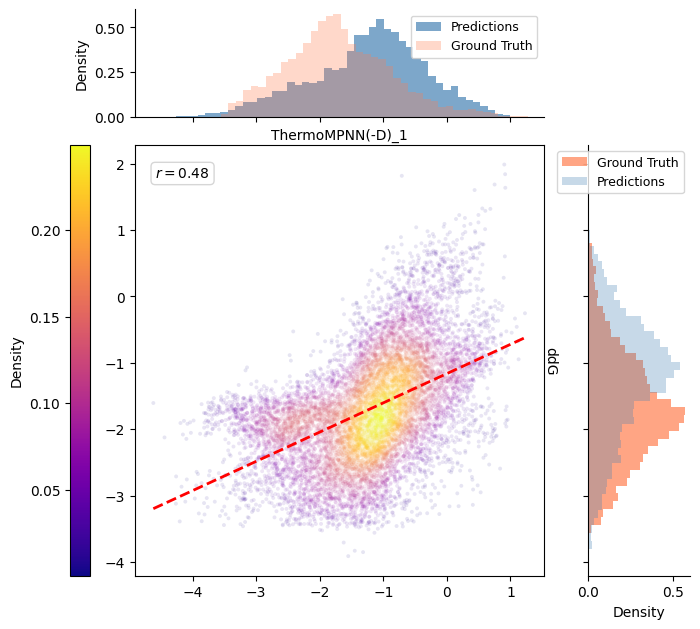

In [ ]:
density_scatter(df_dddG.loc[df_dddG.index.str.contains(':'), 'ThermoMPNN(-D)_1'], df_dddG.loc[df_dddG.index.str.contains(':'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True) #.dropna

<Axes: xlabel='MutateEverything_1', ylabel='ddG'>

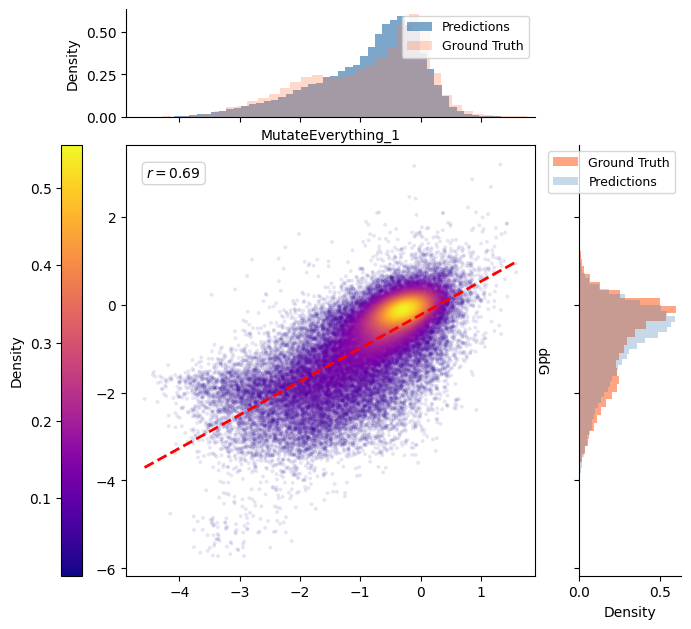

In [ ]:
density_scatter(df_dddG['MutateEverything_1'], df_dddG['ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True)

<Axes: xlabel='MutateEverything_1', ylabel='ddG'>

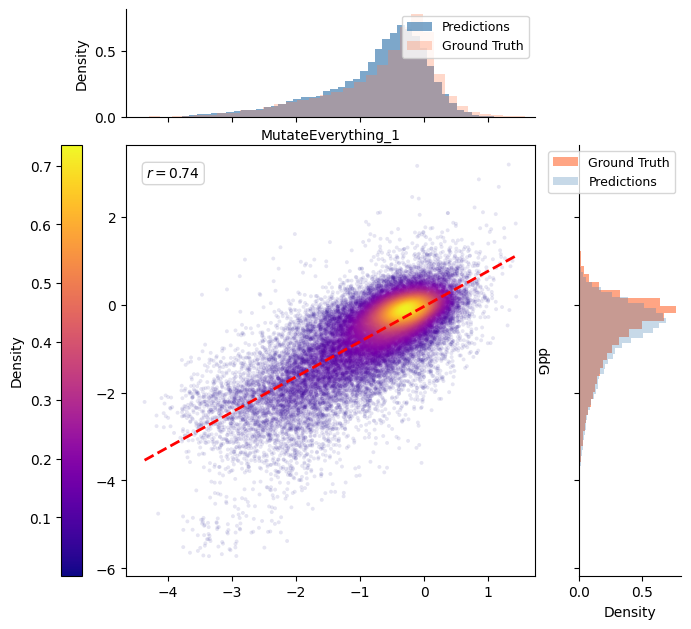

In [ ]:
density_scatter(df_dddG.loc[~df_dddG.index.str.contains(':'), 'MutateEverything_1'], df_dddG.loc[~df_dddG.index.str.contains(':'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True) #.dropna

<Axes: xlabel='MutateEverything_1', ylabel='ddG'>

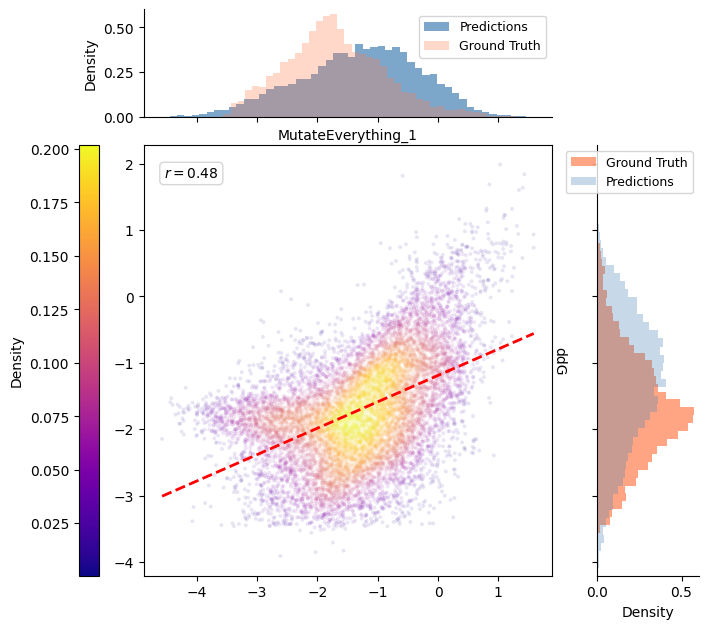

In [ ]:
density_scatter(df_dddG.loc[df_dddG.index.str.contains(':'), 'MutateEverything_1'], df_dddG.loc[df_dddG.index.str.contains(':'), 'ddG'], point_alpha=0.1, s=8, cmap="plasma", stats=True) #.dropna

<Axes: xlabel='SPURS_1', ylabel='ddG'>

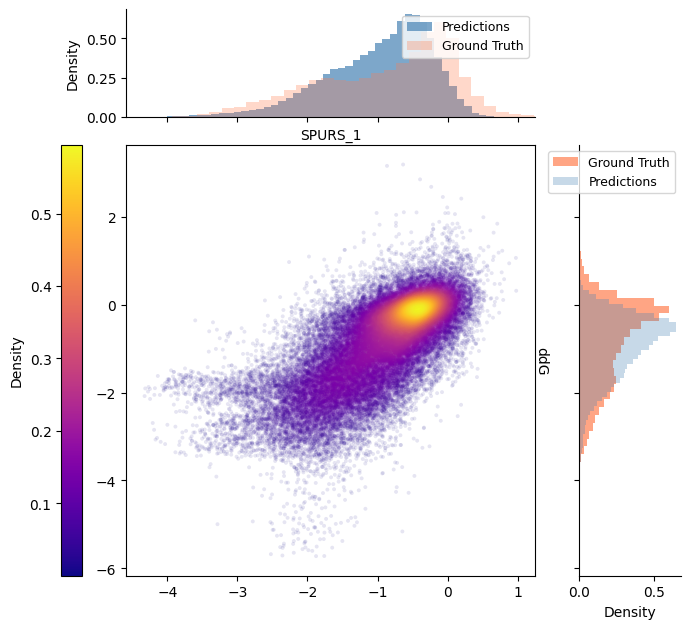

In [ ]:
density_scatter(df_dddG['SPURS_1'], df_dddG['ddG'], point_alpha=0.1, s=8, cmap="plasma")

<Axes: xlabel='ESM3-small-open', ylabel='ddG'>

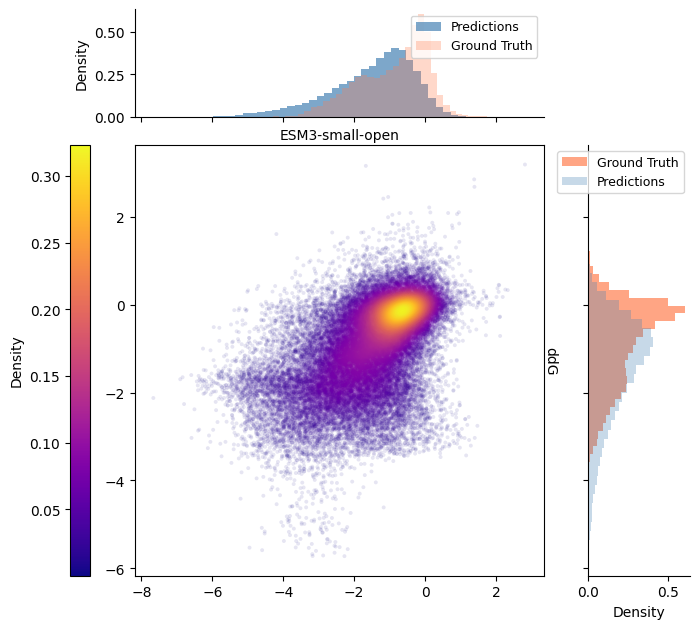

In [ ]:
density_scatter(df_dddG['ESM3-small-open'], df_dddG['ddG'], point_alpha=0.1, s=8, cmap="plasma")

,ddG_additive,ddG,ddG_dddG
uid,,,
1UFM_E14A:E53A,-1.742914,-1.746995,-0.004082
1UFM_E14A:E53D,-1.683631,-1.524802,0.158829
1UFM_E14A:E53F,-3.021748,-2.029420,0.992328
1UFM_E14A:E53G,-2.268398,-1.917165,0.351233
1UFM_E14A:E53H,-2.450991,-2.040422,0.410570
...,...,...,...
HHH_rd1_0949_R10Y:E36S,-1.240620,-0.293973,0.946647
HHH_rd1_0949_R10Y:E36T,-0.983655,-0.381462,0.602194
HHH_rd1_0949_R10Y:E36V,-0.178556,0.365883,0.544439


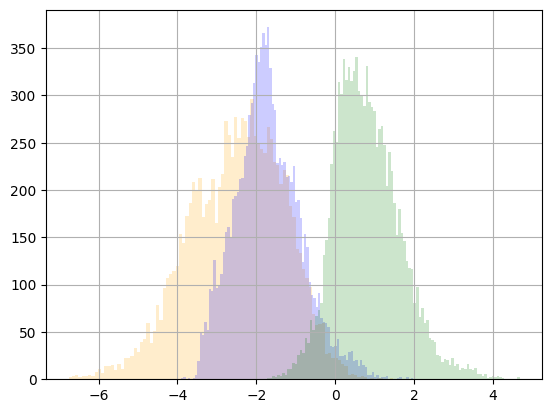

In [ ]:
df_dddG.loc[df.index.str.contains(':')]['ddG_additive'].hist(bins=100, alpha=0.2, color='orange')
df_dddG.loc[df.index.str.contains(':')]['ddG'].hist(bins=100, alpha=0.2, color='blue')

df_dddG['ddG_dddG'].hist(bins=100, alpha=0.2, color='green')
df_dddG[['ddG_additive', 'ddG', 'ddG_dddG']].dropna()

0.018727874842982755
-0.0015597437751152157
0.7573846264687856
              δΔΔG_exptl  ΔΔG_additive
δΔΔG_exptl      1.000000     -0.704691
ΔΔG_additive   -0.704691      1.000000


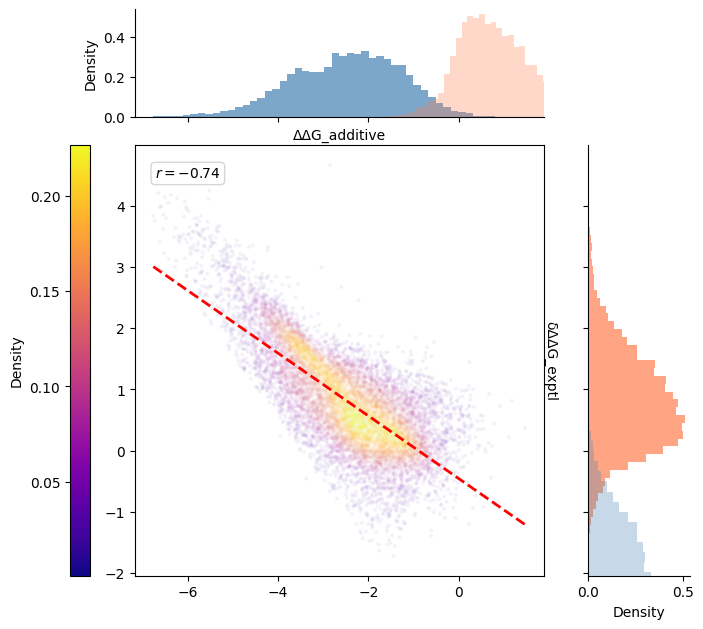

In [ ]:
from sklearn.metrics import f1_score, matthews_corrcoef, average_precision_score
import importlib
importlib.reload(analysis_utils_msr)

from analysis_utils_msr import density_scatter

df_dddG['δΔΔG_exptl'] = df_dddG['ddG_dddG']
df_dddG['ΔΔG_additive'] = df_dddG['ddG_additive']
df_dddG_clean = df_dddG[['ΔΔG_additive', 'δΔΔG_exptl']].dropna()

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['δΔΔG_exptl'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['δΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['δΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['δΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG[['δΔΔG_exptl', 'ΔΔG_additive']].corr('spearman'))

0.07423047005222802
0.06998138440473577
0.8877123717529737
            δΔΔG_exptl       ΔΔG
δΔΔG_exptl    1.000000 -0.075143
ΔΔG          -0.075143  1.000000


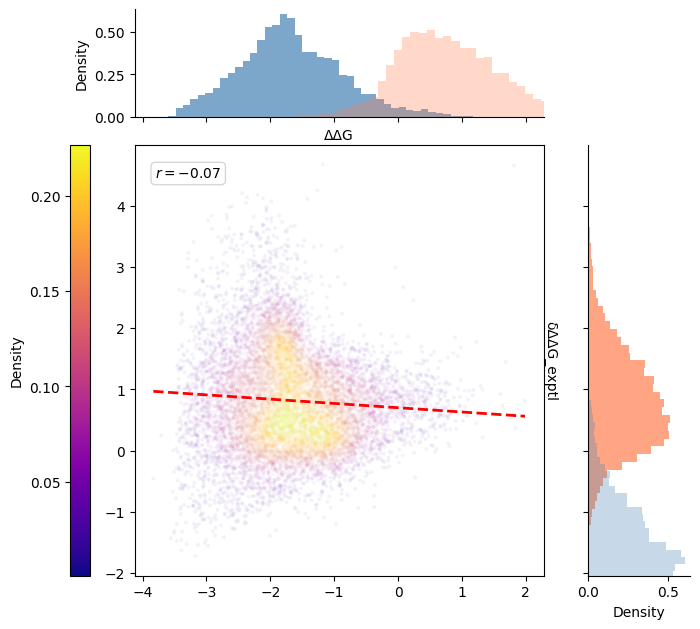

In [ ]:
from sklearn.metrics import f1_score, matthews_corrcoef, average_precision_score
import importlib
importlib.reload(analysis_utils_msr)

from analysis_utils_msr import density_scatter

df_dddG['δΔΔG_exptl'] = df_dddG['ddG_dddG']
df_dddG['ΔΔG'] = df_dddG['ddG']
df_dddG_clean = df_dddG[['ΔΔG', 'δΔΔG_exptl']].dropna()

density_scatter(df_dddG_clean['ΔΔG'], df_dddG_clean['δΔΔG_exptl'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['δΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['δΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG']]>0)
auprc = average_precision_score(df_dddG_clean[['δΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG[['δΔΔG_exptl', 'ΔΔG']].corr('spearman'))

0.39908256880733944
0.47209830552668425
0.6562703660711597
              ΔΔG_exptl  ΔΔG_additive
ΔΔG_exptl      1.000000      0.730326
ΔΔG_additive   0.730326      1.000000


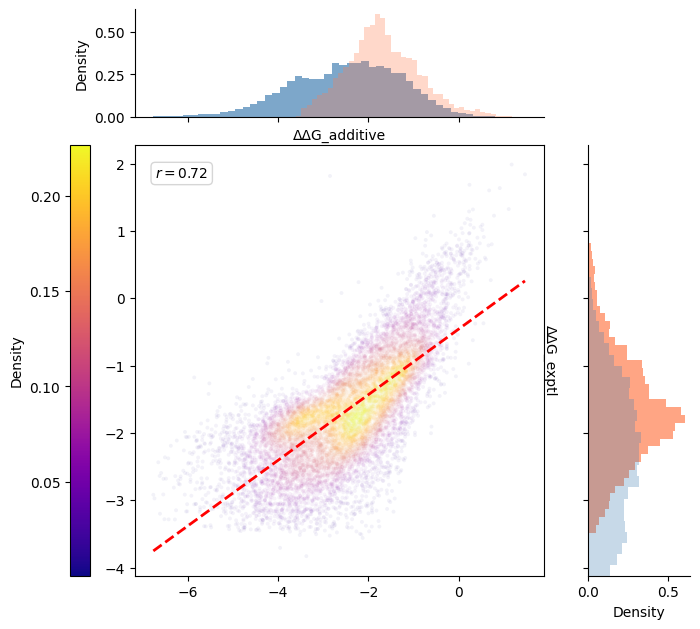

In [ ]:
from sklearn.metrics import f1_score, matthews_corrcoef, average_precision_score
import importlib
importlib.reload(analysis_utils_msr)

from analysis_utils_msr import density_scatter

df_dddG['ΔΔG_exptl'] = df_dddG['ddG']
df_dddG['ΔΔG_additive'] = df_dddG['ddG_additive']
df_dddG_clean = df_dddG[['ΔΔG_additive', 'ΔΔG_exptl']].dropna()

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['ΔΔG_exptl'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['ΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['ΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['ΔΔG_exptl']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG[['ΔΔG_exptl', 'ΔΔG_additive']].corr('spearman'))

0.016901408450704224
-0.01972986016261943
0.7551567588536185
              ESM-MSR δΔΔG  ΔΔG_additive
ESM-MSR δΔΔG      1.000000     -0.036235
ΔΔG_additive     -0.036235      1.000000


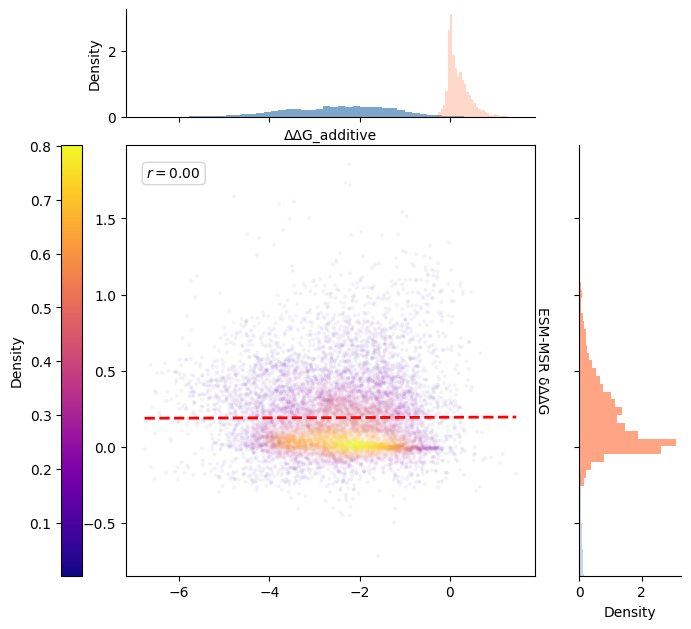

In [ ]:
df_dddG_clean = df_dddG[['ΔΔG_additive', 'ESM-MSR_1_dddG']].dropna()

df_dddG_clean.rename(columns={'ESM-MSR_1_dddG': 'ESM-MSR δΔΔG'}, inplace=True)

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['ESM-MSR δΔΔG'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['ESM-MSR δΔΔG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['ESM-MSR δΔΔG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['ESM-MSR δΔΔG']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG_clean[['ESM-MSR δΔΔG', 'ΔΔG_additive']].corr('spearman'))

0.002132954141485958
-0.051710498673037286
0.6373361095637224
                ESM-MSR_1_dddG  ddG_additive
ESM-MSR_1_dddG        1.000000     -0.280527
ddG_additive         -0.280527      1.000000


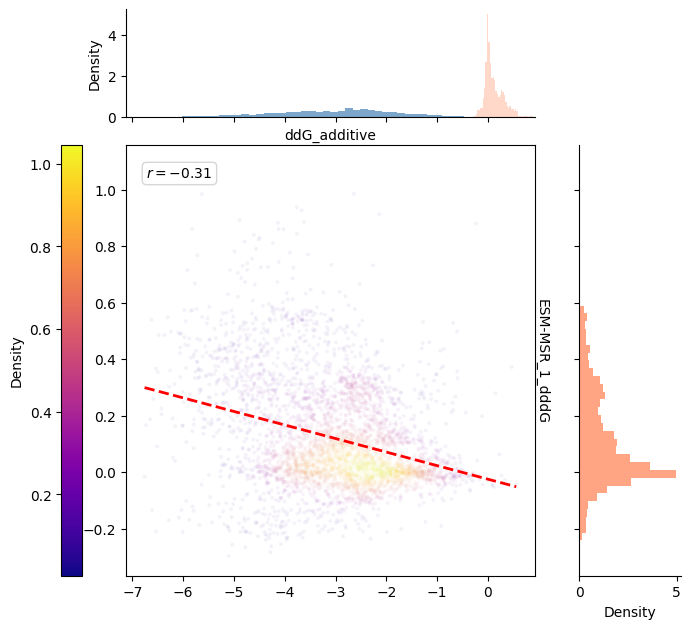

In [ ]:
df_dddG_clean = df_dddG.reset_index()[['uid', 'ddG_additive', 'ESM-MSR_1_dddG']].dropna()
df_dddG_clean = df_dddG_clean.loc[df_dddG_clean['uid'].str.contains('3DKM')]

density_scatter(df_dddG_clean['ddG_additive'], df_dddG_clean['ESM-MSR_1_dddG'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['ESM-MSR_1_dddG']]>0, df_dddG_clean[['ddG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['ESM-MSR_1_dddG']]>0, df_dddG_clean[['ddG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['ESM-MSR_1_dddG']]>0, df_dddG_clean[['ddG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG_clean[['ESM-MSR_1_dddG', 'ddG_additive']].corr('spearman'))

0.017187940264863342
-0.012519190022803686
0.697427688353049
                      ESM3-small-open_dddG  ΔΔG_additive
ESM3-small-open_dddG              1.000000     -0.023902
ΔΔG_additive                     -0.023902      1.000000


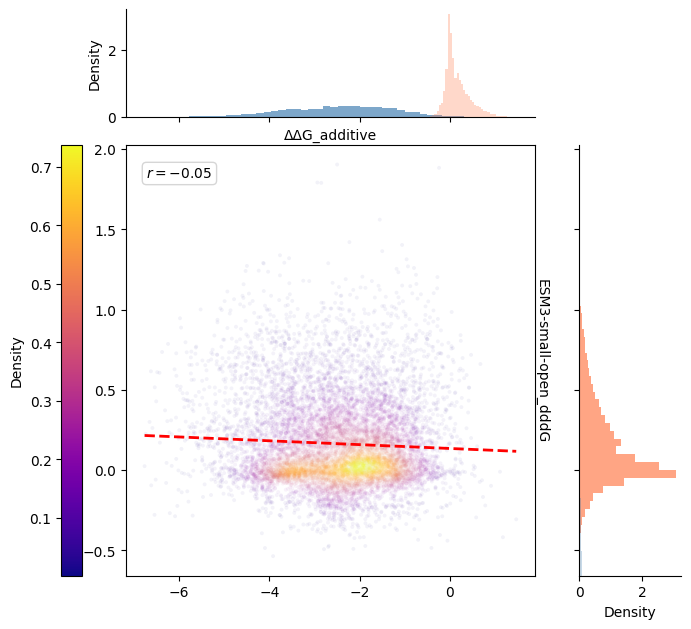

In [ ]:
df_dddG_clean = df_dddG[['ΔΔG_additive', 'ESM3-small-open_dddG']].dropna()

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['ESM3-small-open_dddG'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['ESM3-small-open_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['ESM3-small-open_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['ESM3-small-open_dddG']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG_clean[['ESM3-small-open_dddG', 'ΔΔG_additive']].corr('spearman'))

0.015663643858202802
-0.025411695643816436
0.644824269803287
                              Rosetta Cartesian DDG_1_dddG  ΔΔG_additive
Rosetta Cartesian DDG_1_dddG                      1.000000     -0.271463
ΔΔG_additive                                     -0.271463      1.000000


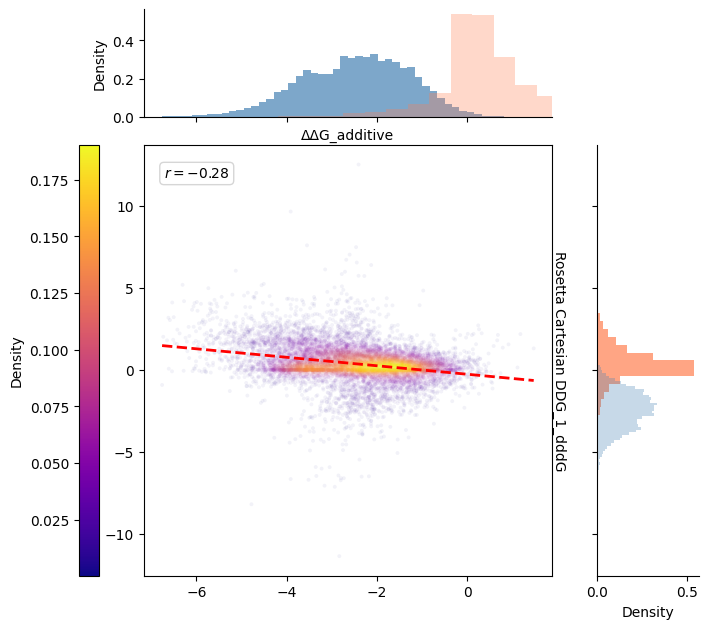

In [ ]:
df_dddG_clean = df_dddG[['ΔΔG_additive', 'Rosetta Cartesian DDG_1_dddG']].dropna()

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['Rosetta Cartesian DDG_1_dddG'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['Rosetta Cartesian DDG_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['Rosetta Cartesian DDG_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['Rosetta Cartesian DDG_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG_clean[['Rosetta Cartesian DDG_1_dddG', 'ΔΔG_additive']].corr('spearman'))

0.018845467169212458
-0.0013365264589851335
0.971759885036612
                        Mutate Everything δΔΔG  ΔΔG_additive
Mutate Everything δΔΔG                1.000000     -0.592346
ΔΔG_additive                         -0.592346      1.000000


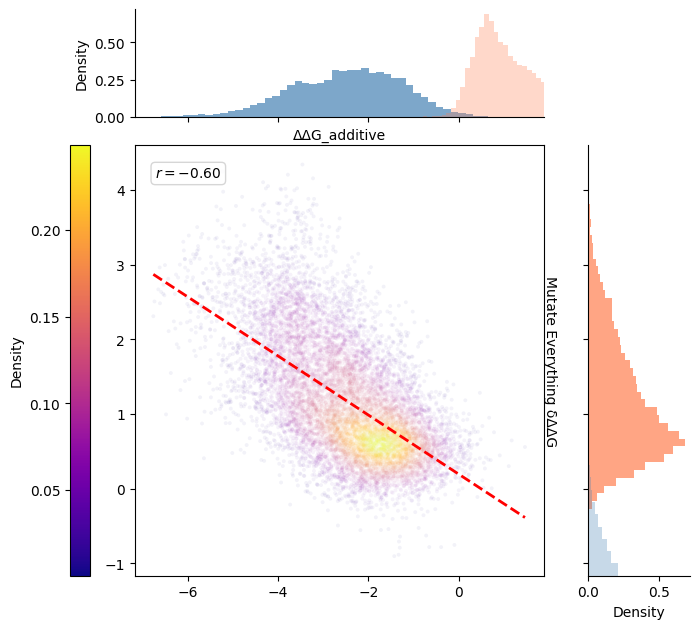

In [ ]:
df_dddG_clean = df_dddG[['ΔΔG_additive', 'MutateEverything_1_dddG']].dropna()

df_dddG_clean.rename(columns={'MutateEverything_1_dddG': 'Mutate Everything δΔΔG'}, inplace=True)

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['Mutate Everything δΔΔG'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['Mutate Everything δΔΔG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['Mutate Everything δΔΔG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['Mutate Everything δΔΔG']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG_clean[['Mutate Everything δΔΔG', 'ΔΔG_additive']].corr('spearman'))

0.016485998193315265
-0.030652281271019856
0.8548212419353336
                       ThermoMPNN(-D)_1_dddG  ΔΔG_additive
ThermoMPNN(-D)_1_dddG               1.000000     -0.098784
ΔΔG_additive                       -0.098784      1.000000


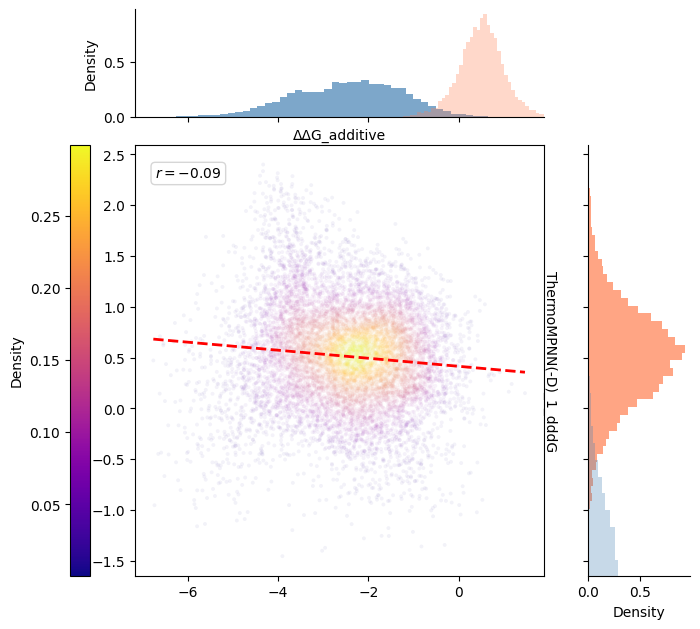

In [ ]:
df_dddG_clean = df_dddG[['ΔΔG_additive', 'ThermoMPNN(-D)_1_dddG']].dropna()

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['ThermoMPNN(-D)_1_dddG'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['ThermoMPNN(-D)_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['ThermoMPNN(-D)_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['ThermoMPNN(-D)_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG_clean[['ThermoMPNN(-D)_1_dddG', 'ΔΔG_additive']].corr('spearman'))

0.007551055431611464
-0.06651205144023743
0.5022995044166685
              SPURS_1_dddG  ΔΔG_additive
SPURS_1_dddG      1.000000     -0.173829
ΔΔG_additive     -0.173829      1.000000


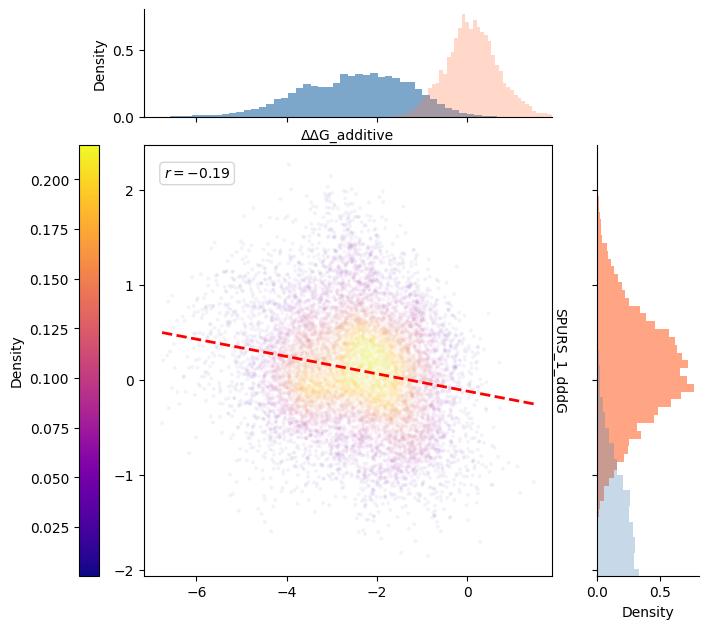

In [ ]:
df_dddG_clean = df_dddG[['ΔΔG_additive', 'SPURS_1_dddG']].dropna()

density_scatter(df_dddG_clean['ΔΔG_additive'], df_dddG_clean['SPURS_1_dddG'], point_alpha=0.05, s=8, cmap="plasma", hide_marginal_legend=True, stats=True)

f1 = f1_score(df_dddG_clean[['SPURS_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['SPURS_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']]>0)
auprc = average_precision_score(df_dddG_clean[['SPURS_1_dddG']]>0, df_dddG_clean[['ΔΔG_additive']])

print(f1)
print(mcc)
print(auprc)
print(df_dddG_clean[['SPURS_1_dddG', 'ΔΔG_additive']].corr('spearman'))

0.8524629363940698
0.17975426914900697
0.9219224231534958


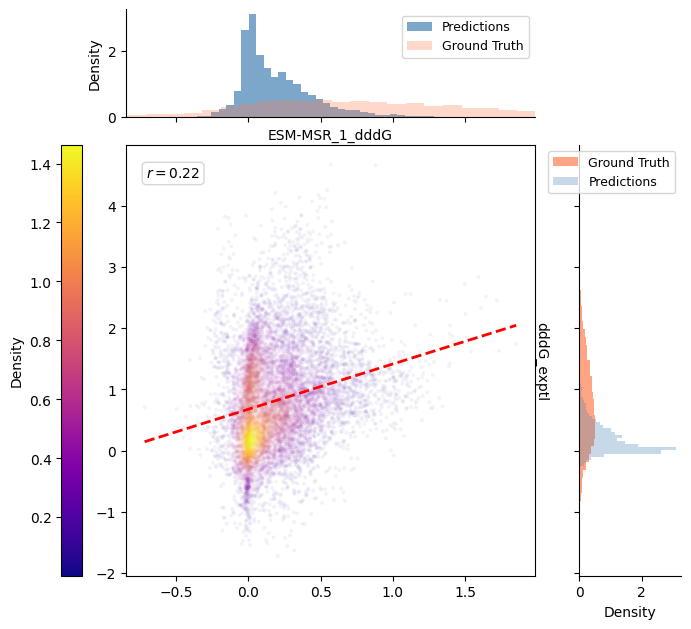

In [ ]:
df_dddG['dddG_exptl'] = df_dddG['ddG_dddG']
df_dddG_clean = df_dddG[['dddG_exptl', 'ESM-MSR_1_dddG']].dropna()

density_scatter(df_dddG_clean['ESM-MSR_1_dddG'], df_dddG_clean['dddG_exptl'], point_alpha=0.05, s=8, cmap="plasma", stats=True)

f1 = f1_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ESM-MSR_1_dddG']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ESM-MSR_1_dddG']]>0)
auprc = average_precision_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ESM-MSR_1_dddG']])

print(f1)
print(mcc)
print(auprc)

0.9143470099222312
0.05398385659727765
0.9150860326826076


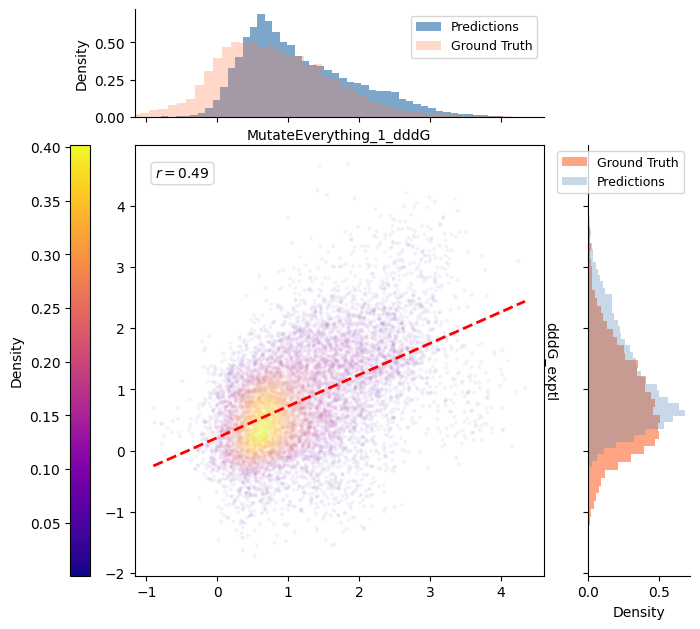

In [ ]:
df_dddG['dddG_exptl'] = df_dddG['ddG_dddG']
df_dddG_clean = df_dddG[['dddG_exptl', 'MutateEverything_1_dddG']].dropna()

density_scatter(df_dddG_clean['MutateEverything_1_dddG'], df_dddG_clean['dddG_exptl'], point_alpha=0.05, s=8, cmap="plasma", stats=True)

f1 = f1_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['MutateEverything_1_dddG']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['MutateEverything_1_dddG']]>0)
auprc = average_precision_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['MutateEverything_1_dddG']])

print(f1)
print(mcc)
print(auprc)

0.8479246799471841
-0.05508657550430608
0.8722757114607005


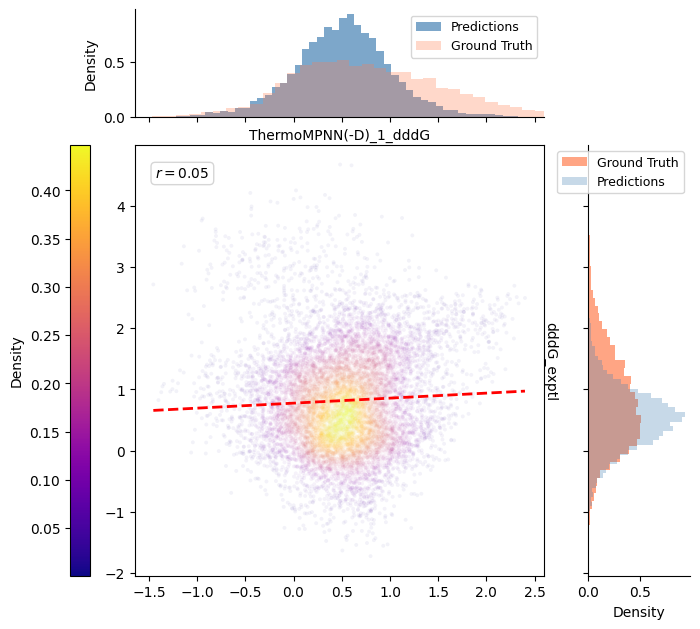

In [ ]:
df_dddG['dddG_exptl'] = df_dddG['ddG_dddG']
df_dddG_clean = df_dddG[['dddG_exptl', 'ThermoMPNN(-D)_1_dddG']].dropna()

density_scatter(df_dddG_clean['ThermoMPNN(-D)_1_dddG'], df_dddG_clean['dddG_exptl'], point_alpha=0.05, s=8, cmap="plasma", stats=True)

f1 = f1_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ThermoMPNN(-D)_1_dddG']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ThermoMPNN(-D)_1_dddG']]>0)
auprc = average_precision_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['ThermoMPNN(-D)_1_dddG']])

print(f1)
print(mcc)
print(auprc)

0.686726893676164
0.035969454023520864
0.8368814386453162


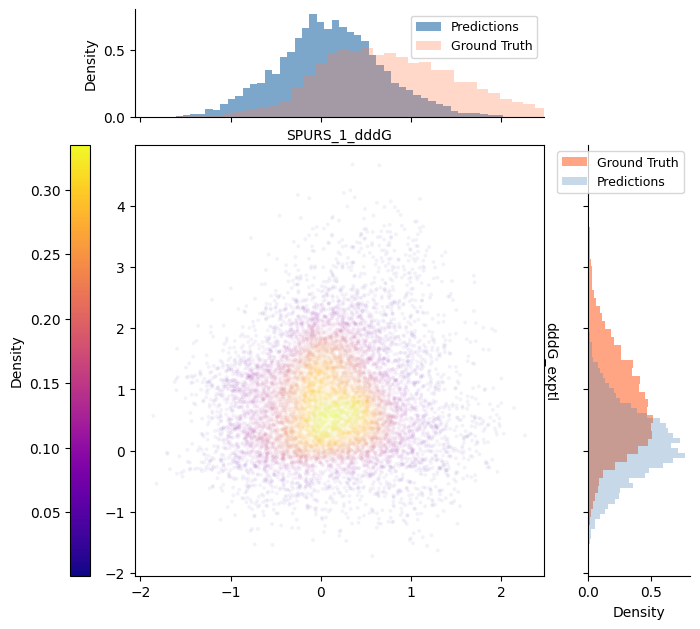

In [ ]:
df_dddG['dddG_exptl'] = df_dddG['ddG_dddG']
df_dddG_clean = df_dddG[['dddG_exptl', 'SPURS_1_dddG']].dropna()

density_scatter(df_dddG_clean['SPURS_1_dddG'], df_dddG_clean['dddG_exptl'], point_alpha=0.05, s=8, cmap="plasma")

f1 = f1_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['SPURS_1_dddG']]>0)
mcc = matthews_corrcoef(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['SPURS_1_dddG']]>0)
auprc = average_precision_score(df_dddG_clean[['dddG_exptl']]>0, df_dddG_clean[['SPURS_1_dddG']])

print(f1)
print(mcc)
print(auprc)

In [ ]:
df_dddG_clean = df_dddG[['ddG_dddG', 'ESM-MSR_1_dddG']].dropna()

tp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['ESM-MSR_1_dddG']>0)])
fp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['ESM-MSR_1_dddG']>0)])
tn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['ESM-MSR_1_dddG']<=0)])
fn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['ESM-MSR_1_dddG']<=0)])
print(tp, fp, tn, fn)
print(sum([tp, fp, tn, fn]))

7130 938 578 1530
10176


In [ ]:
df_dddG_clean = df_dddG[['ddG_dddG', 'ThermoMPNN(-D)_1_dddG']].dropna()

tp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['ThermoMPNN(-D)_1_dddG']>0)])
fp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['ThermoMPNN(-D)_1_dddG']>0)])
tn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['ThermoMPNN(-D)_1_dddG']<=0)])
fn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['ThermoMPNN(-D)_1_dddG']<=0)])
print(tp, fp, tn, fn)
print(sum([tp, fp, tn, fn]))

7385 1374 142 1275
10176


In [ ]:
df_dddG_clean = df_dddG[['ddG_dddG', 'MutateEverything_1_dddG']].dropna()

tp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['MutateEverything_1_dddG']>0)])
fp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['MutateEverything_1_dddG']>0)])
tn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['MutateEverything_1_dddG']<=0)])
fn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['MutateEverything_1_dddG']<=0)])
print(tp, fp, tn, fn)
print(sum([tp, fp, tn, fn]))

8524 1461 55 136
10176


In [ ]:
df_dddG_clean = df_dddG[['ddG_dddG', 'SPURS_1_dddG']].dropna()

tp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['SPURS_1_dddG']>0)])
fp = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['SPURS_1_dddG']>0)])
tn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']<=0) & (df_dddG_clean['SPURS_1_dddG']<=0)])
fn = len(df_dddG_clean.loc[(df_dddG_clean['ddG_dddG']>0) & (df_dddG_clean['SPURS_1_dddG']<=0)])
print(tp, fp, tn, fn)
print(sum([tp, fp, tn, fn]))

4941 789 727 3719
10176


In [ ]:
df_scores_dddG_combined[[c for c in df_scores_dddG_combined.columns if 'Negative' in c]]

Negative_additive  Negative_additive_n  \
mega_splits-D-test ungrouped           0.704691         10176.000000   
                       grouped             0.507187          1453.714286   

                                  Negative_additive_groups  \
mega_splits-D-test ungrouped                       NaN   
                       grouped                         7.0   

                                  Negative_additive_pos  \
mega_splits-D-test ungrouped               0.702709   
                       grouped                 0.494798   

                                  Negative_additive_n_pos  \
mega_splits-D-test ungrouped              8660.000000   
                       grouped                1237.142857   

                                  Negative_additive_groups_pos  \
mega_splits-D-test ungrouped                           NaN   
                       grouped                             7.0   

                                  Negative_additive_neg  \
mega_splits-D-test ungrouped               0.065148   
                       grouped                 0.140695   

                                  Negative_additive_n_neg  \
mega_splits-D-test ungrouped              1516.000000   
                       grouped                 216.571429   

                                  Negative_additive_groups_neg  
mega_splits-D-test ungrouped                           NaN  
                       grouped                             7.0

In [ ]:
#df_scores_dddG = pd.read_csv('~/PSLMs/data/lora/test_scores_new.csv', index_col=[0,1])
df_dddG = df_epistatic.copy(deep=True)
df_dddG = compute_dddg(df_dddG)

df_dddG = df_dddG.loc[df_dddG.index.str.contains(':')].reset_index()
#df_dddG['code'] = df_dddG['uid'].apply(lambda x: x.split('_')[0])
df_dddG['pos1'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[0][1:-1]).astype(int)
df_dddG['pos2'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[1][1:-1]).astype(int)
#tmp = df_dddG.groupby(['code', 'pos1', 'pos2'])[[c for c in df_dddG.columns if 'dddG' in c]].corr('spearman')[['ddG_dddG']].reset_index().set_index(['code', 'pos1', 'pos2'])
#tmp.columns = ['model', 'spearman']
#tmp.pivot(columns='model').mean()
tmp = df_dddG.groupby(['code', 'pos1', 'pos2'])[[c for c in df_dddG.columns if 'dddG' in c]].count()[['ddG_dddG']]
tmp2 = df_dddG.groupby(['code', 'pos1', 'pos2'])[[c for c in df_dddG.columns if 'dddG' in c]].corr('spearman').loc[slice(None), slice(None), slice(None), 'ddG_dddG', :]

tmp.rename({'ddG_dddG': 'dddG_ct'}, axis=1).join(tmp2).sort_values('dddG_ct', ascending=False).to_csv('doubles_count.csv')

In [ ]:
df_dddG = df_epistatic.copy(deep=True)
df_dddG = compute_dddg(df_dddG)

df_dddG = df_dddG.loc[df_dddG.index.str.contains(':')].reset_index()
df_dddG['code'] = df_dddG['uid'].apply(lambda x: x.split('_')[0])
df_dddG['pos1'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[0][1:-1]).astype(int)
df_dddG['pos2'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[1][1:-1]).astype(int)
df_dddG['mut1'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[0][-1]).astype(str)
df_dddG['mut2'] = df_dddG['mut_type'].apply(lambda x: x.split(':')[1][-1]).astype(str)
tmp = df_dddG.drop(['uid', 'mut_type'], axis=1)
pt = tmp.pivot_table(index=['code', 'pos1', 'pos2', 'mut1'], columns=['mut2'])
pt

ESM-MSR_1                                          \
mut2                        A         C         D         E         F   
code pos1 pos2 mut1                                                     
1UFM 14   49   A    -1.114347       NaN -1.294540 -0.811828 -1.196557   
               D    -1.542809       NaN -1.737846 -1.341140 -1.724250   
               F    -0.904436       NaN -1.093126 -0.578241 -0.666567   
               G    -2.031697       NaN -2.211481 -1.758093 -2.096697   
               H    -1.238430       NaN -1.383013 -0.847595 -1.343363   
...                       ...       ...       ...       ...       ...   
HHH  36   39   S    -1.937498       NaN -3.848206 -2.637868 -2.163040   
               T    -2.027340       NaN -3.972990 -2.762277 -2.252117   
               V    -1.924339 -1.867715 -3.917674 -2.703239 -2.080019   
               W    -1.443978 -1.352501 -3.373727 -2.288049 -1.352063   
               Y    -1.582097 -1.522289       NaN -2.417407 -1.575207   

                                                                       ...  \
mut2                        G         H         I         K         L  ...   
code pos1 pos2 mut1                                                    ...   
1UFM 14   49   A    -1.960371 -1.374147 -1.124939 -1.163056 -1.105243  ...   
               D    -2.363911 -1.782124 -1.550019 -1.524974 -1.533886  ...   
               F    -1.761964 -0.975416 -0.614628 -0.911470 -0.646508  ...   
               G    -2.853233 -2.266081 -2.032692 -2.043689 -2.020407  ...   
               H    -2.080213 -1.504137 -1.205050 -1.305719 -1.199978  ...   
...                       ...       ...       ...       ...       ...  ...   
HHH  36   39   S    -3.437373 -2.395945 -1.888238 -1.197873 -1.569708  ...   
               T    -3.489027 -2.500239 -1.980910 -1.268751 -1.650904  ...   
               V    -3.367916 -2.408534 -1.876210 -1.230632 -1.498533  ...   
               W    -2.872181 -1.826809 -1.482457 -0.683887 -1.036362  ...   
               Y    -3.047439 -2.028417 -1.533821 -0.808580 -1.045771  ...   

                     random_3                                          \
mut2                        M         N         P         Q         R   
code pos1 pos2 mut1                                                     
1UFM 14   49   A     0.896107  0.808592  0.101716       NaN  0.167910   
               D     0.455274  0.580573  0.582860       NaN  0.881279   
               F     0.143928  0.833169  0.668277       NaN  0.192561   
               G     0.899482  0.307712  0.060918       NaN  0.450476   
               H     0.947797  0.752010  0.022340       NaN  0.942972   
...                       ...       ...       ...       ...       ...   
HHH  36   39   S     0.901936  0.266679       NaN  0.874190       NaN   
               T     0.992506  0.793650  0.253306  0.650688       NaN   
               V     0.288053  0.385948       NaN  0.276794       NaN   
               W     0.261174  0.446416  0.034264  0.137113       NaN   
               Y     0.959331  0.045766  0.683842  0.871199       NaN   

                                                                       
mut2                        S         T         V         W         Y  
code pos1 pos2 mut1                                                    
1UFM 14   49   A     0.982519  0.004852  0.425258  0.360579  0.661835  
               D     0.239470  0.020394  0.783568  0.644647  0.873402  
               F     0.843101  0.404811  0.961335  0.968640  0.699544  
               G     0.519313  0.064783  0.955376  0.295841  0.080262  
               H     0.241644  0.911487  0.723830  0.519322  0.887474  
...                       ...       ...       ...       ...       ...  
HHH  36   39   S     0.753002  0.805867  0.079026  0.361761  0.733594  
               T     0.156303  0.896901  0.595641  0.567867  0.863416  
               V     0.083290  0.988886  0.259382  0.542503  0.915339  
               W 

In [ ]:
pt.reset_index().groupby(['code', 'pos1', 'pos2']).count()

mut1 ESM-MSR_1                                  ... random_3  \
mut2                        A   C   D   E   F   G   H   I   K  ...        M   
code pos1 pos2                                                 ...            
1UFM 14   49     18        18   0  18  18  18  18  18  18  18  ...       18   
          53     18        18   0  18   0  18  18  18  18  18  ...       18   
          55     18        18   0  18  18  18  18  18  18  18  ...       18   
     49   53     18        18   0  18   0  18  18  18  18  18  ...       18   
          55     18        18   0  18  18  18  18  18  18  18  ...       18   
     53   55     18        18   0  18  18  18  18  18  18  18  ...       18   
2RU9 10   42     19        16  17  16   0  18  17  17  16  18  ...       16   
3DKM 15   36     18        13   0   7   8  16  10  12  16  14  ...       14   
          51     18        15   0   0  12  18  11  16  17  14  ...       15   
     18   26     18        18   0   0  18  18  18  17  18  17  ...       18   
          28     19        19  19   0  19  19  19  19  19  19  ...       19   
     21   65     19        19  19  15  19  19  18  19  19   0  ...       19   
     24   59     18        12   0   2   2  16   0  16   3  18  ...       13   
          63     18        18   0  18   0  18  18  18   2  10  ...       18   
          67     18        11   0   0  18  18   1  10  14   1  ...       16   
     26   28     18        18   0   0  18  18  18  18  18  18  ...       18   
     27   50      6         0   0   0   0   4   0   0   2   0  ...        0   
          56     19        19  19  19  19  19  19  19  19  19  ...       19   
          58     18        18   0   0  18  18   1  18  17   2  ...       18   
     36   51     18        13   0   0  14  17   7  12  17   9  ...       11   
     50   58      1         0   0   0   0   0   0   0   0   0  ...        1   
     59   63     18        10   0  14   0  18  15  12  14   8  ...       13   
          65     19        16  19  13  16  19  15  18  19   0  ...       19   
          67     19        19  19   0  19  19  16  19  19  19  ...       19   
     63   67     18        11   0   0  17  18   3  14  17  13  ...       16   
6M3N 2    63     19        19  19  19  19  19  19   0  19  19  ...       19   
     4    49     19        19  19  19  19  19  19  19  19   0  ...       19   
     18   39     19        19  19  19  19  18  19  19  19  19  ...       19   
          58     19        19  19  19  19  19  19  19  19  19  ...       19   
     25   63     19        19  19  19  19  19  19   0  19  19  ...       19   
     29   45     19        19  19  19   0  19  19  19  19  19  ...       19   
     45   49     19        19  19  19  19  19  19  19  19   0  ...       19   
HHH  10   36     19        19  16  17   0  19  17  19  19  19  ...       19   
          41     19        19  13  19   0  19  19  19  19  19  ...       18   
     17   20     19        18  11  18   0  18  12  18  18  17  ...       18   
     31   34     19        19  11  19   0  11  19  13  19   2  ...       17   
     36   39     19        18  12  17  18  17  19  19  18  19  ...       18   

                                                    
mut2             N   P   Q   R   S   T   V   W   Y  
code pos1 pos2                                      
1UFM 14   49    18  18   0  18  18  18  18  18  18  
          53    18  18  18  18  18  18  18  18  18  
          55    18  18  18   0  18  18  18  18  18  
     49   53    18  18  18  18  18  18  18  17  17  
          55    18  18  18   0  18  18  18  18  18  
     53   55    18  18  18   0  18  18  18  18  18  
2RU9 10   42    16  14  16  18  16  17  16  18  17  
3DKM 15   36     6   9  12  17   9   0  16  17  15  
          51    15   7  13  13  14  15  17  18  18  
     18   26    18  17  17  17  18  18  18  18  18  
          28    19  19  19  19  19  19  18  19  19  
     21   65    19  13  19  19  19  19  19  19  19  
     24   59     5   0  11   0   8   4   1  18  18  
      

In [ ]:
pt.loc[('6M3N', 2, 63),('ESM-MSR_1', slice(None))]

ESM-MSR_1                                                        \
mut2         A         C         D         E         F         G   H   
mut1                                                                   
A    -1.995774 -1.182907 -2.488475 -2.373485 -0.829908 -2.330105 NaN   
C    -1.098339  0.445054 -1.644653 -1.501600 -0.086421 -1.365768 NaN   
D    -2.159278 -1.490345 -2.743444 -2.589319 -1.491132 -2.478931 NaN   
E    -2.310548 -1.652975 -2.872442 -2.743027 -1.663327 -2.616192 NaN   
G    -2.090273 -1.296261 -2.524298 -2.403002 -1.302433 -2.381764 NaN   
H    -1.890755 -1.185062 -2.285803 -2.216438 -0.869056 -2.219029 NaN   
I    -1.146129 -0.470058 -1.804173 -1.613702 -0.150502 -1.600423 NaN   
K    -2.223871 -1.544744 -2.578350 -2.432583 -1.648430 -2.531989 NaN   
L    -1.526368 -0.735471 -2.161249 -1.944527 -0.393932 -1.922397 NaN   
M    -1.720067 -0.898584 -2.292939 -2.111177 -0.398635 -2.064870 NaN   
N    -2.173709 -1.495695 -2.568549 -2.486282 -1.525422 -2.477634 NaN   
P    -1.868833 -1.035662 -2.309835 -2.179803 -0.956892 -2.155624 NaN   
Q    -2.134277 -1.497912 -2.582607 -2.488281 -1.379619 -2.451782 NaN   
R    -2.176133 -1.512995 -2.332734 -2.311214 -1.544004 -2.457980 NaN   
S    -2.086902 -1.350565 -2.459448 -2.379733 -1.279570 -2.408164 NaN   
T    -1.971962 -1.233665 -2.340263 -2.266150 -1.230655 -2.278222 NaN   
V    -1.386379 -0.678899 -2.032709 -1.856413 -0.208711 -1.841929 NaN   
W    -0.405187  0.359756 -1.207885 -0.894962  0.620933 -0.816683 NaN   
Y    -0.911509 -0.317674 -1.647287 -1.346080  0.003595 -1.369082 NaN   

                                                                            \
mut2         I         K         L         M         N         P         Q   
mut1                                                                         
A    -1.116833 -2.153726 -1.337981 -1.601346 -2.145634 -2.189486 -2.097534   
C    -0.433760 -1.182763 -0.562119 -0.770747 -1.293299 -1.265385 -1.236129   
D    -1.628771 -2.185834 -1.733487 -1.953781 -2.412811 -2.312470 -2.312551   
E    -1.836495 -2.218972 -1.954054 -2.153140 -2.507653 -2.473672 -2.401647   
G    -1.544412 -2.198904 -1.682070 -1.885048 -2.246213 -2.240481 -2.208297   
H    -1.282368 -1.955291 -1.333947 -1.570405 -2.025323 -2.065836 -1.921205   
I    -0.301501 -1.368879 -0.530962 -0.696172 -1.403480 -1.489077 -1.260257   
K    -1.764505 -2.413996 -1.919623 -2.077887 -2.390562 -2.426821 -2.348427   
L    -0.649402 -1.748291 -0.706075 -1.026381 -1.762414 -1.768321 -1.635425   
M    -0.875884 -1.870749 -0.992567 -1.232967 -1.890920 -1.901665 -1.791000   
N    -1.670942 -2.273130 -1.775593 -1.966281 -2.289515 -2.355532 -2.243855   
P    -1.276757 -2.033133 -1.382635 -1.593931 -2.016643 -2.048441 -1.976458   
Q    -1.603007 -2.223923 -1.713355 -1.898735 -2.239532 -2.325136 -2.183918   
R    -1.706177 -2.387710 -1.827483 -2.004265 -2.274146 -2.369391 -2.276628   
S    -1.508550 -2.148351 -1.645518 -1.848502 -2.160133 -2.252786 -2.132120   
T    -1.383644 -1.988206 -1.590027 -1.737173 -2.011247 -2.159883 -1.954411   
V    -0.388090 -1.614343 -0.710729 -0.871737 -1.632051 -1.731847 -1.495542   
W     0.236293 -0.439100  0.443705  0.093692 -0.545959 -0.597296 -0.331297   
Y    -0.334123 -0.960748 -0.310298 -0.520333 -1.209543 -1.178599 -0.978278   

                                                                  
mut2         R         S         T         V         W         Y  
mut1                                                              
A    -1.961047 -2.092309 -1.961140 -1.355669 -0.964838 -1.025858  
C    -1.024990 -1.197211 -1.095721 -0.588141 -0.129778 -0.225856  
D    -2.097833 -2.300258 -2.200875 -1.773803 -1.416436 -1.451690  
E    -2.039028 -2.411862 -2.338751 -1.956249 -1.634409 -1.619302  
G    -2.016291 -2.203703 -2.129424 -1.672788 -1.230253 -1.315787  
H    -1.769739 -1.901341 -1.802164 -1.425072 -0.948253 -1.021773  
I    -1.140797 -1.305817 -1.174713 -0.516580 -0.146736 -0.224173  
K    -2.223616 -2.314360 -2.23846

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# 20 canonical amino acids (1-letter)
AA  = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
IDX = {aa:i for i,aa in enumerate(AA)}
POS = {'K','R','H'}
NEG = {'D','E'}

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_joint_with_marginals(
    P, PA, PB, aa_labels, *,
    cmap='viridis',
    vmin=None, vmax=None,
    pos1=0, pos2=0
):
    n = len(aa_labels)
    
    # 1. Main Plot
    fig, ax_main = plt.subplots(figsize=(9., 8.))
    
    im = ax_main.imshow(P, origin='lower', interpolation='nearest',
                        cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
    
    ax_main.set_xticks([])
    #ax_main.set_xticklabels(aa_labels)
    ax_main.set_yticks([])
    #ax_main.set_yticklabels(aa_labels)
    ax_main.grid(False)
    ax_main.set_xlabel(pos2, rotation=0, fontsize=16)
    ax_main.set_ylabel(pos1, rotation=90, fontsize=16)

    # Annotate identities
    for i in range(n):
        ax_main.text(i, i, aa_labels[i], ha='center', va='center', fontsize=16, color='red')

    # 2. Divider for Marginals
    divider = make_axes_locatable(ax_main)
    
    # Append Top Axis
    ax_top = divider.append_axes("top", size="20%", pad=0.1, sharex=ax_main)
    
    # Append Right Axis
    ax_right = divider.append_axes("right", size="20%", pad=0.1, sharey=ax_main)
    
    # Append Colorbar Axis
    ax_cbar = divider.append_axes("right", size="5%", pad=0.15)

    extra = 0.2

    # --- 3. Top marginal P(B) ---
    pb = PB.squeeze()
    ax_top.bar(range(n), pb, align='center')
    ax_top.set_xlim(-0.5, n-0.5)
    ax_top.set_ylim(pb.min()-extra, pb.max()+extra)
    
    # Visuals: Add "score" and ticks
    ax_top.set_ylabel("score", fontsize=12)
    ax_top.tick_params(axis='y', labelsize=10)      # Show Y values
    ax_top.tick_params(axis='x', labelbottom=False) # Hide X labels (sharex with main)
    ax_top.grid(False)
    # (Optional) Remove top/right spines for cleanliness, keep Left/Bottom
    ax_top.spines['top'].set_visible(False)
    ax_top.spines['right'].set_visible(False)

    # --- 4. Right marginal P(A) ---
    pa = PA.squeeze()
    ax_right.barh(range(n), pa, align='center')
    ax_right.set_ylim(-0.5, n-0.5)
    ax_right.set_xlim(pa.min()-extra, pa.max()+extra)
    
    # Visuals: Add "score" and ticks
    ax_right.set_xlabel("score", fontsize=12)
    ax_right.tick_params(axis='x', labelsize=10)    # Show X values
    ax_right.tick_params(axis='y', labelleft=False) # Hide Y labels (sharey with main)
    ax_right.grid(False)
    # (Optional) Remove top/right spines for cleanliness, keep Bottom/Left
    ax_right.spines['top'].set_visible(False)
    ax_right.spines['right'].set_visible(False)

    # --- 5. Colorbar ---
    cbar = fig.colorbar(im, cax=ax_cbar)
    cbar.ax.tick_params(length=3)

    return fig

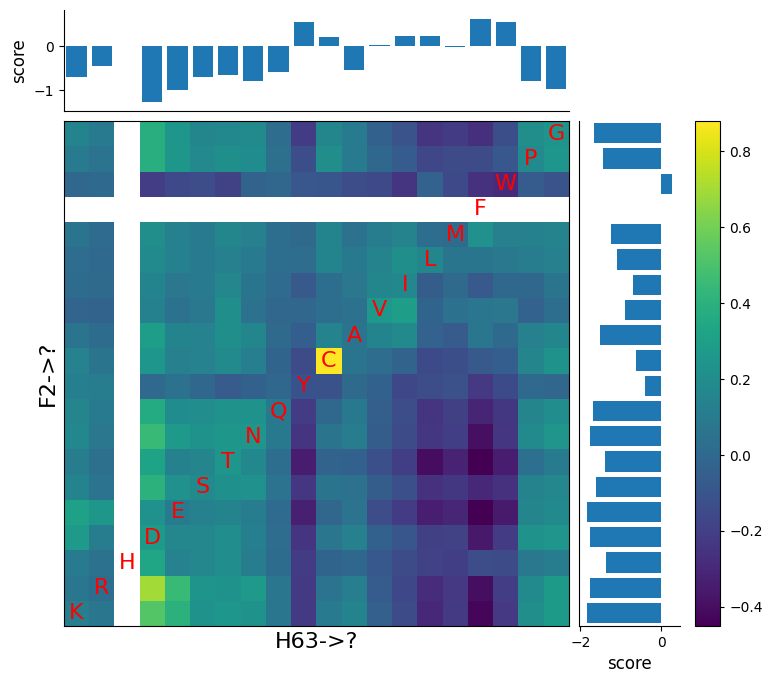

In [ ]:
p = df_epistatic.loc[~df_epistatic.index.str.contains(':')]
p = p.loc[p['code']=='6M3N']
p['mutation'] = p['mut_type'].apply(lambda x: x[-1])

PA = p.loc[p['mut_type'].apply(lambda x: int(x[1:-1]))==2]
PA = PA.set_index('mutation')
PA.loc['F', :] = np.nan
PA = PA.loc[AA]

PB = p.loc[p['mut_type'].apply(lambda x: int(x[1:-1]))==63]
PB = PB.set_index('mutation')
PB.loc['H', :] = np.nan
PB = PB.loc[AA]

p_test_double = pt.loc[('6M3N', 2, 63), ('ESM-MSR_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ESM-MSR_1']
pb = PB['ESM-MSR_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

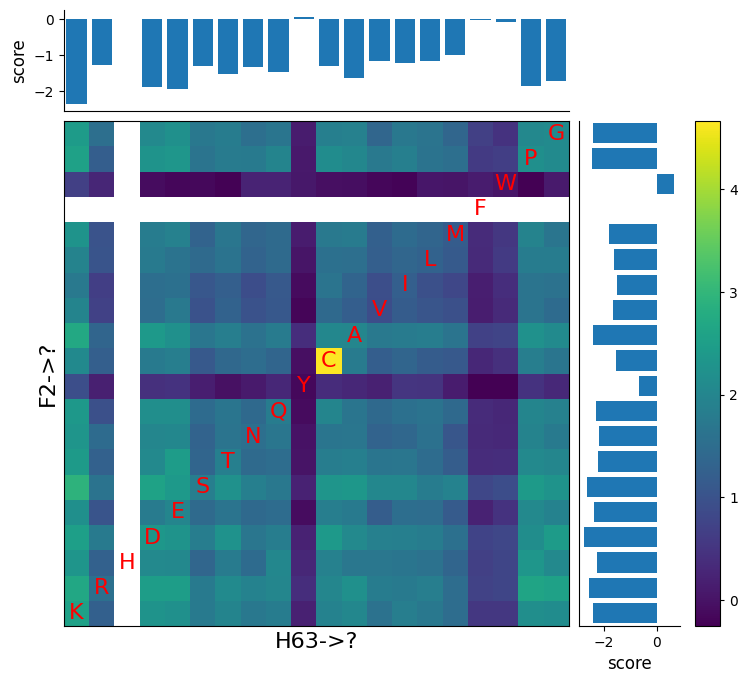

In [ ]:
p_test_double = pt.loc[('6M3N', 2, 63), ('ddG_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ddG']
pb = PB['ddG']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

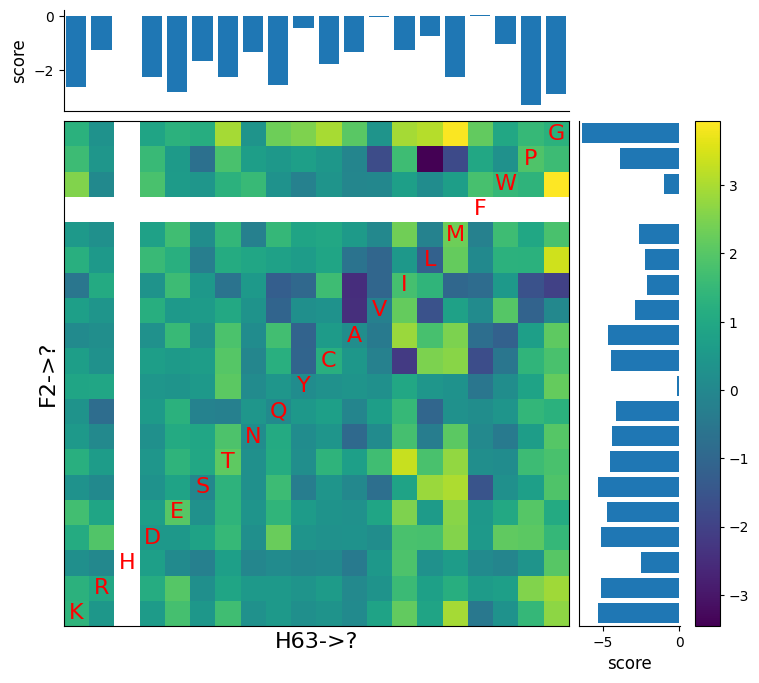

In [ ]:
p_test_double = pt.loc[('6M3N', 2, 63), ('Rosetta Cartesian DDG_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['Rosetta Cartesian DDG_1']
pb = PB['Rosetta Cartesian DDG_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

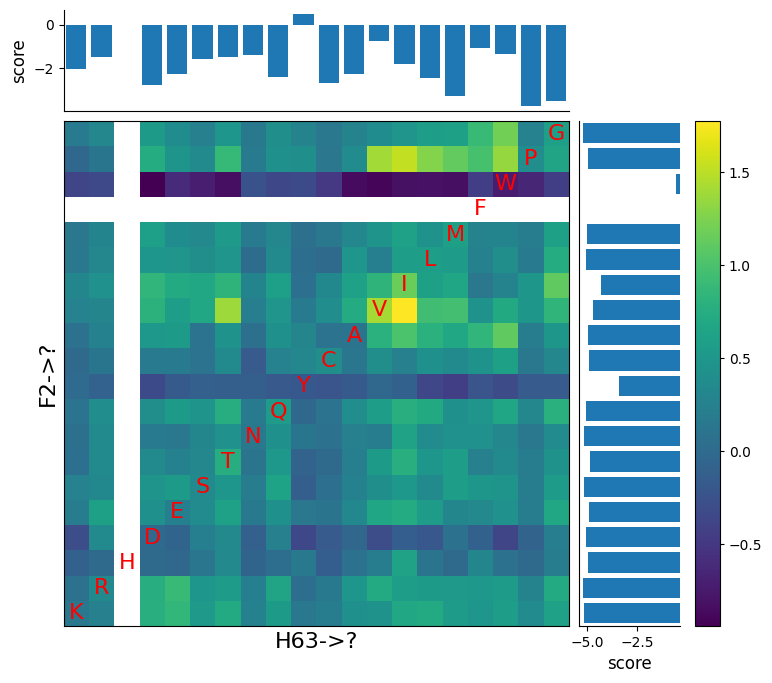

In [ ]:
p_test_double = pt.loc[('6M3N', 2, 63), ('ProteinMPNN_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ProteinMPNN']
pb = PB['ProteinMPNN']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

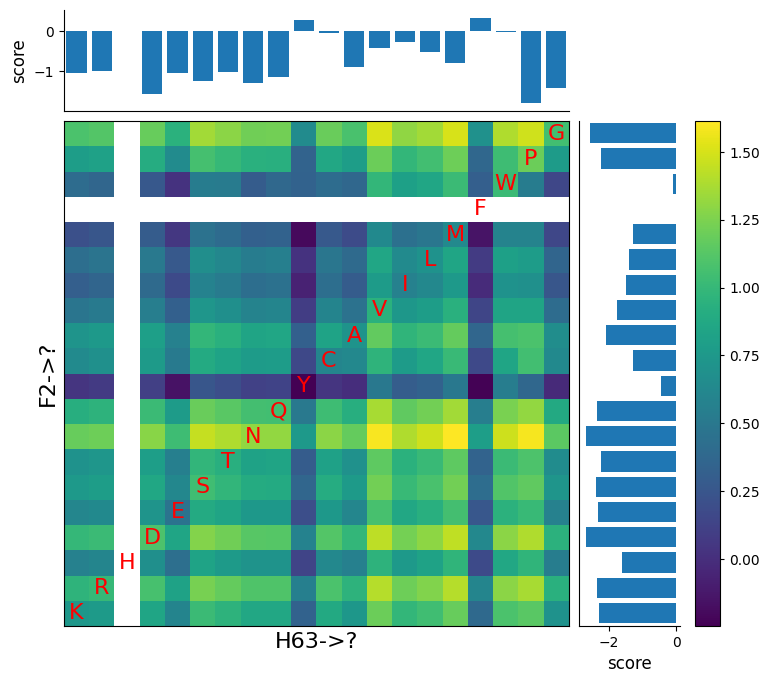

In [ ]:
p_test_double = pt.loc[('6M3N', 2, 63), ('ThermoMPNN(-D)_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['ThermoMPNN(-D)_1']
pb = PB['ThermoMPNN(-D)_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

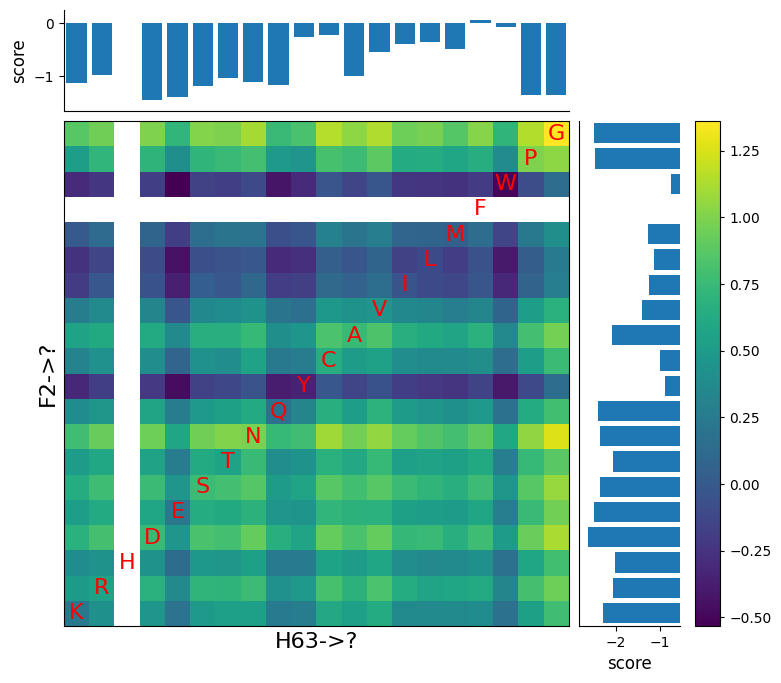

In [ ]:
p_test_double = pt.loc[('6M3N', 2, 63), ('SPURS_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['SPURS_1']
pb = PB['SPURS_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

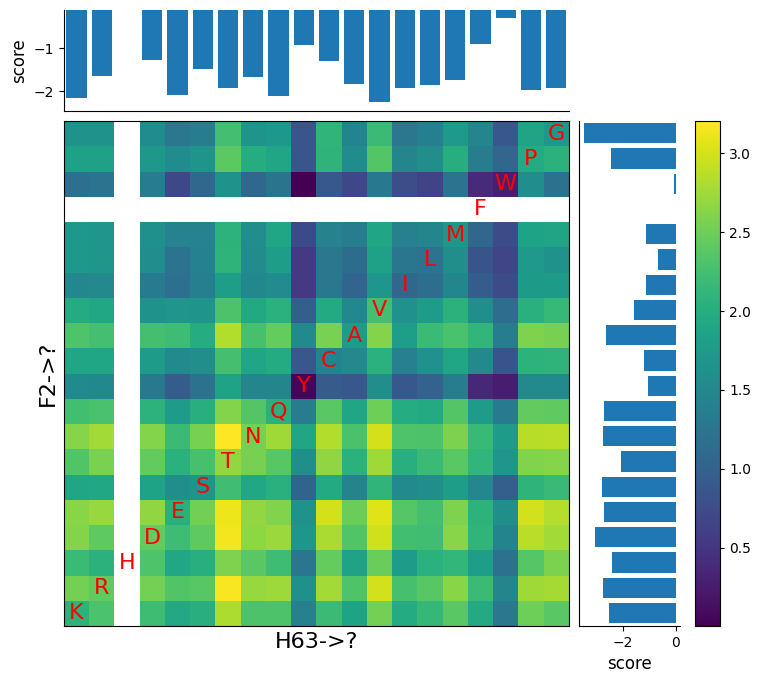

In [ ]:
p_test_double = pt.loc[('6M3N', 2, 63), ('MutateEverything_1_dddG', slice(None))]
p_test_double = p_test_double.T.reset_index(level=0, drop=True).T
p_test_double.loc['F', :] = np.nan
p_test_double

AA = ['K', 'R', 'H', 'D', 'E', 'S', 'T', 'N', 'Q', 'Y', 'C', 'A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G']
p_test_double = p_test_double.loc[AA, AA]
#pa = p_test_double.mean(axis=1)
#pb = p_test_double.mean(axis=0)
pa = PA['MutateEverything_1']
pb = PB['MutateEverything_1']
_ = plot_joint_with_marginals(p_test_double, pa, pb, aa_labels=AA, pos1='F2->?', pos2='H63->?')

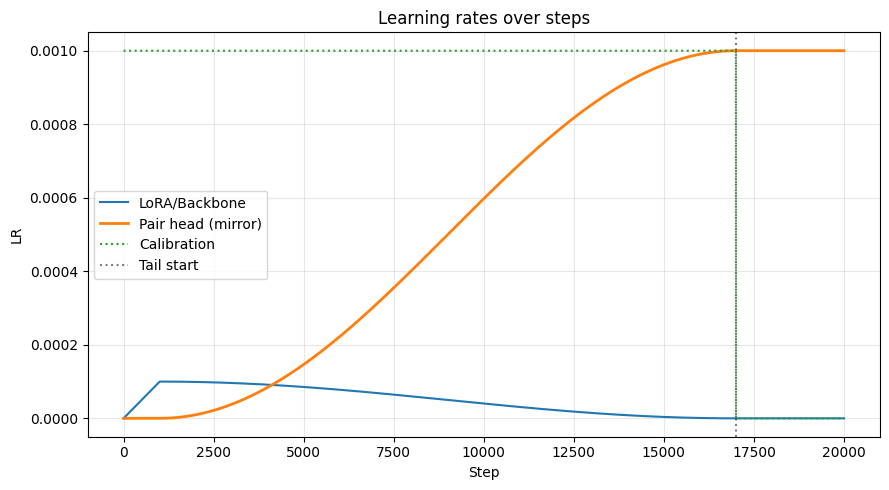

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

# --- Match these to your hparams ---
base_lr           = 1e-4
pair_lr_mult      = 10.0
calib_lr_mult     = 10.0
lr_warmup_steps   = 1000
lr_total_steps    = 20000
lr_tail_steps     = 3000
lr_tail_lora_mult = 0.0   # 0.0 => LoRA frozen in tail
tail_only_pair    = True

main_end = max(0, lr_total_steps - lr_tail_steps)

def warmcos(step, warmup, total_main):
    if total_main <= 0:
        return 1.0
    if step < warmup:
        return step / max(1, warmup)
    t = min(max(0, step - warmup), max(1, total_main - warmup))
    prog = t / max(1, total_main - warmup)
    return 0.5 * (1.0 + math.cos(math.pi * prog))  # 1 -> 0

def lambda_lora(step):
    if step < main_end:
        return warmcos(step, lr_warmup_steps, main_end)
    return lr_tail_lora_mult

def lambda_pair(step):
    if step < lr_warmup_steps:
        return 0.0
    if step < main_end:
        return 1.0 - warmcos(step, lr_warmup_steps, main_end)
    return max(0.0, min(1.0, 1.0 - lr_tail_lora_mult))

def lambda_calib(step):
    if step < main_end:
        return 1.0
    return 0.0 if tail_only_pair else 1.0

steps = np.arange(lr_total_steps+1)
lora_lr  = base_lr * np.array([lambda_lora(s)  for s in steps])
pair_lr  = base_lr * pair_lr_mult  * np.array([lambda_pair(s)  for s in steps])
cal_lr   = base_lr * calib_lr_mult * np.array([lambda_calib(s) for s in steps])

plt.figure(figsize=(9,5))
plt.plot(steps, lora_lr,  label="LoRA/Backbone")
plt.plot(steps, pair_lr,  label="Pair head (mirror)", linewidth=2)
plt.plot(steps, cal_lr,   label="Calibration", linestyle=":")
plt.axvline(main_end, color='k', linestyle=':', alpha=0.5, label="Tail start")
plt.title("Learning rates over steps")
plt.xlabel("Step")
plt.ylabel("LR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
# Extract the part of 'code' after the last underscore.
# If no underscore, it takes the whole string.
# If 'code' is NaN, this will result in NaN.
part_after_last_underscore = df['code'].str.rsplit('_', n=1).str[-1]

# Regex for: one letter, two digits, one letter.
# ^ and $ ensure the entire extracted part matches this pattern.
# na=False ensures that if part_after_last_underscore is NaN, it evaluates to False.
regex_suffix_pattern = r'^[a-zA-Z]\d{2}[a-zA-Z]$'
condition2 = part_after_last_underscore.str.fullmatch(regex_suffix_pattern, na=False)

df_destab = df.loc[condition2]
df_no_destab = df.drop(df_destab.index)

# 1. Extract the part of 'code' before the first underscore.
#    If no underscore, it takes the whole string.
code_prefix = df['code'].str.split('_', n=1).str[0]

# 2. Define the regex to match strings containing only A, E, G, H, X.
#    ^ asserts position at start of the string.
#    [AEGHX] matches any character from the set A, E, G, H, X.
#    * matches the previous token between zero and unlimited times.
#    $ asserts position at the end of the string.
regex_pattern = r'^[AEGHX]*$'

# 3. Create a boolean Series by checking if the extracted prefix fully matches the regex.
#    .str.fullmatch() checks if the entire string matches the pattern.
#    .fillna(False) handles any NaN values that might result from NaN 'code' values
#    or if 'code' wasn't a string type initially for some rows.
matches = code_prefix.str.fullmatch(regex_pattern).fillna(False)
matches2 = df.loc[df['code'].str.contains('TrROS')].index

# 4. Use the boolean Series to filter the original DataFrame.
df_synthetic = df.loc[matches | df['code'].str.contains('TrROS', na=False, regex=False)]
df_natural = df.drop(df_synthetic.index)

df_singles = df.loc[~df['mut_type'].str.contains(':')]
df_doubles = df.loc[df['mut_type'].str.contains(':')]

# All raw predictions
df

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_chain_3,ESM-MSR_chain_additive_3,ESM3-small-open_chain,ESM3-small-open_chain_additive,random_1,random_2,random_3,ddG_1,ddG_2,ddG_3
uid,,,,,,,,,,,,,,,,,,,,,
1UFM_A11C,0.182458,0.182458,0.229011,0.229011,0.112110,0.112110,0.182458,0.229011,0.112110,0.004061,...,-0.008952,NaN,-3.500977,-3.500977,0.272155,0.570931,0.916654,-0.149661,0.081054,0.319078
1UFM_A11D,-0.534806,-0.534806,-0.776187,-0.776187,-0.690362,-0.690362,-0.534806,-0.776187,-0.690362,-0.023454,...,-0.349982,NaN,-3.756836,-3.756836,0.089641,0.177495,0.818326,-0.216039,-0.121627,0.033731
1UFM_A11E,-0.127483,-0.127483,-0.176427,-0.176427,-0.169683,-0.169683,-0.127483,-0.176427,-0.169683,0.111864,...,-0.195433,NaN,-2.891602,-2.891602,0.074154,0.302124,0.408255,0.177096,0.306805,0.212301
1UFM_A11F,-0.037749,-0.037749,-0.077629,-0.077629,-0.115784,-0.115784,-0.037749,-0.077629,-0.115784,-0.153650,...,-0.200250,NaN,-0.421875,-0.421875,0.275582,0.140575,0.076596,-0.037803,-0.323529,-0.169571
1UFM_A11G,-0.565192,-0.565192,-0.628311,-0.628311,-0.642682,-0.642682,-0.565192,-0.628311,-0.642682,-0.393182,...,-0.567176,NaN,-1.704346,-1.704346,0.292255,0.297336,0.381845,-0.283127,-0.512478,-0.403497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HHH_rd1_0949_R10Y:E36S,-1.687004,-0.557682,-1.533284,-1.408043,-1.497178,-0.774565,-1.687004,-1.533284,-1.497178,NaN,...,-1.184945,-1.764554,-6.273010,-8.136230,0.900899,0.575471,0.944118,-0.268626,-0.433310,-0.400328
HHH_rd1_0949_R10Y:E36T,-1.304661,-0.486829,-1.297930,-1.210776,-1.352677,-0.265816,-1.304661,-1.297930,-1.352677,NaN,...,-0.959004,-1.458845,-6.709229,-8.262451,0.146386,0.016234,0.547932,-0.317286,-0.502875,-0.500392
HHH_rd1_0949_R10Y:E36V,-0.525491,-0.274588,-0.531802,-0.501731,-0.583954,0.229817,-0.525491,-0.531802,-0.583954,NaN,...,-0.217062,-1.098734,-4.707153,-6.614746,0.495901,0.402472,0.038472,0.346263,0.372083,0.322442


In [ ]:
df_destab

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_chain_3,ESM-MSR_chain_additive_3,ESM3-small-open_chain,ESM3-small-open_chain_additive,random_1,random_2,random_3,ddG_1,ddG_2,ddG_3
uid,,,,,,,,,,,,,,,,,,,,,
2K5H_G11S_A16C,0.046979,0.046979,0.249217,0.249217,0.076645,0.076645,0.046979,0.249217,0.076645,-0.213358,...,-0.127358,NaN,-4.082031,-4.082031,0.994296,0.349725,0.001383,-0.085477,-0.225541,-0.301982
2K5H_G11S_A16D,-1.036003,-1.036003,-0.852490,-0.852490,-1.009371,-1.009371,-1.036003,-0.852490,-1.009371,-2.029711,...,-0.919783,NaN,-2.433594,-2.433594,0.647252,0.115696,0.712361,-2.008197,-1.902532,-2.264372
2K5H_G11S_A16E,-0.587239,-0.587239,-0.503795,-0.503795,-0.641665,-0.641665,-0.587239,-0.503795,-0.641665,-1.146346,...,-0.429852,NaN,-0.200195,-0.200195,0.804128,0.226441,0.613019,-1.127524,-1.119457,-1.249664
2K5H_G11S_A16F,-0.024102,-0.024102,0.287125,0.287125,-0.126980,-0.126980,-0.024102,0.287125,-0.126980,-0.681503,...,-0.523631,NaN,-2.895508,-2.895508,0.886742,0.711250,0.538822,-0.813081,-0.792058,-0.597990
2K5H_G11S_A16G,-0.708306,-0.708306,-0.459338,-0.459338,-0.631421,-0.631421,-0.708306,-0.459338,-0.631421,-0.894964,...,-0.554826,NaN,-2.598633,-2.598633,0.433207,0.269828,0.545558,-0.911818,-0.875252,-1.044720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2K5H_G23A_W32I,-1.067356,-1.067356,-0.905483,-0.905483,-1.144713,-1.144713,-1.067356,-0.905483,-1.144713,-2.467404,...,-1.256215,NaN,-11.465332,-11.465332,0.260043,0.604416,0.895731,-2.309370,-2.157116,-2.464187
2K5H_G23A_W32L,-0.775358,-0.775358,-0.826621,-0.826621,-1.234344,-1.234344,-0.775358,-0.826621,-1.234344,-1.535847,...,-1.303674,NaN,-9.309570,-9.309570,0.694036,0.109906,0.288450,-1.208400,-1.506144,-1.345123
2K5H_G23A_W32M,-1.115607,-1.115607,-1.004328,-1.004328,-1.199729,-1.199729,-1.115607,-1.004328,-1.199729,-1.658541,...,-1.275073,NaN,-9.964844,-9.964844,0.203364,0.220828,0.961525,-1.390649,-1.434748,-1.673389


In [ ]:
df_synthetic

,ThermoMPNN_1,ThermoMPNN(-D)_1,ThermoMPNN_2,ThermoMPNN(-D)_2,ThermoMPNN_3,ThermoMPNN(-D)_3,ThermoMPNN(-D)_additive_1,ThermoMPNN(-D)_additive_2,ThermoMPNN(-D)_additive_3,ddG_ML_thermo,...,ESM-MSR_chain_3,ESM-MSR_chain_additive_3,ESM3-small-open_chain,ESM3-small-open_chain_additive,random_1,random_2,random_3,ddG_1,ddG_2,ddG_3
uid,,,,,,,,,,,,,,,,,,,,,
EA_run3_0321_0005_A17C,-0.830232,-0.830232,-0.766644,-0.766644,-0.724406,-0.724406,-0.830232,-0.766644,-0.724406,-1.642537,...,-0.464985,NaN,-9.240234,-9.240234,0.704097,0.358876,0.944919,-1.774227,-1.591072,-1.696376
EA_run3_0321_0005_A17D,-2.164598,-2.164598,-2.033794,-2.033794,-2.250737,-2.250737,-2.164598,-2.033794,-2.250737,-1.047616,...,-2.072132,NaN,-13.870117,-13.870117,0.676405,0.573310,0.871597,-0.932687,-0.884769,-1.094622
EA_run3_0321_0005_A17E,-2.029873,-2.029873,-1.955475,-1.955475,-2.051458,-2.051458,-2.029873,-1.955475,-2.051458,-1.141996,...,-2.076048,NaN,-13.519531,-13.519531,0.104346,0.444437,0.356610,-1.104963,-1.237719,-1.102093
EA_run3_0321_0005_A17F,-1.202985,-1.202985,-1.222521,-1.222521,-1.385140,-1.385140,-1.202985,-1.222521,-1.385140,-0.086403,...,-1.048928,NaN,-16.625000,-16.625000,0.931742,0.021894,0.310032,-0.061574,-0.279192,-0.222040
EA_run3_0321_0005_A17G,-1.583284,-1.583284,-1.513969,-1.513969,-1.603062,-1.603062,-1.583284,-1.513969,-1.603062,-0.826196,...,-1.572290,NaN,-7.304688,-7.304688,0.409424,0.529199,0.285222,-0.694626,-0.826482,-0.841022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HHH_rd1_0949_R10Y:E36S,-1.687004,-0.557682,-1.533284,-1.408043,-1.497178,-0.774565,-1.687004,-1.533284,-1.497178,NaN,...,-1.184945,-1.764554,-6.273010,-8.136230,0.900899,0.575471,0.944118,-0.268626,-0.433310,-0.400328
HHH_rd1_0949_R10Y:E36T,-1.304661,-0.486829,-1.297930,-1.210776,-1.352677,-0.265816,-1.304661,-1.297930,-1.352677,NaN,...,-0.959004,-1.458845,-6.709229,-8.262451,0.146386,0.016234,0.547932,-0.317286,-0.502875,-0.500392
HHH_rd1_0949_R10Y:E36V,-0.525491,-0.274588,-0.531802,-0.501731,-0.583954,0.229817,-0.525491,-0.531802,-0.583954,NaN,...,-0.217062,-1.098734,-4.707153,-6.614746,0.495901,0.402472,0.038472,0.346263,0.372083,0.322442


In [ ]:
df_scores_singles = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-test'], ['ungrouped', 'grouped']]))

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM-MSR_1', 'mega_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM-MSR_2', 'mega_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM-MSR_3', 'mega_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_singles = df_scores_singles.iloc[:, -6:].dropna(how='all')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'SPURS_1', 'mega_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'SPURS_2', 'mega_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'SPURS_3', 'mega_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ThermoMPNN(-D)_1', 'mega_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ThermoMPNN(-D)_2', 'mega_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ThermoMPNN(-D)_3', 'mega_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'MutateEverything_1', 'mega_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'MutateEverything_2', 'mega_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'MutateEverything_3', 'mega_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-small-open', 'mega_splits-test', pred_col='ESM3-small-open', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-small', 'mega_splits-test', pred_col='ESM3-small', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-medium', 'mega_splits-test', pred_col='ESM3-medium', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ESM3-large', 'mega_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'Rosetta Cartesian DDG_1', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'Rosetta Cartesian DDG_2', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'Rosetta Cartesian DDG_3', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_singles = assess_grouped_spearman(df_singles, df_scores_singles, 'ProteinMPNN', 'mega_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_singles

df_scores_doubles = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-test'], ['ungrouped', 'grouped']]))

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM-MSR_1', 'mega_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM-MSR_2', 'mega_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM-MSR_3', 'mega_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_doubles = df_scores_doubles.iloc[:, -6:].dropna(how='all')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'SPURS_1', 'mega_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'SPURS_2', 'mega_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'SPURS_3', 'mega_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ThermoMPNN(-D)_1', 'mega_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ThermoMPNN(-D)_2', 'mega_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ThermoMPNN(-D)_3', 'mega_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'MutateEverything_1', 'mega_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'MutateEverything_2', 'mega_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'MutateEverything_3', 'mega_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-small-open', 'mega_splits-test', pred_col='ESM3-small-open', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-small', 'mega_splits-test', pred_col='ESM3-small', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-medium', 'mega_splits-test', pred_col='ESM3-medium', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ESM3-large', 'mega_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'Rosetta Cartesian DDG_1', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'Rosetta Cartesian DDG_2', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'Rosetta Cartesian DDG_3', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_doubles = assess_grouped_spearman(df_doubles, df_scores_doubles, 'ProteinMPNN', 'mega_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_doubles

df_scores_destab = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-test'], ['ungrouped', 'grouped']]))

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM-MSR_1', 'mega_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM-MSR_2', 'mega_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM-MSR_3', 'mega_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_destab = df_scores_destab.iloc[:, -6:].dropna(how='all')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'SPURS_1', 'mega_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'SPURS_2', 'mega_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'SPURS_3', 'mega_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ThermoMPNN(-D)_1', 'mega_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ThermoMPNN(-D)_2', 'mega_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ThermoMPNN(-D)_3', 'mega_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'MutateEverything_1', 'mega_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'MutateEverything_2', 'mega_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'MutateEverything_3', 'mega_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-small-open', 'mega_splits-test', pred_col='ESM3-small-open', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-small', 'mega_splits-test', pred_col='ESM3-small', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-medium', 'mega_splits-test', pred_col='ESM3-medium', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ESM3-large', 'mega_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'Rosetta Cartesian DDG_1', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'Rosetta Cartesian DDG_2', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'Rosetta Cartesian DDG_3', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_destab = assess_grouped_spearman(df_destab, df_scores_destab, 'ProteinMPNN', 'mega_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_destab

df_scores_no_destab = pd.DataFrame(index=pd.MultiIndex.from_product([['mega_splits-test'], ['ungrouped', 'grouped']]))

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM-MSR_1', 'mega_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM-MSR_2', 'mega_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM-MSR_3', 'mega_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_no_destab = df_scores_no_destab.iloc[:, -6:].dropna(how='all')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'SPURS_1', 'mega_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'SPURS_2', 'mega_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'SPURS_3', 'mega_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ThermoMPNN(-D)_1', 'mega_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ThermoMPNN(-D)_2', 'mega_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ThermoMPNN(-D)_3', 'mega_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'MutateEverything_1', 'mega_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'MutateEverything_2', 'mega_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'MutateEverything_3', 'mega_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-small-open', 'mega_splits-test', pred_col='ESM3-small-open', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-small', 'mega_splits-test', pred_col='ESM3-small', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-medium', 'mega_splits-test', pred_col='ESM3-medium', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ESM3-large', 'mega_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'Rosetta Cartesian DDG_1', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'Rosetta Cartesian DDG_2', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'Rosetta Cartesian DDG_3', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_no_destab = assess_grouped_spearman(df_no_destab, df_scores_no_destab, 'ProteinMPNN', 'mega_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_no_destab

df_scores_synthetic = pd.read_csv('~/PSLMs/data/lora/test_scores_new.csv', index_col=[0,1])

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM-MSR_1', 'mega_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM-MSR_2', 'mega_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM-MSR_3', 'mega_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_synthetic = df_scores_synthetic.iloc[:, -6:].dropna(how='all')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'SPURS_1', 'mega_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'SPURS_2', 'mega_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'SPURS_3', 'mega_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ThermoMPNN(-D)_1', 'mega_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ThermoMPNN(-D)_2', 'mega_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ThermoMPNN(-D)_3', 'mega_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'MutateEverything_1', 'mega_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'MutateEverything_2', 'mega_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'MutateEverything_3', 'mega_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-small-open', 'mega_splits-test', pred_col='ESM3-small-open', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-small', 'mega_splits-test', pred_col='ESM3-small', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-medium', 'mega_splits-test', pred_col='ESM3-medium', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ESM3-large', 'mega_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'Rosetta Cartesian DDG_1', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'Rosetta Cartesian DDG_2', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'Rosetta Cartesian DDG_3', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_synthetic = assess_grouped_spearman(df_synthetic, df_scores_synthetic, 'ProteinMPNN', 'mega_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_synthetic

df_scores_natural = pd.read_csv('~/PSLMs/data/lora/test_scores_new.csv', index_col=[0,1])

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM-MSR_1', 'mega_splits-test', pred_col='ESM-MSR_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM-MSR_2', 'mega_splits-test', pred_col='ESM-MSR_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM-MSR_3', 'mega_splits-test', pred_col='ESM-MSR_3', label='ddG')
df_scores_natural = df_scores_natural.iloc[:, -6:].dropna(how='all')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'SPURS_1', 'mega_splits-test', pred_col='SPURS_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'SPURS_2', 'mega_splits-test', pred_col='SPURS_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'SPURS_3', 'mega_splits-test', pred_col='SPURS_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ThermoMPNN(-D)_1', 'mega_splits-test', pred_col='ThermoMPNN(-D)_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ThermoMPNN(-D)_2', 'mega_splits-test', pred_col='ThermoMPNN(-D)_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ThermoMPNN(-D)_3', 'mega_splits-test', pred_col='ThermoMPNN(-D)_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'MutateEverything_1', 'mega_splits-test', pred_col='MutateEverything_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'MutateEverything_2', 'mega_splits-test', pred_col='MutateEverything_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'MutateEverything_3', 'mega_splits-test', pred_col='MutateEverything_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-small-open', 'mega_splits-test', pred_col='ESM3-small-open', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-small', 'mega_splits-test', pred_col='ESM3-small', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-medium', 'mega_splits-test', pred_col='ESM3-medium', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ESM3-large', 'mega_splits-test', pred_col='ESM3-large', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'Rosetta Cartesian DDG_1', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_1', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'Rosetta Cartesian DDG_2', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_2', label='ddG')
df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'Rosetta Cartesian DDG_3', 'mega_splits-test', pred_col='Rosetta Cartesian DDG_3', label='ddG')

df_scores_natural = assess_grouped_spearman(df_natural, df_scores_natural, 'ProteinMPNN', 'mega_splits-test', pred_col='ProteinMPNN', label='ddG')

df_scores_natural

ESM-MSR_2  ESM-MSR_2_n  ESM-MSR_2_groups  \
dataset              grouping                                              
mega_splits-test ungrouped   0.703783    18107.000               NaN   
                     grouped     0.819630     2263.375               8.0   

                                ESM-MSR_3  ESM-MSR_3_n  ESM-MSR_3_groups  \
dataset              grouping                                              
mega_splits-test ungrouped    0.71535    18107.000               NaN   
                     grouped      0.81884     2263.375               8.0   

                                 SPURS_1  SPURS_1_n  SPURS_1_groups   SPURS_2  \
dataset              grouping                                                   
mega_splits-test ungrouped  0.726755  18107.000             NaN  0.742205   
                     grouped    0.695642   2263.375             8.0  0.696805   

                                ...  Rosetta Cartesian DDG_1_groups  \
dataset              grouping   ...                                   
mega_splits-test ungrouped  ...                             NaN   
                     grouped    ...                             8.0   

                                Rosetta Cartesian DDG_2  \
dataset              grouping                             
mega_splits-test ungrouped                 0.687554   
                     grouped                   0.654959   

                                Rosetta Cartesian DDG_2_n  \
dataset              grouping                               
mega_splits-test ungrouped                  18105.000   
                     grouped                     2263.125   

                                Rosetta Cartesian DDG_2_groups  \
dataset              grouping                                    
mega_splits-test ungrouped                             NaN   
                     grouped                               8.0   

                                Rosetta Cartesian DDG_3  \
dataset              grouping                             
mega_splits-test ungrouped                 0.688168   
                     grouped                   0.655747   

                                Rosetta Cartesian DDG_3_n  \
dataset              grouping                               
mega_splits-test ungrouped                  18105.000   
                     grouped                     2263.125   

                                Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
dataset              grouping                                                 
mega_splits-test ungrouped                             NaN     0.574080   
                     grouped                               8.0     0.609302   

                                ProteinMPNN_n  ProteinMPNN_groups  
dataset              grouping                                      
mega_splits-test ungrouped      18107.000                 NaN  
                     grouped         2263.375                 8.0  

[2 rows x 57 columns]

In [ ]:
df_scores_no_destab

ESM-MSR_2   ESM-MSR_2_n  ESM-MSR_2_groups  \
mega_splits-test ungrouped   0.720096  41398.000000               NaN   
                     grouped     0.803985   1217.588235              34.0   

                                ESM-MSR_3   ESM-MSR_3_n  ESM-MSR_3_groups  \
mega_splits-test ungrouped   0.733075  41398.000000               NaN   
                     grouped     0.802897   1217.588235              34.0   

                                 SPURS_1     SPURS_1_n  SPURS_1_groups  \
mega_splits-test ungrouped  0.713068  41398.000000             NaN   
                     grouped    0.648094   1217.588235            34.0   

                                 SPURS_2  ...  Rosetta Cartesian DDG_1_groups  \
mega_splits-test ungrouped  0.723446  ...                             NaN   
                     grouped    0.606036  ...                            34.0   

                                Rosetta Cartesian DDG_2  \
mega_splits-test ungrouped                 0.656903   
                     grouped                   0.631278   

                                Rosetta Cartesian DDG_2_n  \
mega_splits-test ungrouped               41387.000000   
                     grouped                  1217.264706   

                                Rosetta Cartesian DDG_2_groups  \
mega_splits-test ungrouped                             NaN   
                     grouped                              34.0   

                                Rosetta Cartesian DDG_3  \
mega_splits-test ungrouped                 0.656629   
                     grouped                   0.630253   

                                Rosetta Cartesian DDG_3_n  \
mega_splits-test ungrouped               41387.000000   
                     grouped                  1217.264706   

                                Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
mega_splits-test ungrouped                             NaN     0.592264   
                     grouped                              34.0     0.520064   

                                ProteinMPNN_n  ProteinMPNN_groups  
mega_splits-test ungrouped   41398.000000                 NaN  
                     grouped      1217.588235                34.0  

[2 rows x 57 columns]

In [ ]:
df_scores_destab

ESM-MSR_2  ESM-MSR_2_n  ESM-MSR_2_groups  \
mega_splits-test ungrouped   0.881645       2302.0               NaN   
                     grouped     0.885688       1151.0               2.0   

                                ESM-MSR_3  ESM-MSR_3_n  ESM-MSR_3_groups  \
mega_splits-test ungrouped   0.883907       2302.0               NaN   
                     grouped     0.887802       1151.0               2.0   

                                 SPURS_1  SPURS_1_n  SPURS_1_groups   SPURS_2  \
mega_splits-test ungrouped  0.679272     2302.0             NaN  0.693324   
                     grouped    0.687327     1151.0             2.0  0.699201   

                                ...  Rosetta Cartesian DDG_1_groups  \
mega_splits-test ungrouped  ...                             NaN   
                     grouped    ...                             2.0   

                                Rosetta Cartesian DDG_2  \
mega_splits-test ungrouped                 0.682457   
                     grouped                   0.689193   

                                Rosetta Cartesian DDG_2_n  \
mega_splits-test ungrouped                     2302.0   
                     grouped                       1151.0   

                                Rosetta Cartesian DDG_2_groups  \
mega_splits-test ungrouped                             NaN   
                     grouped                               2.0   

                                Rosetta Cartesian DDG_3  \
mega_splits-test ungrouped                 0.681398   
                     grouped                   0.687582   

                                Rosetta Cartesian DDG_3_n  \
mega_splits-test ungrouped                     2302.0   
                     grouped                       1151.0   

                                Rosetta Cartesian DDG_3_groups  ProteinMPNN  \
mega_splits-test ungrouped                             NaN     0.686885   
                     grouped                               2.0     0.689380   

                                ProteinMPNN_n  ProteinMPNN_groups  
mega_splits-test ungrouped         2302.0                 NaN  
                     grouped           1151.0                 2.0  

[2 rows x 57 columns]

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'mega_splits Singles vs. Doubles'}, ylabel="Average Spearman's ρ">)

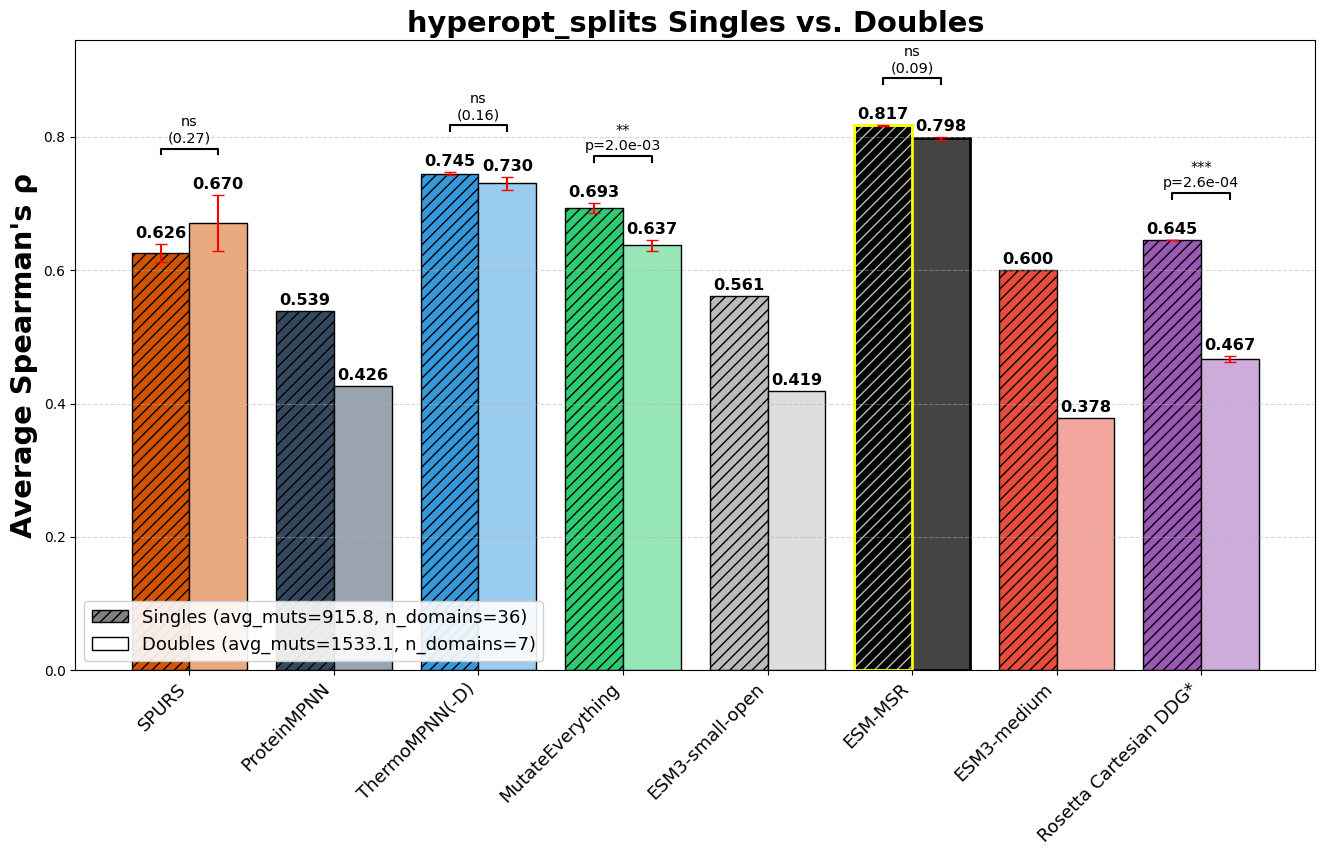

In [ ]:
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_singles.loc[('mega_splits-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], highlighted_model='ESM-MSR', title='mega_splits Singles vs. Doubles', y_label='Average Spearman\'s ρ',
                                             series2=df_scores_doubles.loc[('mega_splits-test', 'grouped')], series_names=('Singles', 'Doubles'), fontsize_multiplier=1.3, figsize=(16,10), legend_loc='lower left') #'ESM3-small', 'ESM3-large',

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'mega_splits Native vs. Destabilized'}, ylabel="Average Spearman's ρ">)

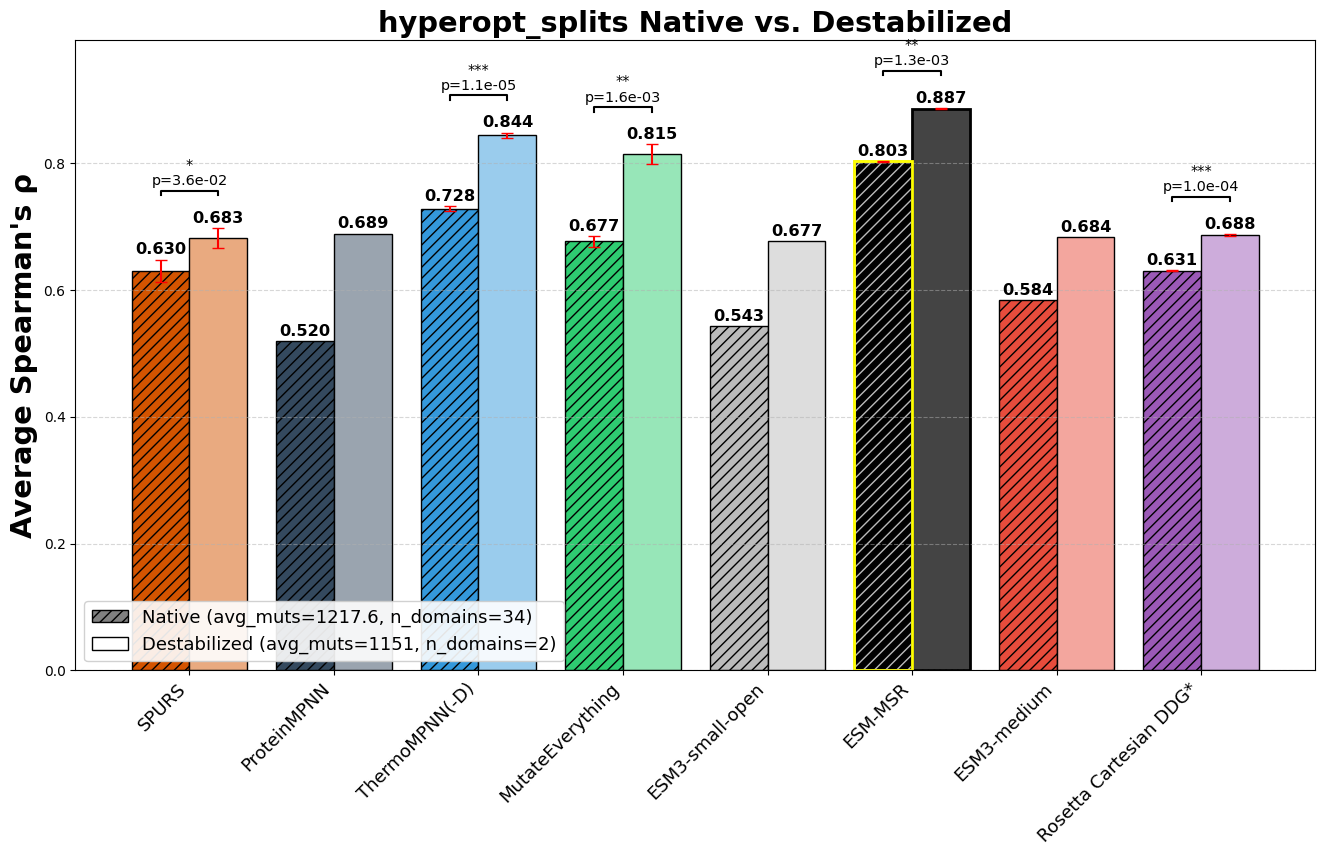

In [ ]:
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_no_destab.loc[('mega_splits-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], highlighted_model='ESM-MSR', title='mega_splits Native vs. Destabilized', y_label='Average Spearman\'s ρ',
                                             series2=df_scores_destab.loc[('mega_splits-test', 'grouped')], series_names=('Native', 'Destabilized'), fontsize_multiplier=1.3, figsize=(16,10), legend_loc='lower left')

(<Figure size 1600x1000 with 1 Axes>,
 <Axes: title={'center': 'mega_splits Natural vs. Synthetic'}, ylabel="Average Spearman's ρ">)

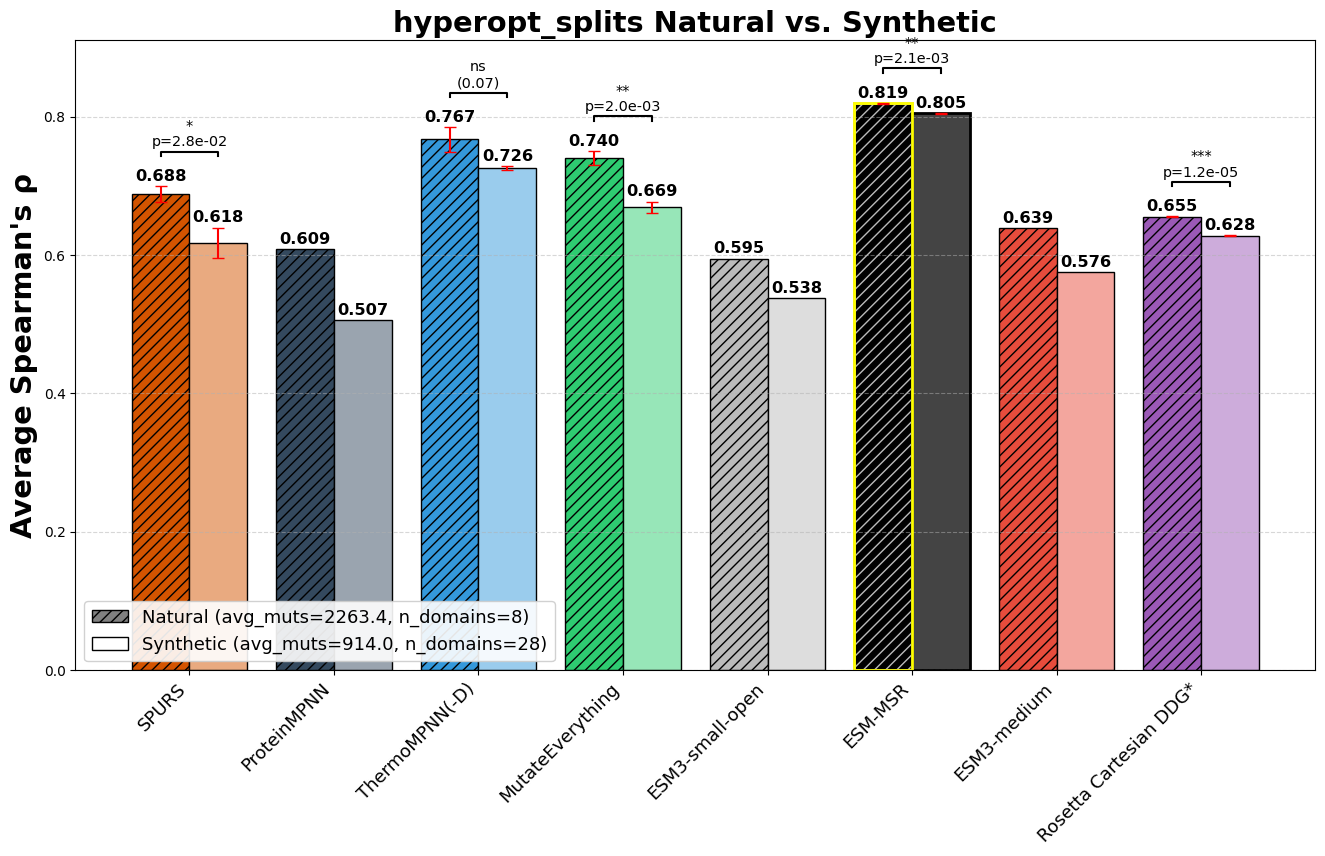

In [ ]:
analysis_utils_msr.create_metric_comparison_chart_epistatic(df_scores_natural.loc[('mega_splits-test', 'grouped')], ['SPURS', 'ProteinMPNN', 'ThermoMPNN(-D)', 'MutateEverything', 'ESM3-small-open', 'ESM-MSR', 'ESM3-medium', 'Rosetta Cartesian DDG'], highlighted_model='ESM-MSR', title='mega_splits Natural vs. Synthetic', y_label='Average Spearman\'s ρ',
                                             series2=df_scores_synthetic.loc[('mega_splits-test', 'grouped')], series_names=('Natural', 'Synthetic'), fontsize_multiplier=1.3, figsize=(16,10), legend_loc='lower left')